# Translon Consensus Talk Foundation

Clean, inspectable dataframes and simple talk-ready plots for the translon-consensus pilot. The notebook deliberately separates dataframe construction from plotting so each plot can be tweaked quickly tomorrow morning.

Main rules:
- query the translon DB once into named tables;
- calculate agreement in genomic space;
- add transcript/candidate context afterward;
- use P-site-registered bigWig scores before interpreting periodicity;
- keep plots simple and slide-readable.


## 1. Setup and safety checks

This cell prints the exact scorer module being used. If `Scorer supports P-site offsets` is false, sync the updated `transcode_bigwig_signal_scores.py` before trusting periodicity plots.


In [21]:
import inspect
import json
import os
import sqlite3
import sys
from pathlib import Path

import matplotlib
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is None:
        matplotlib.use('Agg')
    else:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SCRIPT_DIR = Path.cwd()
if (SCRIPT_DIR / 'transcode_bigwig_signal_scores.py').exists():
    sys.path.insert(0, str(SCRIPT_DIR))
else:
    sys.path.insert(0, str(Path('/Users/jackt/projects/all-RiboSeq/ensembl-genes-nf/pipelines/translon-consensus/scripts')))

import transcode_bigwig_signal_scores as signal_scores

ScoreConfig = signal_scores.ScoreConfig
score_database = signal_scores.score_database
expand_scores_by_tool = signal_scores.expand_scores_by_tool
discover_bigwigs = signal_scores.discover_bigwigs
HAS_PYBIGWIG = signal_scores.HAS_PYBIGWIG

if hasattr(signal_scores, 'load_psite_offsets'):
    load_psite_offsets = signal_scores.load_psite_offsets
else:
    def load_psite_offsets(path):
        path = Path(path)
        if not path.exists():
            print(f'P-site offsets file {path} is absent; using offset 0 for all samples')
            return {}
        raw = json.loads(path.read_text())
        offsets = {}
        for sample_id, value in raw.items():
            offset = value.get('offset') if isinstance(value, dict) else value
            offsets[str(sample_id)] = int(offset) % 3
        return offsets

try:
    from calibrate_psite_offsets import calibrate_sample, load_mane_cds
    HAS_CALIBRATION_HELPERS = True
except Exception as exc:
    print(f'Calibration helpers unavailable: {exc}')
    HAS_CALIBRATION_HELPERS = False

DB = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite')
GTF = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/gencode.v47.annotation.gtf')
GROUPED_BIGWIG_ROOT = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/gencode_pilot_pancreas/grouped_pilot_tracks/bigwigs')

OUT_DIR = Path('figures_talk_foundation')
TABLE_DIR = Path('tables_talk_foundation')
OUT_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

SIGNAL_MODE = 'unique_no_junction'
# Overnight-safe default: cap scoring unless SCORE_FEATURE_CAP=none is set.
_SCORE_CAP_RAW = os.environ.get('SCORE_FEATURE_CAP', '5000').strip().lower()
SCORE_FEATURE_CAP = None if _SCORE_CAP_RAW in {'none', 'full', 'all', ''} else int(_SCORE_CAP_RAW)
BIGWIG_ROOT = OUT_DIR / f'bigwig_links_{SIGNAL_MODE}'
BIGWIG_ROOT.mkdir(parents=True, exist_ok=True)
PSITE_OFFSETS = OUT_DIR / 'psite_offsets.json'
SCORES_PATH = OUT_DIR / 'translon_signal_scores.tsv.gz'
SUMMARY_PATH = OUT_DIR / 'signal_score_summary.json'

PANCREAS_SAMPLES = [
    'SRR11005875_to_79',
    'SRR11005880_to_84',
    'SRR11005885_to_89',
    'SRR11005890_to_94',
    'SRR11005895_to_99',
    'SRR11005900_to_04',
    'Ribo_Pancreas_pooled',
]
PRIMARY_SAMPLE = 'Ribo_Pancreas_pooled'
TOOL_ORDER = ['PRICE', 'RiboTIE', 'ORFQuant', 'iRibo', 'RibORF2']
AGREEMENT_ORDER = ['full_consensus', 'boundary_agreement', 'tool_specific']
CONTEXT_ORDER = ['annotated_CDS', 'ambiguous_mixed_class', 'non_CDS_AUG', 'non_CDS_near_cognate', 'non_CDS_other_start']
TOOL_COLORS = {
    'PRICE': '#4C72B0',
    'RiboTIE': '#DD8452',
    'ORFQuant': '#55A868',
    'iRibo': '#C44E52',
    'RibORF2': '#8172B2',
}
CONTEXT_COLORS = {
    'annotated_CDS': '#4C72B0',
    'ambiguous_mixed_class': '#8172B2',
    'non_CDS_AUG': '#55A868',
    'non_CDS_near_cognate': '#DD8452',
    'non_CDS_other_start': '#C44E52',
}
AGREEMENT_COLORS = {
    'full_consensus': '#4C72B0',
    'boundary_agreement': '#DD8452',
    'tool_specific': '#55A868',
}

SCORER_MODULE = Path(signal_scores.__file__).resolve()
SCORER_SUPPORTS_PSITE = (
    hasattr(signal_scores, 'load_psite_offsets')
    and 'psite_offsets' in inspect.signature(score_database).parameters
    and 'psite_offset' in getattr(ScoreConfig, '__dataclass_fields__', {})
)

print(f'DB: {DB} exists={DB.exists()}')
print(f'GTF: {GTF} exists={GTF.exists()}')
print(f'Grouped BigWig root: {GROUPED_BIGWIG_ROOT} exists={GROUPED_BIGWIG_ROOT.exists()}')
print(f'Output dir: {OUT_DIR.resolve()}')
print(f'Table dir: {TABLE_DIR.resolve()}')
print(f'Scorer module: {SCORER_MODULE}')
print(f'Scorer supports P-site offsets: {SCORER_SUPPORTS_PSITE}')
print(f'pyBigWig available: {HAS_PYBIGWIG}')
print(f'SCORE_FEATURE_CAP: {SCORE_FEATURE_CAP}')
if not SCORER_SUPPORTS_PSITE:
    print('WARNING: sync transcode_bigwig_signal_scores.py before recalculating registered periodicity.')


DB: /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite exists=True
GTF: /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/gencode.v47.annotation.gtf exists=True
Grouped BigWig root: /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/gencode_pilot_pancreas/grouped_pilot_tracks/bigwigs exists=True
Output dir: /hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation
Table dir: /hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/tables_talk_foundation
Scorer module: /hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/transcode_bigwig_signal_scores.py
Scorer supports P-site offsets: True
pyBigWig available: True


## 2. Small helpers

These helpers keep the later cells short. They do not hide analysis decisions: each dataframe is still created explicitly in its own section.


In [22]:
def show_df(name, df, n=5):
    print(f'{name}: shape={df.shape}')
    if len(df):
        display(df.head(n))
    else:
        print('(empty)')


def save_table(df, name):
    path = TABLE_DIR / f'{name}.tsv'
    df.to_csv(path, sep='\t', index=False)
    print(f'Saved {path}')
    return path


def finish_plot(fig, out_name):
    out = OUT_DIR / out_name
    fig.tight_layout()
    fig.savefig(out, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Saved {out}')
    return out


def genomic_start_stop(df):
    start = np.where(df['bed_strand'].eq('+'), df['bed_start'], df['bed_end'])
    stop = np.where(df['bed_strand'].eq('+'), df['bed_end'], df['bed_start'])
    return pd.Series(start, index=df.index).astype(int), pd.Series(stop, index=df.index).astype(int)


def add_genomic_keys(df):
    out = df.copy()
    out['genomic_start'], out['genomic_stop'] = genomic_start_stop(out)
    out['full_key'] = (
        out['bed_chrom'].astype(str) + ':' + out['bed_strand'].astype(str) + ':'
        + out['genomic_start'].astype(str) + ':' + out['genomic_stop'].astype(str) + ':'
        + out['block_sizes'].astype(str) + ':' + out['block_starts'].astype(str)
    )
    out['start_key'] = out['bed_chrom'].astype(str) + ':' + out['bed_strand'].astype(str) + ':' + out['genomic_start'].astype(str)
    out['stop_key'] = out['bed_chrom'].astype(str) + ':' + out['bed_strand'].astype(str) + ':' + out['genomic_stop'].astype(str)
    return out


def compact_support_tier(n):
    n = int(n)
    if n >= 4:
        return '4+ tools'
    return f'{n} tool' if n == 1 else f'{n} tools'


def ordered_present(values, order):
    present = set(values)
    return [x for x in order if x in present] + sorted(present - set(order))


def summary_has_matching_offsets(summary, offsets):
    samples = summary.get('samples', []) if isinstance(summary, dict) else []
    if not offsets or not samples:
        return False
    for sample in samples:
        sid = str(sample.get('sample_id'))
        if 'psite_offset' not in sample:
            return False
        if int(sample['psite_offset']) != int(offsets.get(sid, 0)):
            return False
    return True


## 3. Query the DB into `calls_raw`

`calls_raw` is the base table: one QC-pass DB row per candidate occurrence. The rest of the notebook derives smaller tables from this.


In [ ]:
BASE_FILTER = """
    qc_status = 'pass'
    AND sample_id NOT GLOB '*_fastq'
    AND source_feature_class IN ('cds', 'non_cds')
"""

if not DB.exists():
    print(f'DB is unavailable: {DB}')
    calls_raw = pd.DataFrame(columns=[
        'source_tool', 'sample_id', 'cls', 'feature_key', 'bed_chrom', 'bed_start', 'bed_end',
        'bed_strand', 'block_sizes', 'block_starts', 'spliced_length_nt', 'start_codon_class',
        'terminal_codon_class'
    ])
else:
    with sqlite3.connect(DB) as con:
        calls_raw = pd.read_sql_query(f"""
            SELECT source_tool,
                   sample_id,
                   source_feature_class AS cls,
                   feature_key,
                   bed_chrom,
                   bed_start,
                   bed_end,
                   bed_strand,
                   block_sizes,
                   block_starts,
                   spliced_length_nt,
                   start_codon_class,
                   terminal_codon_class
            FROM translons
            WHERE {BASE_FILTER}
        """, con)

calls_raw['source_tool'] = calls_raw['source_tool'].astype(str).str.strip() if len(calls_raw) else calls_raw.get('source_tool', pd.Series(dtype=str))
show_df('calls_raw', calls_raw)
if len(calls_raw):
    display(calls_raw.groupby(['sample_id', 'source_tool', 'cls'])['feature_key'].nunique().reset_index(name='unique_features'))


## 4. Pooled calls, candidates, agreement, and context

Agreement is calculated in genomic space. Candidate context is layered on afterward.


In [24]:
calls_pooled = calls_raw[calls_raw['sample_id'].eq(PRIMARY_SAMPLE)].copy()
if calls_pooled.empty and len(calls_raw):
    print(f'Primary sample {PRIMARY_SAMPLE!r} not found. Falling back to all rows for agreement summaries.')
    calls_pooled = calls_raw.copy()

calls_pooled = (
    calls_pooled
    .sort_values(['source_tool', 'feature_key'])
    .drop_duplicates(['source_tool', 'feature_key'])
    .reset_index(drop=True)
)
calls_pooled = add_genomic_keys(calls_pooled) if len(calls_pooled) else calls_pooled
save_table(calls_pooled, 'calls_pooled')
show_df('calls_pooled', calls_pooled)


Saved tables_talk_foundation/calls_pooled.tsv
calls_pooled: shape=(364737, 18)


,source_tool,sample_id,cls,feature_key,bed_chrom,bed_start,bed_end,bed_strand,block_sizes,block_starts,spliced_length_nt,start_codon_class,terminal_codon_class,genomic_start,genomic_stop,full_key,start_key,stop_key
0,ORFQuant,Ribo_Pancreas_pooled,cds,"chr10:100042426-100081625:-:147,119,100,140,11...",chr10,100042426,100081625,-,"147,119,100,140,112,183,156,197,223","0,6331,11920,14586,21187,22761,27287,33484,38976",1377,ATG,stop,100081625,100042426,"chr10:-:100081625:100042426:147,119,100,140,11...",chr10:-:100081625,chr10:-:100042426
1,ORFQuant,Ribo_Pancreas_pooled,cds,chr10:100081788-100081815:-:27:0,chr10,100081788,100081815,-,27,0,27,ATG,stop,100081815,100081788,chr10:-:100081815:100081788:27:0,chr10:-:100081815,chr10:-:100081788
2,ORFQuant,Ribo_Pancreas_pooled,cds,"chr10:100152130-100185626:-:222,80,90,92,59,74...",chr10,100152130,100185626,-,"222,80,90,92,59,74,126,62,47,82,113","0,2729,4014,11873,15217,22077,23814,26002,2707...",1047,ATG,stop,100185626,100152130,"chr10:-:100185626:100152130:222,80,90,92,59,74...",chr10:-:100185626,chr10:-:100152130
3,ORFQuant,Ribo_Pancreas_pooled,cds,"chr10:100189597-100229532:-:30,100,134,148,97,...",chr10,100189597,100229532,-,"30,100,134,148,97,50,110,62,152,124,103,195,13...","0,1271,3700,4386,4827,10373,11073,12490,14908,...",2238,ATG,stop,100229532,100189597,"chr10:-:100229532:100189597:30,100,134,148,97,...",chr10:-:100229532,chr10:-:100189597
4,ORFQuant,Ribo_Pancreas_pooled,cds,"chr10:100233226-100267593:-:145,98,120,210,80,...",chr10,100233226,100267593,-,"145,98,120,210,80,115,141,85,119,215,102,79,85,23","0,2440,3623,4795,10471,12572,13568,17021,20194...",1617,ATG,stop,100267593,100233226,"chr10:-:100267593:100233226:145,98,120,210,80,...",chr10:-:100267593,chr10:-:100233226


In [25]:
if calls_pooled.empty:
    candidate_df = pd.DataFrame()
else:
    candidate_df = (
        calls_pooled
        .groupby('feature_key', sort=False)
        .agg(
            bed_chrom=('bed_chrom', 'first'),
            bed_start=('bed_start', 'first'),
            bed_end=('bed_end', 'first'),
            bed_strand=('bed_strand', 'first'),
            block_sizes=('block_sizes', 'first'),
            block_starts=('block_starts', 'first'),
            spliced_length_nt=('spliced_length_nt', 'first'),
            genomic_start=('genomic_start', 'first'),
            genomic_stop=('genomic_stop', 'first'),
            full_key=('full_key', 'first'),
            start_key=('start_key', 'first'),
            stop_key=('stop_key', 'first'),
            source_tools=('source_tool', lambda s: '|'.join(ordered_present(s.astype(str), TOOL_ORDER))),
            n_tools_full=('source_tool', 'nunique'),
        )
        .reset_index()
    )

save_table(candidate_df, 'candidate_df')
show_df('candidate_df', candidate_df)


Saved tables_talk_foundation/candidate_df.tsv
candidate_df: shape=(237973, 15)


,feature_key,bed_chrom,bed_start,bed_end,bed_strand,block_sizes,block_starts,spliced_length_nt,genomic_start,genomic_stop,full_key,start_key,stop_key,source_tools,n_tools_full
0,"chr10:100042426-100081625:-:147,119,100,140,11...",chr10,100042426,100081625,-,"147,119,100,140,112,183,156,197,223","0,6331,11920,14586,21187,22761,27287,33484,38976",1377,100081625,100042426,"chr10:-:100081625:100042426:147,119,100,140,11...",chr10:-:100081625,chr10:-:100042426,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5
1,chr10:100081788-100081815:-:27:0,chr10,100081788,100081815,-,27,0,27,100081815,100081788,chr10:-:100081815:100081788:27:0,chr10:-:100081815,chr10:-:100081788,PRICE|ORFQuant|iRibo|RibORF2,4
2,"chr10:100152130-100185626:-:222,80,90,92,59,74...",chr10,100152130,100185626,-,"222,80,90,92,59,74,126,62,47,82,113","0,2729,4014,11873,15217,22077,23814,26002,2707...",1047,100185626,100152130,"chr10:-:100185626:100152130:222,80,90,92,59,74...",chr10:-:100185626,chr10:-:100152130,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5
3,"chr10:100189597-100229532:-:30,100,134,148,97,...",chr10,100189597,100229532,-,"30,100,134,148,97,50,110,62,152,124,103,195,13...","0,1271,3700,4386,4827,10373,11073,12490,14908,...",2238,100229532,100189597,"chr10:-:100229532:100189597:30,100,134,148,97,...",chr10:-:100229532,chr10:-:100189597,RiboTIE|ORFQuant|iRibo|RibORF2,4
4,"chr10:100233226-100267593:-:145,98,120,210,80,...",chr10,100233226,100267593,-,"145,98,120,210,80,115,141,85,119,215,102,79,85,23","0,2440,3623,4795,10471,12572,13568,17021,20194...",1617,100267593,100233226,"chr10:-:100267593:100233226:145,98,120,210,80,...",chr10:-:100267593,chr10:-:100233226,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5


In [26]:
if calls_pooled.empty:
    agreement_df = pd.DataFrame()
else:
    start_counts = calls_pooled.groupby('start_key')['source_tool'].nunique().rename('n_tools_start')
    stop_counts = calls_pooled.groupby('stop_key')['source_tool'].nunique().rename('n_tools_stop')
    agreement_df = candidate_df.merge(start_counts, on='start_key', how='left').merge(stop_counts, on='stop_key', how='left')
    agreement_df[['n_tools_start', 'n_tools_stop']] = agreement_df[['n_tools_start', 'n_tools_stop']].fillna(0).astype(int)
    agreement_df['agreement_class'] = np.select(
        [
            agreement_df['n_tools_full'].ge(2),
            agreement_df['n_tools_full'].eq(1) & (agreement_df['n_tools_start'].ge(2) | agreement_df['n_tools_stop'].ge(2)),
        ],
        ['full_consensus', 'boundary_agreement'],
        default='tool_specific',
    )

save_table(agreement_df, 'agreement_df')
show_df('agreement_df', agreement_df)
if len(agreement_df):
    display(agreement_df['agreement_class'].value_counts().rename_axis('agreement_class').reset_index(name='candidates'))


Saved tables_talk_foundation/agreement_df.tsv
agreement_df: shape=(237973, 18)


,feature_key,bed_chrom,bed_start,bed_end,bed_strand,block_sizes,block_starts,spliced_length_nt,genomic_start,genomic_stop,full_key,start_key,stop_key,source_tools,n_tools_full,n_tools_start,n_tools_stop,agreement_class
0,"chr10:100042426-100081625:-:147,119,100,140,11...",chr10,100042426,100081625,-,"147,119,100,140,112,183,156,197,223","0,6331,11920,14586,21187,22761,27287,33484,38976",1377,100081625,100042426,"chr10:-:100081625:100042426:147,119,100,140,11...",chr10:-:100081625,chr10:-:100042426,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus
1,chr10:100081788-100081815:-:27:0,chr10,100081788,100081815,-,27,0,27,100081815,100081788,chr10:-:100081815:100081788:27:0,chr10:-:100081815,chr10:-:100081788,PRICE|ORFQuant|iRibo|RibORF2,4,4,4,full_consensus
2,"chr10:100152130-100185626:-:222,80,90,92,59,74...",chr10,100152130,100185626,-,"222,80,90,92,59,74,126,62,47,82,113","0,2729,4014,11873,15217,22077,23814,26002,2707...",1047,100185626,100152130,"chr10:-:100185626:100152130:222,80,90,92,59,74...",chr10:-:100185626,chr10:-:100152130,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus
3,"chr10:100189597-100229532:-:30,100,134,148,97,...",chr10,100189597,100229532,-,"30,100,134,148,97,50,110,62,152,124,103,195,13...","0,1271,3700,4386,4827,10373,11073,12490,14908,...",2238,100229532,100189597,"chr10:-:100229532:100189597:30,100,134,148,97,...",chr10:-:100229532,chr10:-:100189597,RiboTIE|ORFQuant|iRibo|RibORF2,4,4,5,full_consensus
4,"chr10:100233226-100267593:-:145,98,120,210,80,...",chr10,100233226,100267593,-,"145,98,120,210,80,115,141,85,119,215,102,79,85,23","0,2440,3623,4795,10471,12572,13568,17021,20194...",1617,100267593,100233226,"chr10:-:100267593:100233226:145,98,120,210,80,...",chr10:-:100267593,chr10:-:100233226,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus


,agreement_class,candidates
0,boundary_agreement,104858
1,full_consensus,73862
2,tool_specific,59253


In [27]:
def classify_context(group):
    classes = set(group['cls'].dropna().astype(str))
    starts = set(group['start_codon_class'].dropna().astype(str))
    if {'cds', 'non_cds'}.issubset(classes):
        return 'ambiguous_mixed_class'
    if 'cds' in classes:
        return 'annotated_CDS'
    if 'ATG' in starts:
        return 'non_CDS_AUG'
    if 'near_cognate' in starts:
        return 'non_CDS_near_cognate'
    return 'non_CDS_other_start'

if calls_pooled.empty:
    context_df = pd.DataFrame()
else:
    context_df = (
        calls_pooled
        .groupby('feature_key', sort=False)
        .apply(lambda g: pd.Series({
            'context_class': classify_context(g),
            'classes': '|'.join(sorted(set(g['cls'].dropna().astype(str)))),
            'start_codon_classes': '|'.join(sorted(set(g['start_codon_class'].dropna().astype(str)))),
            'terminal_codon_classes': '|'.join(sorted(set(g['terminal_codon_class'].dropna().astype(str)))),
            'spliced_length_nt': g['spliced_length_nt'].min(),
        }))
        .reset_index()
    )

save_table(context_df, 'context_df')
show_df('context_df', context_df)
if len(context_df):
    display(context_df['context_class'].value_counts().rename_axis('context_class').reset_index(name='candidates'))


Saved tables_talk_foundation/context_df.tsv
context_df: shape=(237973, 6)


,feature_key,context_class,classes,start_codon_classes,terminal_codon_classes,spliced_length_nt
0,"chr10:100042426-100081625:-:147,119,100,140,11...",annotated_CDS,cds,ATG,stop,1377
1,chr10:100081788-100081815:-:27:0,ambiguous_mixed_class,cds|non_cds,ATG,stop,27
2,"chr10:100152130-100185626:-:222,80,90,92,59,74...",annotated_CDS,cds,ATG,stop,1047
3,"chr10:100189597-100229532:-:30,100,134,148,97,...",annotated_CDS,cds,ATG,stop,2238
4,"chr10:100233226-100267593:-:145,98,120,210,80,...",annotated_CDS,cds,ATG,stop,1617


,context_class,candidates
0,annotated_CDS,131217
1,non_CDS_AUG,73251
2,non_CDS_near_cognate,25004
3,ambiguous_mixed_class,8501


In [57]:
# Investigate candidates labelled ambiguous_mixed_class
mixed_feature_keys = context_df.loc[
    context_df["context_class"].eq("ambiguous_mixed_class"),
    "feature_key"
]

mixed_rows = (
    calls_pooled[calls_pooled["feature_key"].isin(mixed_feature_keys)]
    .sort_values(["feature_key", "source_tool", "cls"])
    .copy()
)

print(f"Mixed-label candidates: {mixed_feature_keys.nunique():,}")
print(f"Underlying rows: {len(mixed_rows):,}")

mixed_summary = (
    mixed_rows
    .groupby("feature_key")
    .agg(
        tools=("source_tool", lambda s: "|".join(sorted(set(map(str, s))))),
        classes=("cls", lambda s: "|".join(sorted(set(map(str, s))))),
        start_codon_classes=("start_codon_class", lambda s: "|".join(sorted(set(map(str, s))))),
        terminal_codon_classes=("terminal_codon_class", lambda s: "|".join(sorted(set(map(str, s))))),
        n_tools=("source_tool", "nunique"),
        n_rows=("source_tool", "size"),
        chrom=("bed_chrom", "first"),
        start=("bed_start", "first"),
        end=("bed_end", "first"),
        strand=("bed_strand", "first"),
        length_nt=("spliced_length_nt", "first"),
    )
    .reset_index()
    .sort_values(["n_tools", "n_rows", "feature_key"], ascending=[False, False, True])
)

display(mixed_summary.head(30))

# Tool x class breakdown: shows which tools are assigning CDS vs non-CDS labels
mixed_tool_class = (
    mixed_rows
    .groupby(["source_tool", "cls"])
    ["feature_key"]
    .nunique()
    .reset_index(name="n_mixed_candidates")
    .pivot_table(
        index="source_tool",
        columns="cls",
        values="n_mixed_candidates",
        fill_value=0,
    )
    .reindex(TOOL_ORDER)
)

display(mixed_tool_class)

# Pick one candidate and show all raw rows contributing to its mixed label
if not mixed_summary.empty:
    example_fk = mixed_summary.iloc[0]["feature_key"]
    print(f"Example mixed feature_key: {example_fk}")
    display(
        mixed_rows.loc[mixed_rows["feature_key"].eq(example_fk)]
        [[
            "source_tool", "sample_id", "cls", "feature_key",
            "bed_chrom", "bed_start", "bed_end", "bed_strand",
            "block_sizes", "block_starts",
            "start_codon_class", "terminal_codon_class",
            "spliced_length_nt",
        ]]
    )

Mixed-label candidates: 8,501
Underlying rows: 23,524


,feature_key,tools,classes,start_codon_classes,terminal_codon_classes,n_tools,n_rows,chrom,start,end,strand,length_nt
11,chr10:100988024-100988135:+:111:0,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,100988024,100988135,+,111
46,chr10:103917908-103918004:-:96:0,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,103917908,103918004,-,96
55,"chr10:1049543-1072131:+:98,16:0,22572",ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,1049543,1072131,+,114
136,chr10:24466530-24466737:+:207:0,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,24466530,24466737,+,207
156,"chr10:30047824-30059497:-:47,16:0,11657",ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,30047824,30059497,-,63
174,chr10:37857194-37857257:-:63:0,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,37857194,37857257,-,63
186,"chr10:44959831-44970171:+:35,7:0,10333",ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,44959831,44970171,+,42
214,chr10:5446638-5446719:+:81:0,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,5446638,5446719,+,81
231,"chr10:68073116-68073664:-:70,8:0,540",ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,68073116,68073664,-,78
253,chr10:72626041-72626068:-:27:0,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,ATG,stop,5,5,chr10,72626041,72626068,-,27


cls,cds,non_cds
source_tool,,
PRICE,3836.0,620.0
RiboTIE,709.0,115.0
ORFQuant,2384.0,140.0
iRibo,0.0,7867.0
RibORF2,7414.0,439.0


Example mixed feature_key: chr10:100988024-100988135:+:111:0


,source_tool,sample_id,cls,feature_key,bed_chrom,bed_start,bed_end,bed_strand,block_sizes,block_starts,start_codon_class,terminal_codon_class,spliced_length_nt
43,ORFQuant,Ribo_Pancreas_pooled,cds,chr10:100988024-100988135:+:111:0,chr10,100988024,100988135,+,111,0,ATG,stop,111
45660,PRICE,Ribo_Pancreas_pooled,cds,chr10:100988024-100988135:+:111:0,chr10,100988024,100988135,+,111,0,ATG,stop,111
98392,RibORF2,Ribo_Pancreas_pooled,cds,chr10:100988024-100988135:+:111:0,chr10,100988024,100988135,+,111,0,ATG,stop,111
272373,RiboTIE,Ribo_Pancreas_pooled,cds,chr10:100988024-100988135:+:111:0,chr10,100988024,100988135,+,111,0,ATG,stop,111
316483,iRibo,Ribo_Pancreas_pooled,non_cds,chr10:100988024-100988135:+:111:0,chr10,100988024,100988135,+,111,0,ATG,stop,111


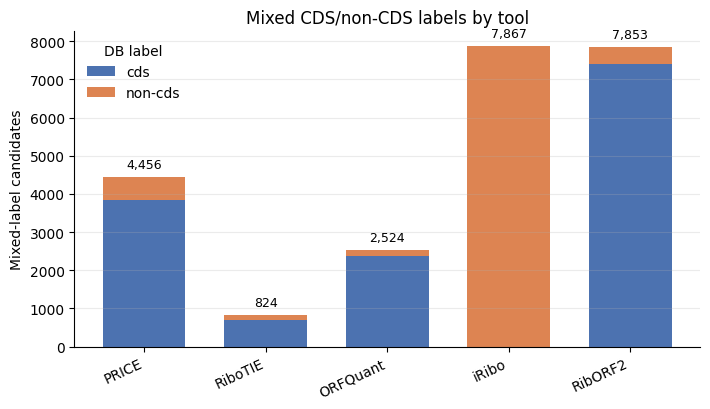

Saved figures_talk_foundation/mixed_cds_noncds_labels_by_tool.png


In [62]:
# Plot mixed CDS/non-CDS labels by tool
plot_mixed_tool_class = mixed_tool_class.copy()

# Drop tools with no mixed-label candidates, if any
plot_mixed_tool_class = plot_mixed_tool_class.loc[
    plot_mixed_tool_class.sum(axis=1).gt(0)
]

fig, ax = plt.subplots(figsize=(7.2, 4.2))

bottom = np.zeros(len(plot_mixed_tool_class))
x = np.arange(len(plot_mixed_tool_class))

class_colors = {
    "cds": "#4C72B0",
    "non_cds": "#DD8452",
}

for cls in [c for c in ["cds", "non_cds"] if c in plot_mixed_tool_class.columns]:
    vals = plot_mixed_tool_class[cls].to_numpy()
    ax.bar(
        x,
        vals,
        bottom=bottom,
        label=cls.replace("_", "-"),
        color=class_colors.get(cls, "0.5"),
        width=0.68,
    )
    bottom += vals

for xi, total in zip(x, bottom):
    ax.text(
        xi,
        total + max(bottom) * 0.02,
        f"{int(total):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_mixed_tool_class.index, rotation=25, ha="right")
ax.set_ylabel("Mixed-label candidates")
ax.set_title("Mixed CDS/non-CDS labels by tool")
ax.legend(frameon=False, title="DB label")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
out = OUT_DIR / "mixed_cds_noncds_labels_by_tool.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved {out}")


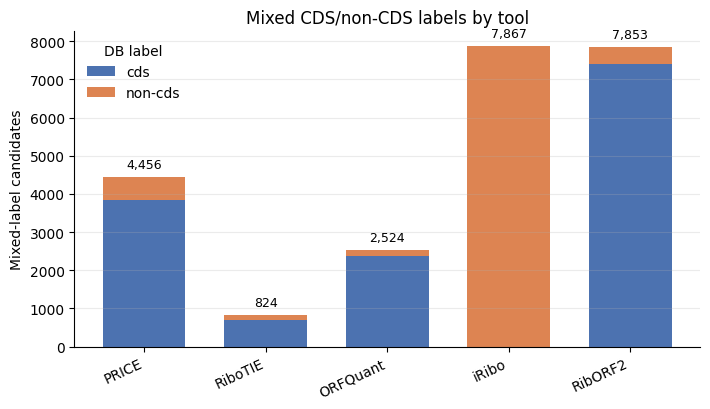

Saved figures_talk_foundation/mixed_cds_noncds_labels_by_tool.png


In [59]:
# Plot mixed CDS/non-CDS labels by tool
plot_mixed_tool_class = mixed_tool_class.copy()

# Drop tools with no mixed-label candidates, if any
plot_mixed_tool_class = plot_mixed_tool_class.loc[
    plot_mixed_tool_class.sum(axis=1).gt(0)
]

fig, ax = plt.subplots(figsize=(7.2, 4.2))

bottom = np.zeros(len(plot_mixed_tool_class))
x = np.arange(len(plot_mixed_tool_class))

class_colors = {
    "cds": "#4C72B0",
    "non_cds": "#DD8452",
}

for cls in [c for c in ["cds", "non_cds"] if c in plot_mixed_tool_class.columns]:
    vals = plot_mixed_tool_class[cls].to_numpy()
    ax.bar(
        x,
        vals,
        bottom=bottom,
        label=cls.replace("_", "-"),
        color=class_colors.get(cls, "0.5"),
        width=0.68,
    )
    bottom += vals

for xi, total in zip(x, bottom):
    ax.text(
        xi,
        total + max(bottom) * 0.02,
        f"{int(total):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_mixed_tool_class.index, rotation=25, ha="right")
ax.set_ylabel("Mixed-label candidates")
ax.set_title("Mixed CDS/non-CDS labels by tool")
ax.legend(frameon=False, title="DB label")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
out = OUT_DIR / "mixed_cds_noncds_labels_by_tool.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved {out}")


## 5. BigWig links, P-site offsets, and registered scores

The periodicity evidence plots must be skipped unless the score summary records the matching per-sample P-site offsets.


In [28]:
# Create scorer-compatible symlinks: {sample}.forward.bw / {sample}.reverse.bw
link_rows = []
for sample in PANCREAS_SAMPLES:
    for strand in ('forward', 'reverse'):
        src = GROUPED_BIGWIG_ROOT / f'{sample}.{SIGNAL_MODE}.{strand}.bw'
        dst = BIGWIG_ROOT / f'{sample}.{strand}.bw'
        if dst.exists() or dst.is_symlink():
            dst.unlink()
        if src.exists():
            dst.symlink_to(src)
        link_rows.append({'sample_id': sample, 'strand': strand, 'source_path': src, 'link_path': dst, 'source_exists': src.exists()})

bigwig_links_df = pd.DataFrame(link_rows)
save_table(bigwig_links_df, 'bigwig_links')
show_df('bigwig_links_df', bigwig_links_df, 14)

bw_manifest = discover_bigwigs(BIGWIG_ROOT)
show_df('bw_manifest', bw_manifest)


Saved tables_talk_foundation/bigwig_links.tsv
bigwig_links_df: shape=(14, 5)


,sample_id,strand,source_path,link_path,source_exists
0,SRR11005875_to_79,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
1,SRR11005875_to_79,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
2,SRR11005880_to_84,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
3,SRR11005880_to_84,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
4,SRR11005885_to_89,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
5,SRR11005885_to_89,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
6,SRR11005890_to_94,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
7,SRR11005890_to_94,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
8,SRR11005895_to_99,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True
9,SRR11005895_to_99,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,figures_talk_foundation/bigwig_links_unique_no...,True


bw_manifest: shape=(7, 4)


,sample_id,fwd_path,rev_path,has_pair
0,Ribo_Pancreas_pooled,figures_talk_foundation/bigwig_links_unique_no...,figures_talk_foundation/bigwig_links_unique_no...,True
1,SRR11005875_to_79,figures_talk_foundation/bigwig_links_unique_no...,figures_talk_foundation/bigwig_links_unique_no...,True
2,SRR11005880_to_84,figures_talk_foundation/bigwig_links_unique_no...,figures_talk_foundation/bigwig_links_unique_no...,True
3,SRR11005885_to_89,figures_talk_foundation/bigwig_links_unique_no...,figures_talk_foundation/bigwig_links_unique_no...,True
4,SRR11005890_to_94,figures_talk_foundation/bigwig_links_unique_no...,figures_talk_foundation/bigwig_links_unique_no...,True


In [29]:
# Calibrate offsets if needed; otherwise load the existing frozen file.
if PSITE_OFFSETS.exists():
    offsets_json = json.loads(PSITE_OFFSETS.read_text())
    print(f'Loaded existing offsets: {PSITE_OFFSETS}')
elif not (HAS_PYBIGWIG and HAS_CALIBRATION_HELPERS and GTF.exists() and not bw_manifest.empty):
    offsets_json = {}
    print('Skipping calibration: pyBigWig, calibration helpers, GTF, or BigWigs are unavailable.')
else:
    transcripts = load_mane_cds(GTF)
    print(f'{len(transcripts):,} MANE_Select transcripts with CDS + start codon')
    offsets_json = {}
    for row in bw_manifest[bw_manifest['has_pair']].sort_values('sample_id').itertuples(index=False):
        if str(row.sample_id) not in PANCREAS_SAMPLES:
            continue
        offsets_json[str(row.sample_id)] = calibrate_sample(str(row.sample_id), str(row.fwd_path), str(row.rev_path), transcripts)
    PSITE_OFFSETS.write_text(json.dumps(offsets_json, indent=2) + '\n')
    print(f'Wrote {PSITE_OFFSETS}')

plot_psite_offsets_df = pd.DataFrame([{'sample_id': sid, **vals} for sid, vals in offsets_json.items()])
if not plot_psite_offsets_df.empty:
    plot_psite_offsets_df['offset_ok'] = plot_psite_offsets_df['offset'].eq(1)
    plot_psite_offsets_df['frame_ok'] = plot_psite_offsets_df['dom_frame_plus'].eq(2) & plot_psite_offsets_df['dom_frame_minus'].eq(2)
    plot_psite_offsets_df['strength_ok'] = plot_psite_offsets_df['dom_frac'].gt(0.8)

save_table(plot_psite_offsets_df, '05_psite_offsets')
show_df('plot_psite_offsets_df', plot_psite_offsets_df, 10)


Loaded existing offsets: figures_talk_foundation/psite_offsets.json
Saved tables_talk_foundation/05_psite_offsets.tsv
plot_psite_offsets_df: shape=(7, 11)


,sample_id,offset,dom_frac,dom_frac_plus,dom_frac_minus,dom_frame_plus,dom_frame_minus,n_tx,offset_ok,frame_ok,strength_ok
0,Ribo_Pancreas_pooled,1,0.832055,0.832190,0.831919,2,2,16526,True,True,True
1,SRR11005875_to_79,1,0.849230,0.849591,0.848861,2,2,14951,True,True,True
2,SRR11005880_to_84,1,0.832218,0.832518,0.831915,2,2,15432,True,True,True
3,SRR11005885_to_89,1,0.838834,0.839085,0.838582,2,2,15410,True,True,True
4,SRR11005890_to_94,1,0.832871,0.832546,0.833196,2,2,15310,True,True,True
5,SRR11005895_to_99,1,0.813919,0.814297,0.813536,2,2,15397,True,True,True
6,SRR11005900_to_04,1,0.829476,0.829255,0.829700,2,2,15416,True,True,True


In [30]:
# Run registered scoring if possible; otherwise load any existing score table but mark it unregistered unless the summary proves otherwise.
psite_offsets = load_psite_offsets(PSITE_OFFSETS) if PSITE_OFFSETS.exists() else {}
cfg = ScoreConfig(
    flank_nt=30,
    body_edge_nt=15,
    min_body_nt=30,
    min_total_signal=10.0,
    max_features_per_sample=SCORE_FEATURE_CAP,
    max_total_features=None,
    overwrite=True,
)

if HAS_PYBIGWIG and SCORER_SUPPORTS_PSITE and DB.exists() and BIGWIG_ROOT.exists() and psite_offsets:
    scores_unique, score_summary = score_database(DB, BIGWIG_ROOT, OUT_DIR, cfg, psite_offsets=psite_offsets)
else:
    if SCORES_PATH.exists():
        print(f'Loading existing scores: {SCORES_PATH}')
        scores_unique = pd.read_csv(SCORES_PATH, sep='\t')
    else:
        print('No scores available yet.')
        scores_unique = pd.DataFrame()
    score_summary = json.loads(SUMMARY_PATH.read_text()) if SUMMARY_PATH.exists() else {'samples': []}

SCORES_ARE_REGISTERED = summary_has_matching_offsets(score_summary, psite_offsets)
print(f'SCORES_ARE_REGISTERED = {SCORES_ARE_REGISTERED}')

if not scores_unique.empty and 'coverage_pass' in scores_unique and 'classes' in scores_unique:
    cds_mask = (
        scores_unique['sample_id'].eq(PRIMARY_SAMPLE)
        & scores_unique['coverage_pass'].astype(bool)
        & scores_unique['classes'].fillna('').astype(str).str.contains('cds')
    )
    cds_periodicity_median = scores_unique.loc[cds_mask, 'periodicity'].median()
    print(f'{PRIMARY_SAMPLE} coverage-pass CDS median periodicity: {cds_periodicity_median:.3f}')
    if not (SCORES_ARE_REGISTERED and cds_periodicity_median > 0.5):
        print('WARNING: registered periodicity check failed; periodicity evidence plots will be skipped.')
        SCORES_ARE_REGISTERED = False

save_table(scores_unique.head(5000) if not scores_unique.empty else scores_unique, 'scores_unique_preview')
show_df('scores_unique', scores_unique)


SCORES_ARE_REGISTERED = True
Ribo_Pancreas_pooled coverage-pass CDS median periodicity: 0.804
Saved tables_talk_foundation/scores_unique.tsv
scores_unique: shape=(1322242, 36)


,feature_key,sample_id,bed_chrom,bed_start,bed_end,bed_strand,spliced_length_nt,extract_status,orf_signal_nt,mean_cov,...,start_window_total_signal,start_upstream_total_signal,stop_pre_total_signal,stop_post_total_signal,upstream_flank_nt,downstream_flank_nt,flank_note,source_tools,classes,tool_rows
0,"chr10:100042426-100081625:-:147,119,100,140,11...",Ribo_Pancreas_pooled,chr10,100042426,100081625,-,1377,ok,1377,2.637618,...,29.0,36.0,33.0,0.0,30,30,genomic_flanks_not_splice_aware,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds,5
1,chr10:100081539-100081737:-:198:0,Ribo_Pancreas_pooled,chr10,100081539,100081737,-,198,ok,198,1.045455,...,5.0,6.0,42.0,259.0,30,30,genomic_flanks_not_splice_aware,PRICE,cds,1
2,chr10:100081788-100081815:-:27:0,Ribo_Pancreas_pooled,chr10,100081788,100081815,-,27,ok,27,5.592593,...,151.0,31.0,151.0,8.0,30,30,genomic_flanks_not_splice_aware,ORFQuant|PRICE|RibORF2|iRibo,cds|non_cds,4
3,"chr10:100152130-100185626:-:222,80,90,92,59,74...",Ribo_Pancreas_pooled,chr10,100152130,100185626,-,1047,ok,1047,11.542502,...,338.0,38.0,404.0,5.0,30,30,genomic_flanks_not_splice_aware,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds,5
4,chr10:100185660-100185771:-:111:0,Ribo_Pancreas_pooled,chr10,100185660,100185771,-,111,ok,111,1.981982,...,24.0,9.0,64.0,0.0,30,30,genomic_flanks_not_splice_aware,PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,4


## 6. Merge evidence table

`evidence_df` is the main table for score/evidence plots and example-locus ranking.


In [31]:
if scores_unique.empty or agreement_df.empty:
    evidence_df = pd.DataFrame()
else:
    pooled_scores = scores_unique[scores_unique['sample_id'].eq(PRIMARY_SAMPLE)].copy()
    evidence_df = (
        pooled_scores
        .merge(agreement_df, on='feature_key', how='left', suffixes=('', '_agreement'))
        .merge(context_df, on='feature_key', how='left', suffixes=('', '_context'))
    )
    if 'classes' not in evidence_df and 'classes_context' in evidence_df:
        evidence_df['classes'] = evidence_df['classes_context']

save_table(evidence_df, 'evidence_df')
show_df('evidence_df', evidence_df)


Saved tables_talk_foundation/evidence_df.tsv
evidence_df: shape=(237973, 58)


,feature_key,sample_id,bed_chrom,bed_start,bed_end,bed_strand,spliced_length_nt,extract_status,orf_signal_nt,mean_cov,...,source_tools_agreement,n_tools_full,n_tools_start,n_tools_stop,agreement_class,context_class,classes_context,start_codon_classes,terminal_codon_classes,spliced_length_nt_context
0,"chr10:100042426-100081625:-:147,119,100,140,11...",Ribo_Pancreas_pooled,chr10,100042426,100081625,-,1377,ok,1377,2.637618,...,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus,annotated_CDS,cds,ATG,stop,1377
1,chr10:100081539-100081737:-:198:0,Ribo_Pancreas_pooled,chr10,100081539,100081737,-,198,ok,198,1.045455,...,PRICE,1,1,1,tool_specific,annotated_CDS,cds,near_cognate,stop,198
2,chr10:100081788-100081815:-:27:0,Ribo_Pancreas_pooled,chr10,100081788,100081815,-,27,ok,27,5.592593,...,PRICE|ORFQuant|iRibo|RibORF2,4,4,4,full_consensus,ambiguous_mixed_class,cds|non_cds,ATG,stop,27
3,"chr10:100152130-100185626:-:222,80,90,92,59,74...",Ribo_Pancreas_pooled,chr10,100152130,100185626,-,1047,ok,1047,11.542502,...,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus,annotated_CDS,cds,ATG,stop,1047
4,chr10:100185660-100185771:-:111:0,Ribo_Pancreas_pooled,chr10,100185660,100185771,-,111,ok,111,1.981982,...,PRICE|RiboTIE|iRibo|RibORF2,4,4,4,full_consensus,ambiguous_mixed_class,cds|non_cds,ATG,stop,111


## 7. Plot 1: Caller universe


Saved tables_talk_foundation/01_caller_universe.tsv
plot_caller_universe_df: shape=(18, 3)


,source_tool,context_class,n_candidates
0,ORFQuant,ambiguous_mixed_class,2524
1,ORFQuant,annotated_CDS,29484
2,ORFQuant,non_CDS_AUG,13601
3,PRICE,ambiguous_mixed_class,4456
4,PRICE,annotated_CDS,35050
5,PRICE,non_CDS_AUG,4721
6,PRICE,non_CDS_near_cognate,8405
7,RibORF2,ambiguous_mixed_class,7853
8,RibORF2,annotated_CDS,98627
9,RibORF2,non_CDS_AUG,51186


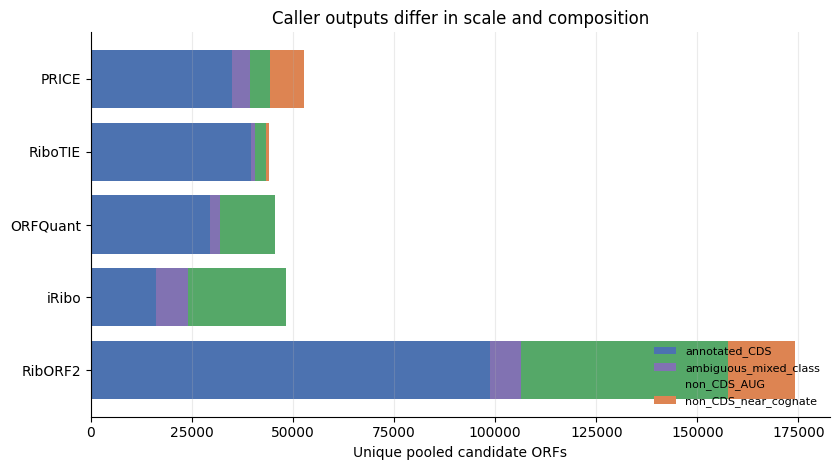

Saved figures_talk_foundation/01_caller_universe.png


In [32]:
if calls_pooled.empty or context_df.empty:
    plot_caller_universe_df = pd.DataFrame()
    print('Skipping caller universe: pooled calls or context are unavailable.')
else:
    plot_caller_universe_df = (
        calls_pooled[['source_tool', 'feature_key']]
        .drop_duplicates()
        .merge(context_df[['feature_key', 'context_class']], on='feature_key', how='left')
        .groupby(['source_tool', 'context_class'])['feature_key']
        .nunique()
        .reset_index(name='n_candidates')
    )
    save_table(plot_caller_universe_df, '01_caller_universe')
    show_df('plot_caller_universe_df', plot_caller_universe_df, 20)

    pivot = plot_caller_universe_df.pivot_table(index='source_tool', columns='context_class', values='n_candidates', fill_value=0)
    pivot = pivot.reindex(index=[t for t in TOOL_ORDER if t in pivot.index], columns=[c for c in CONTEXT_ORDER if c in pivot.columns], fill_value=0)
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    left = np.zeros(len(pivot))
    y = np.arange(len(pivot))
    for cls in pivot.columns:
        vals = pivot[cls].values
        ax.barh(y, vals, left=left, color=CONTEXT_COLORS.get(cls, '0.5'), label=cls)
        left += vals
    ax.set_yticks(y)
    ax.set_yticklabels(pivot.index)
    ax.invert_yaxis()
    ax.set_xlabel('Unique pooled candidate ORFs')
    ax.set_title('Caller outputs differ in scale and composition')
    ax.grid(axis='x', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc='lower right')
    finish_plot(fig, '01_caller_universe.png')


Saved tables_talk_foundation/01_caller_universe_paired_stacked.tsv
plot_caller_universe_df: shape=(18, 4)


,source_tool,annotation_status,context_class,n_candidates
0,ORFQuant,annotated,annotated_CDS,29484
1,ORFQuant,non_annotated,ambiguous_mixed_class,2524
2,ORFQuant,non_annotated,non_CDS_AUG,13601
3,PRICE,annotated,annotated_CDS,35050
4,PRICE,non_annotated,ambiguous_mixed_class,4456
5,PRICE,non_annotated,non_CDS_AUG,4721
6,PRICE,non_annotated,non_CDS_near_cognate,8405
7,RibORF2,annotated,annotated_CDS,98627
8,RibORF2,non_annotated,ambiguous_mixed_class,7853
9,RibORF2,non_annotated,non_CDS_AUG,51186


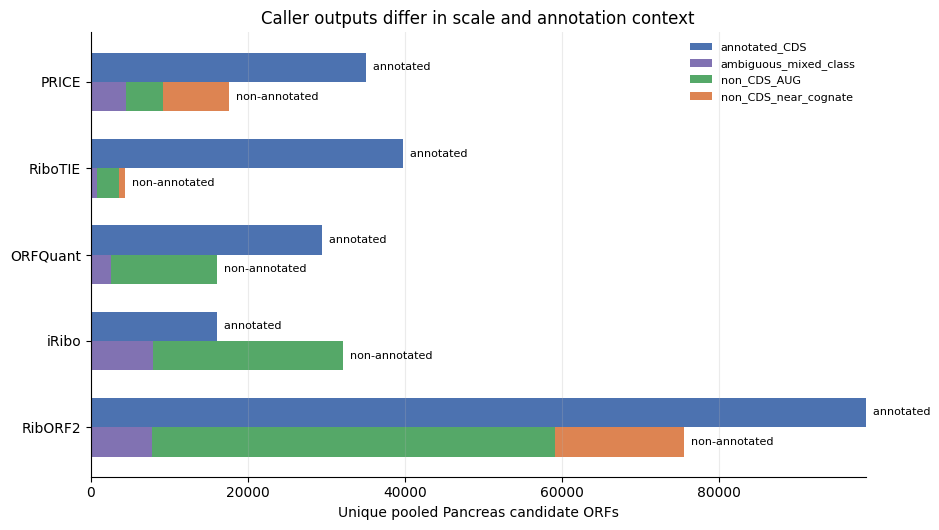

Saved figures_talk_foundation/01_caller_universe_paired_stacked.png


In [49]:
ANNOTATED_CONTEXTS = {
    "annotated_CDS",
    # add others here if they are genuinely annotation-supported
    # "annotated_uORF",
    # "annotated_non_CDS",
}

def annotation_status(context_class):
    if pd.isna(context_class):
        return "non_annotated"
    if context_class in ANNOTATED_CONTEXTS:
        return "annotated"
    return "non_annotated"


if calls_pooled.empty or context_df.empty:
    plot_caller_universe_df = pd.DataFrame()
    print("Skipping caller universe: pooled calls or context are unavailable.")
else:
    plot_caller_universe_df = (
        calls_pooled[["source_tool", "feature_key"]]
        .drop_duplicates()
        .merge(
            context_df[["feature_key", "context_class"]],
            on="feature_key",
            how="left"
        )
    )

    plot_caller_universe_df["annotation_status"] = (
        plot_caller_universe_df["context_class"].apply(annotation_status)
    )

    plot_caller_universe_df = (
        plot_caller_universe_df
        .groupby(["source_tool", "annotation_status", "context_class"], dropna=False)["feature_key"]
        .nunique()
        .reset_index(name="n_candidates")
    )

    save_table(plot_caller_universe_df, "01_caller_universe_paired_stacked")
    show_df("plot_caller_universe_df", plot_caller_universe_df, 30)

    pivot = plot_caller_universe_df.pivot_table(
        index=["source_tool", "annotation_status"],
        columns="context_class",
        values="n_candidates",
        fill_value=0,
        aggfunc="sum",
    )

    tool_order = [t for t in TOOL_ORDER if t in pivot.index.get_level_values("source_tool")]
    status_order = ["annotated", "non_annotated"]

    context_order = [c for c in CONTEXT_ORDER if c in pivot.columns]

    # Ensure all tool/status pairs exist, even if zero.
    full_index = pd.MultiIndex.from_product(
        [tool_order, status_order],
        names=["source_tool", "annotation_status"]
    )

    pivot = pivot.reindex(
        index=full_index,
        columns=context_order,
        fill_value=0,
    )

    fig, ax = plt.subplots(figsize=(9.5, 5.4))

    y_base = np.arange(len(tool_order))
    bar_height = 0.34

    y_pos = {
        "annotated": y_base - bar_height / 2,
        "non_annotated": y_base + bar_height / 2,
    }

    status_label = {
        "annotated": "annotated",
        "non_annotated": "non-annotated",
    }

    for status in status_order:
        sub = pivot.xs(status, level="annotation_status")
        left = np.zeros(len(sub))

        for cls in context_order:
            vals = sub[cls].values
            ax.barh(
                y_pos[status],
                vals,
                height=bar_height,
                left=left,
                color=CONTEXT_COLORS.get(cls, "0.5"),
                label=cls if status == status_order[0] else None,
            )
            left += vals

        # Optional right-side labels for the paired bars
        totals = sub.sum(axis=1).values
        for y, total in zip(y_pos[status], totals):
            ax.text(
                total,
                y,
                f"  {status_label[status]}",
                va="center",
                fontsize=8,
            )

    ax.set_yticks(y_base)
    ax.set_yticklabels(tool_order)
    ax.invert_yaxis()

    ax.set_xlabel("Unique pooled Pancreas candidate ORFs")
    ax.set_title("Caller outputs differ in scale and annotation context")

    ax.grid(axis="x", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="upper right",
        title=None,
    )

    finish_plot(fig, "01_caller_universe_paired_stacked.png")

Saved tables_talk_foundation/calls_pancreas_instances.tsv
calls_pancreas_instances: shape=(1668738, 13)


,source_tool,sample_id,cls,feature_key,bed_chrom,bed_start,bed_end,bed_strand,block_sizes,block_starts,spliced_length_nt,start_codon_class,terminal_codon_class
0,ORFQuant,SRR11005875_to_79,cds,"chr10:100042426-100081625:-:147,119,100,140,11...",chr10,100042426,100081625,-,"147,119,100,140,112,183,156,197,223","0,6331,11920,14586,21187,22761,27287,33484,38976",1377,ATG,stop
1,ORFQuant,SRR11005875_to_79,cds,"chr10:100152130-100185626:-:222,80,90,92,59,74...",chr10,100152130,100185626,-,"222,80,90,92,59,74,126,62,47,82,113","0,2729,4014,11873,15217,22077,23814,26002,2707...",1047,ATG,stop
2,ORFQuant,SRR11005875_to_79,cds,"chr10:100189597-100229484:-:30,100,134,148,97,...",chr10,100189597,100229484,-,"30,100,134,148,97,50,110,62,152,124,103,195,13...","0,1271,3700,4386,4827,10373,11073,12490,14908,...",2190,ATG,stop
3,ORFQuant,SRR11005875_to_79,cds,"chr10:100233226-100267593:-:145,98,120,210,80,...",chr10,100233226,100267593,-,"145,98,120,210,80,115,141,85,119,215,102,79,85,23","0,2440,3623,4795,10471,12572,13568,17021,20194...",1617,ATG,stop
4,ORFQuant,SRR11005875_to_79,cds,"chr10:100275461-100286659:-:32,105,120,117,55:...",chr10,100275461,100286659,-,"32,105,120,117,55","0,4662,5472,10635,11143",429,ATG,stop
5,ORFQuant,SRR11005875_to_79,cds,"chr10:100347504-100360933:+:27,283,131,206,233...",chr10,100347504,100360933,+,"27,283,131,206,233,200","0,559,4861,6922,9027,13229",1080,ATG,stop
6,ORFQuant,SRR11005875_to_79,non_cds,chr10:100373644-100373779:+:135:0,chr10,100373644,100373779,+,135,0,135,ATG,stop
7,ORFQuant,SRR11005875_to_79,non_cds,"chr10:100373946-100380991:+:66,9:0,7036",chr10,100373946,100380991,+,"66,9","0,7036",75,ATG,stop
8,ORFQuant,SRR11005875_to_79,non_cds,"chr10:100373946-100388040:+:66,233,4:0,7269,14090",chr10,100373946,100388040,+,"66,233,4","0,7269,14090",303,ATG,stop
9,ORFQuant,SRR11005875_to_79,non_cds,"chr10:100373946-100395181:+:66,233,73:0,7269,2...",chr10,100373946,100395181,+,"66,233,73","0,7269,21162",372,ATG,stop


Saved tables_talk_foundation/01b_caller_universe_by_pancreas_sample.tsv
plot_sample_caller_universe_df: shape=(138, 4)


,sample_id,source_tool,context_class,n_candidates
0,SRR11005875_to_79,ORFQuant,ambiguous_mixed_class,1664
1,SRR11005875_to_79,ORFQuant,annotated_CDS,24068
2,SRR11005875_to_79,ORFQuant,non_CDS_AUG,6427
3,SRR11005875_to_79,ORFQuant,NaN,3284
4,SRR11005875_to_79,PRICE,ambiguous_mixed_class,1734
5,SRR11005875_to_79,PRICE,annotated_CDS,10223
6,SRR11005875_to_79,PRICE,non_CDS_AUG,844
7,SRR11005875_to_79,PRICE,non_CDS_near_cognate,657
8,SRR11005875_to_79,PRICE,NaN,10932
9,SRR11005875_to_79,RibORF2,ambiguous_mixed_class,3102


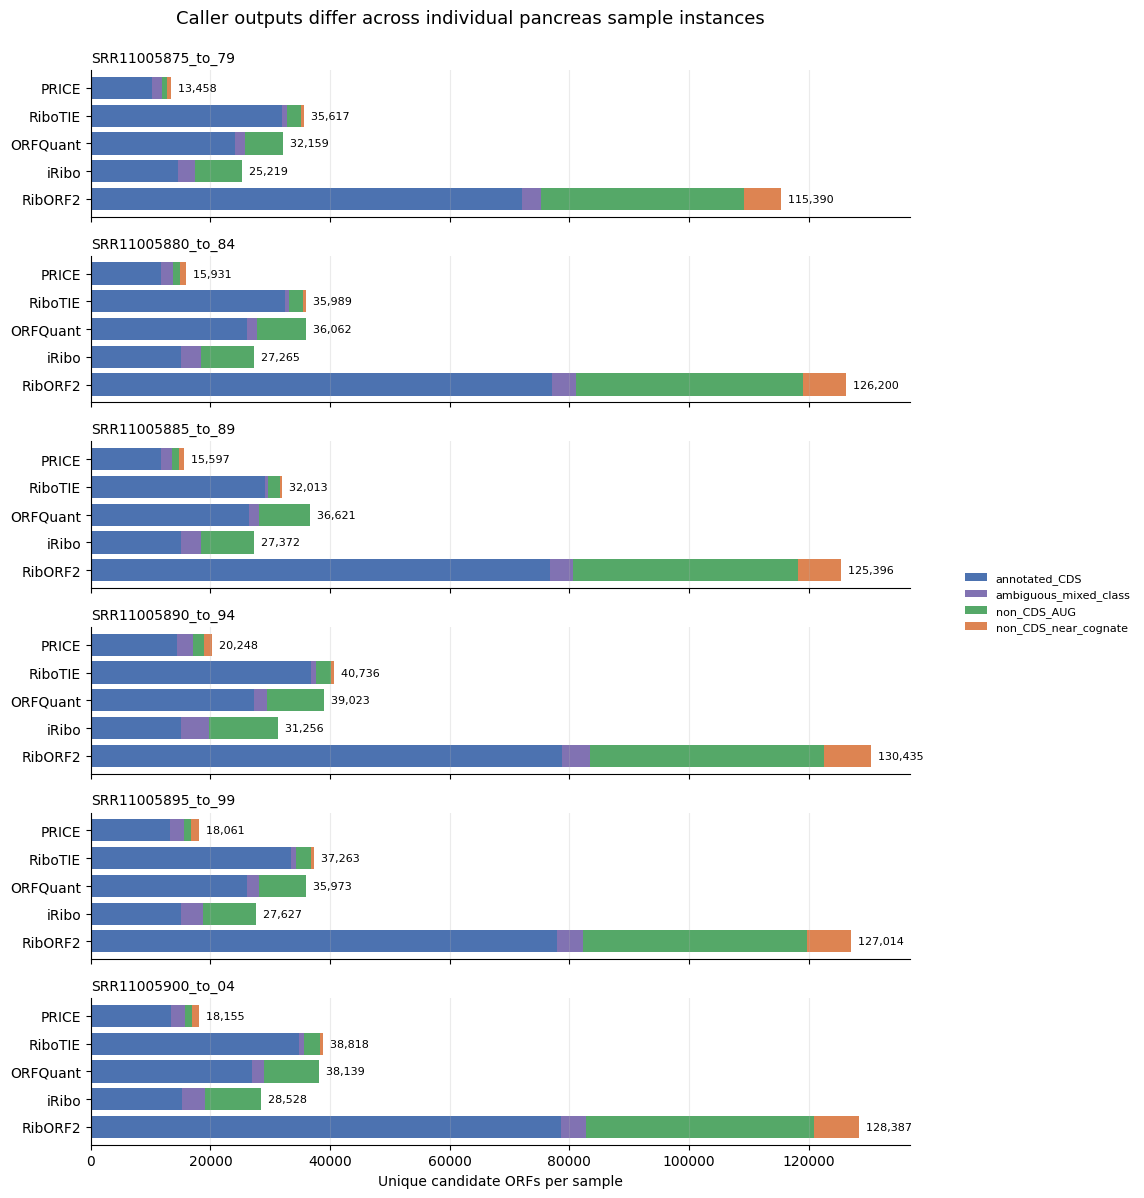

Saved figures_talk_foundation/01b_caller_universe_by_pancreas_sample.png


In [50]:
PANCREAS_INSTANCE_SAMPLES = [
    s for s in PANCREAS_SAMPLES
    if s != PRIMARY_SAMPLE
]

calls_pancreas_instances = (
    calls_raw[calls_raw["sample_id"].isin(PANCREAS_INSTANCE_SAMPLES)]
    .copy()
)

calls_pancreas_instances = (
    calls_pancreas_instances
    .sort_values(["sample_id", "source_tool", "feature_key"])
    .drop_duplicates(["sample_id", "source_tool", "feature_key"])
    .reset_index(drop=True)
)

save_table(calls_pancreas_instances, "calls_pancreas_instances")
show_df("calls_pancreas_instances", calls_pancreas_instances, 20)


if calls_pancreas_instances.empty or context_df.empty:
    plot_sample_caller_universe_df = pd.DataFrame()
    print("Skipping per-sample caller universe: sample calls or context are unavailable.")
else:
    plot_sample_caller_universe_df = (
        calls_pancreas_instances[["sample_id", "source_tool", "feature_key"]]
        .drop_duplicates()
        .merge(
            context_df[["feature_key", "context_class"]],
            on="feature_key",
            how="left",
        )
        .groupby(["sample_id", "source_tool", "context_class"], dropna=False)["feature_key"]
        .nunique()
        .reset_index(name="n_candidates")
    )

    save_table(plot_sample_caller_universe_df, "01b_caller_universe_by_pancreas_sample")
    show_df("plot_sample_caller_universe_df", plot_sample_caller_universe_df, 40)

    context_order = [
        c for c in CONTEXT_ORDER
        if c in plot_sample_caller_universe_df["context_class"].dropna().unique()
    ]

    sample_order = [
        s for s in PANCREAS_INSTANCE_SAMPLES
        if s in plot_sample_caller_universe_df["sample_id"].unique()
    ]

    tool_order = [
        t for t in TOOL_ORDER
        if t in plot_sample_caller_universe_df["source_tool"].unique()
    ]

    n_samples = len(sample_order)

    fig, axes = plt.subplots(
        nrows=n_samples,
        ncols=1,
        figsize=(9.5, max(2.0 * n_samples, 5.5)),
        sharex=True,
    )

    if n_samples == 1:
        axes = [axes]

    for ax, sample_id in zip(axes, sample_order):
        sub_df = plot_sample_caller_universe_df[
            plot_sample_caller_universe_df["sample_id"].eq(sample_id)
        ]

        pivot = (
            sub_df
            .pivot_table(
                index="source_tool",
                columns="context_class",
                values="n_candidates",
                fill_value=0,
                aggfunc="sum",
            )
            .reindex(index=tool_order, columns=context_order, fill_value=0)
        )

        y = np.arange(len(pivot))
        left = np.zeros(len(pivot))

        for cls in context_order:
            vals = pivot[cls].values
            ax.barh(
                y,
                vals,
                left=left,
                color=CONTEXT_COLORS.get(cls, "0.5"),
                label=cls,
            )
            left += vals

        totals = pivot.sum(axis=1).values
        for yi, total in zip(y, totals):
            if total > 0:
                ax.text(
                    total,
                    yi,
                    f"  {int(total):,}",
                    va="center",
                    fontsize=8,
                )

        ax.set_yticks(y)
        ax.set_yticklabels(pivot.index)
        ax.invert_yaxis()

        ax.set_title(sample_id, fontsize=10, loc="left")
        ax.grid(axis="x", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].set_xlabel("Unique candidate ORFs per sample")

    fig.suptitle(
        "Caller outputs differ across individual pancreas sample instances",
        y=0.995,
        fontsize=13,
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.97])

    finish_plot(fig, "01b_caller_universe_by_pancreas_sample.png")

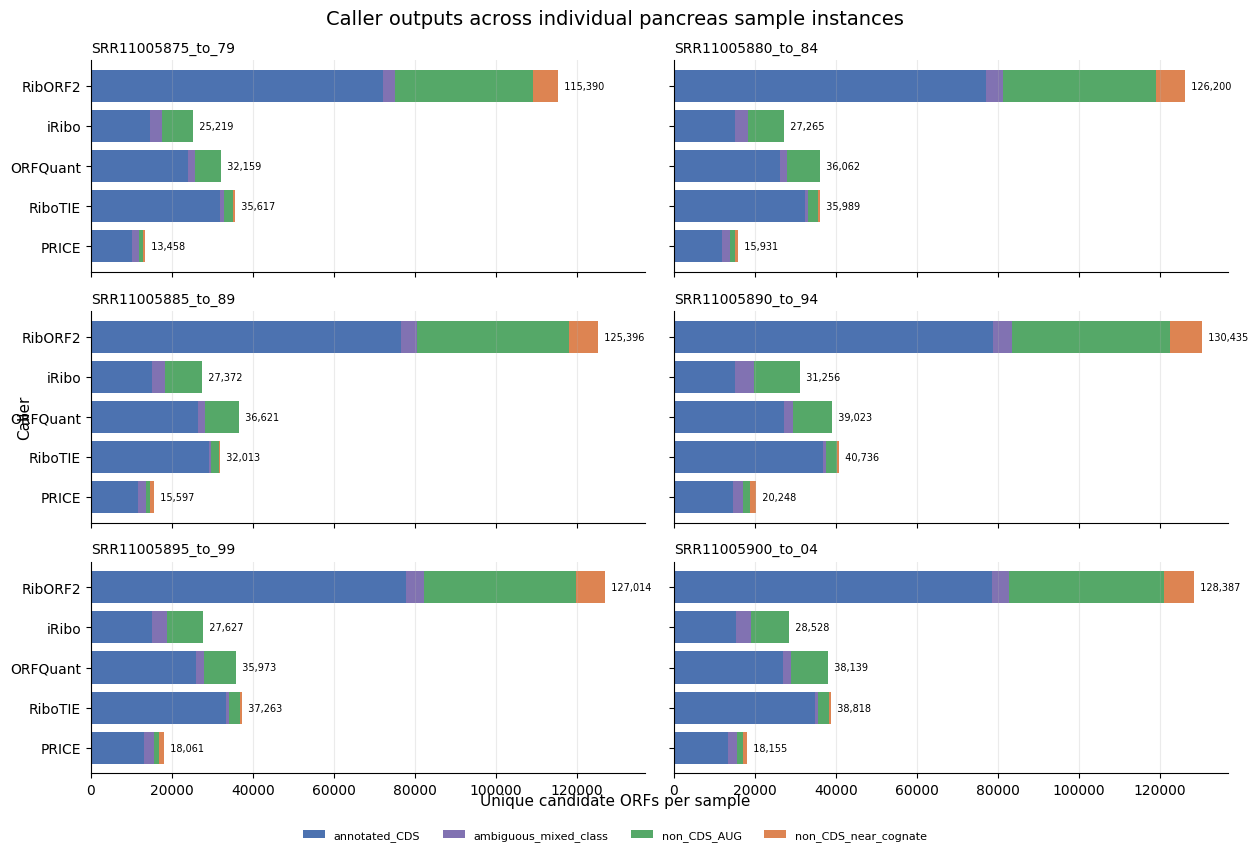

Saved figures_talk_foundation/01b_caller_universe_by_pancreas_sample_grid.png


PosixPath('figures_talk_foundation/01b_caller_universe_by_pancreas_sample_grid.png')

In [51]:
    n_samples = len(sample_order)

    ncols = 2
    nrows = int(np.ceil(n_samples / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(13.0, 8.5),
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).reshape(-1)

    for ax, sample_id in zip(axes, sample_order):
        sub_df = plot_sample_caller_universe_df[
            plot_sample_caller_universe_df["sample_id"].eq(sample_id)
        ]

        pivot = (
            sub_df
            .pivot_table(
                index="source_tool",
                columns="context_class",
                values="n_candidates",
                fill_value=0,
                aggfunc="sum",
            )
            .reindex(index=tool_order, columns=context_order, fill_value=0)
        )

        y = np.arange(len(pivot))
        left = np.zeros(len(pivot))

        for cls in context_order:
            vals = pivot[cls].values
            ax.barh(
                y,
                vals,
                left=left,
                color=CONTEXT_COLORS.get(cls, "0.5"),
                label=cls,
            )
            left += vals

        totals = pivot.sum(axis=1).values
        for yi, total in zip(y, totals):
            if total > 0:
                ax.text(
                    total,
                    yi,
                    f"  {int(total):,}",
                    va="center",
                    fontsize=7,
                )

        ax.set_yticks(y)
        ax.set_yticklabels(pivot.index)
        ax.invert_yaxis()

        ax.set_title(sample_id, fontsize=10, loc="left")
        ax.grid(axis="x", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    # Hide unused panels, if any.
    for ax in axes[n_samples:]:
        ax.set_visible(False)

    fig.suptitle(
        "Caller outputs across individual pancreas sample instances",
        fontsize=14,
        y=0.98,
    )

    fig.supxlabel(
        "Unique candidate ORFs per sample",
        fontsize=11,
        y=0.04,
    )

    fig.supylabel(
        "Caller",
        fontsize=11,
        x=0.04,
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        frameon=False,
        fontsize=8,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=min(len(labels), 5),
    )

    fig.tight_layout(rect=[0.05, 0.08, 1.0, 0.94])

    finish_plot(fig, "01b_caller_universe_by_pancreas_sample_grid.png")

## 8. Plot 2: Agreement geometry


Saved tables_talk_foundation/02_agreement_geometry.tsv
plot_agreement_geometry_df: shape=(12, 4)


,agreement_definition,support_tier,n_units,fraction
0,Full ORF,1 tool,164111,0.689620
1,Full ORF,2 tools,40892,0.171835
2,Full ORF,3 tools,18780,0.078917
3,Full ORF,4+ tools,14190,0.059629
4,Start,1 tool,119701,0.714113
5,Start,2 tools,21588,0.128790
6,Start,3 tools,11609,0.069257
7,Start,4+ tools,14724,0.087840
8,Stop,1 tool,69460,0.511672
9,Stop,2 tools,29886,0.220153


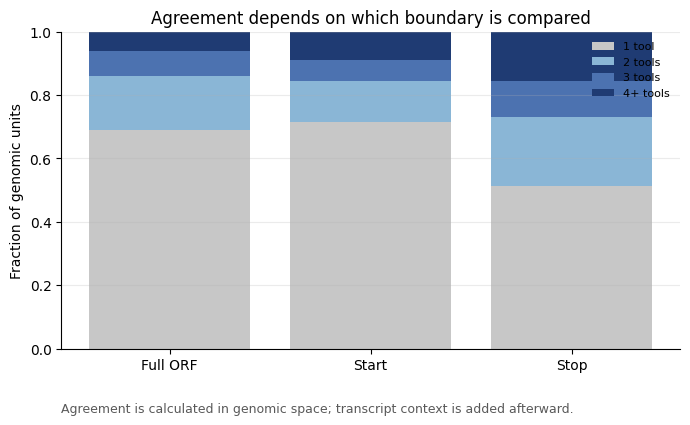

Saved figures_talk_foundation/02_agreement_geometry.png


In [47]:
def agreement_summary_for_key(df, key_col, label):
    if df.empty:
        return pd.DataFrame(columns=['agreement_definition', 'support_tier', 'n_units', 'fraction'])
    counts = df.groupby(key_col)['source_tool'].nunique().reset_index(name='n_tools')
    counts['support_tier'] = counts['n_tools'].map(compact_support_tier)
    out = counts.groupby('support_tier').size().reset_index(name='n_units')
    out['agreement_definition'] = label
    out['fraction'] = out['n_units'] / out['n_units'].sum()
    return out[['agreement_definition', 'support_tier', 'n_units', 'fraction']]

plot_agreement_geometry_df = pd.concat([
    agreement_summary_for_key(calls_pooled, 'full_key', 'Full ORF'),
    agreement_summary_for_key(calls_pooled, 'start_key', 'Start'),
    agreement_summary_for_key(calls_pooled, 'stop_key', 'Stop'),
], ignore_index=True)
save_table(plot_agreement_geometry_df, '02_agreement_geometry')
show_df('plot_agreement_geometry_df', plot_agreement_geometry_df, 20)

if not plot_agreement_geometry_df.empty:
    order_x = ['Full ORF', 'Start', 'Stop']
    tier_order = ['1 tool', '2 tools', '3 tools', '4+ tools']
    pivot = plot_agreement_geometry_df.pivot_table(index='agreement_definition', columns='support_tier', values='fraction', fill_value=0).reindex(index=order_x, columns=tier_order, fill_value=0)
    colors = ['#c7c7c7', '#8ab6d6', '#4C72B0', '#1f3b73']
    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    bottom = np.zeros(len(pivot))
    x = np.arange(len(pivot))
    for tier, color in zip(tier_order, colors):
        vals = pivot[tier].values
        ax.bar(x, vals, bottom=bottom, label=tier, color=color)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Fraction of genomic units')
    ax.set_title('Agreement depends on which boundary is compared')
    ax.text(0.0, -0.20, 'Agreement is calculated in genomic space; transcript context is added afterward.', transform=ax.transAxes, fontsize=9, color='0.35')
    ax.legend(frameon=False, fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    finish_plot(fig, '02_agreement_geometry.png')


Saved tables_talk_foundation/02_agreement_geometry_counts.tsv
plot_agreement_geometry_df: shape=(12, 4)


,unit_definition,support_tier,n_units,fraction
0,Full ORF,1 tool,164111,0.689620
1,Full ORF,2 tools,40892,0.171835
2,Full ORF,3 tools,18780,0.078917
3,Full ORF,4+ tools,14190,0.059629
4,Start,1 tool,119701,0.714113
5,Start,2 tools,21588,0.128790
6,Start,3 tools,11609,0.069257
7,Start,4+ tools,14724,0.087840
8,Stop,1 tool,69460,0.511672
9,Stop,2 tools,29886,0.220153


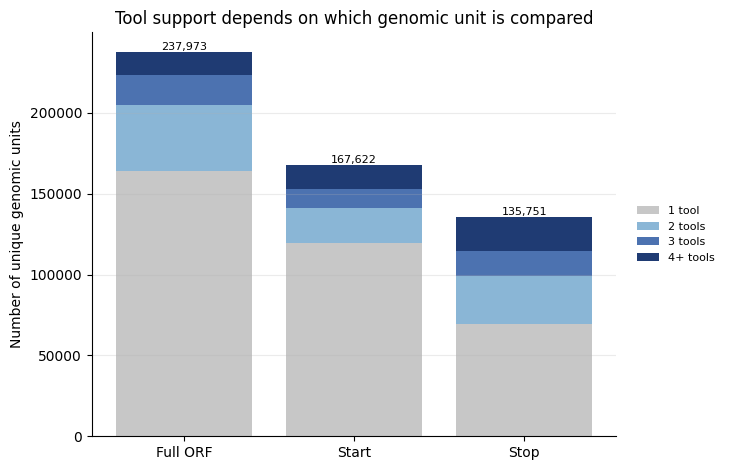

Saved figures_talk_foundation/02_agreement_geometry_counts.png


In [48]:
def tool_support_by_genomic_key(df, key_col, label):
    if df.empty:
        return pd.DataFrame(columns=[
            "unit_definition",
            "support_tier",
            "n_units",
            "fraction"
        ])

    counts = (
        df
        .dropna(subset=[key_col])
        .groupby(key_col)["source_tool"]
        .nunique()
        .reset_index(name="n_tools")
    )

    counts["support_tier"] = counts["n_tools"].map(compact_support_tier)

    out = (
        counts
        .groupby("support_tier")
        .size()
        .reset_index(name="n_units")
    )

    out["unit_definition"] = label
    out["fraction"] = out["n_units"] / out["n_units"].sum()

    return out[["unit_definition", "support_tier", "n_units", "fraction"]]


plot_agreement_geometry_df = pd.concat([
    tool_support_by_genomic_key(calls_pooled, "full_key", "Full ORF"),
    tool_support_by_genomic_key(calls_pooled, "start_key", "Start"),
    tool_support_by_genomic_key(calls_pooled, "stop_key", "Stop"),
], ignore_index=True)

save_table(plot_agreement_geometry_df, "02_agreement_geometry_counts")
show_df("plot_agreement_geometry_df", plot_agreement_geometry_df, 20)


if not plot_agreement_geometry_df.empty:
    order_x = ["Full ORF", "Start", "Stop"]
    tier_order = ["1 tool", "2 tools", "3 tools", "4+ tools"]

    pivot_counts = (
        plot_agreement_geometry_df
        .pivot_table(
            index="unit_definition",
            columns="support_tier",
            values="n_units",
            fill_value=0,
            aggfunc="sum",
        )
        .reindex(index=order_x, columns=tier_order, fill_value=0)
    )

    colors = ["#c7c7c7", "#8ab6d6", "#4C72B0", "#1f3b73"]

    fig, ax = plt.subplots(figsize=(7.4, 4.8))

    bottom = np.zeros(len(pivot_counts))
    x = np.arange(len(pivot_counts))

    for tier, color in zip(tier_order, colors):
        vals = pivot_counts[tier].values
        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=tier,
            color=color,
        )
        bottom += vals

    totals = pivot_counts.sum(axis=1).values

    for xi, total in zip(x, totals):
        ax.text(
            xi,
            total,
            f"{int(total):,}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot_counts.index)

    ax.set_ylabel("Number of unique genomic units")
    ax.set_title("Tool support depends on which genomic unit is compared")

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
    )

    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    finish_plot(fig, "02_agreement_geometry_counts.png")

Saved tables_talk_foundation/02_feature_agreement_by_boundary_definition.tsv
plot_feature_agreement_df: shape=(12, 4)


,agreement_definition,support_tier,n_features,fraction
0,Full ORF,1 tool,164111,0.449943
1,Full ORF,2 tools,81784,0.224227
2,Full ORF,3 tools,56340,0.154467
3,Full ORF,4+ tools,62502,0.171362
4,Same start,1 tool,134753,0.369453
5,Same start,2 tools,53538,0.146785
6,Same start,3 tools,46546,0.127615
7,Same start,4+ tools,129900,0.356147
8,Same stop,1 tool,77917,0.213625
9,Same stop,2 tools,70345,0.192865


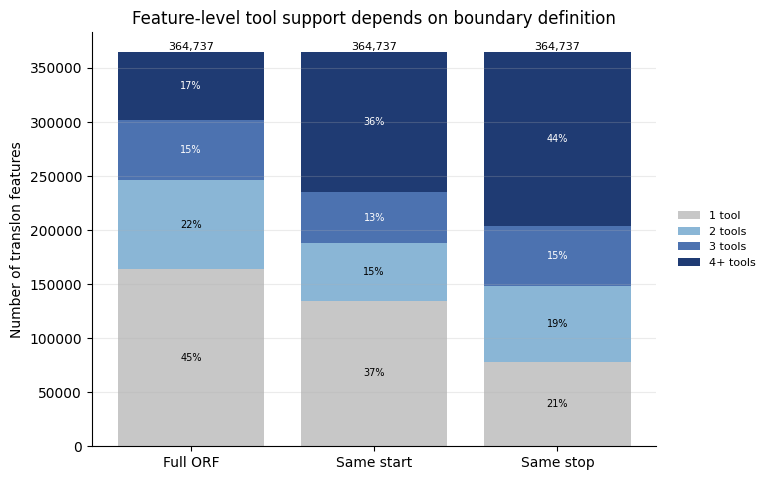

Saved figures_talk_foundation/02_feature_agreement_by_boundary_definition_counts.png


In [53]:
def feature_support_under_key(df, key_col, label):
    """
    For each translon feature/call, ask how many distinct tools share
    the same genomic key under a chosen comparison definition.

    This keeps the denominator as translon features, not unique starts/stops.
    """
    if df.empty:
        return pd.DataFrame(columns=[
            "agreement_definition",
            "support_tier",
            "n_features",
            "fraction"
        ])

    required = {"source_tool", "feature_key", key_col}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns for {label}: {sorted(missing)}")

    # One row per tool-feature call under this key.
    features = (
        df
        .dropna(subset=[key_col])
        [["source_tool", "feature_key", key_col]]
        .drop_duplicates()
        .copy()
    )

    if features.empty:
        return pd.DataFrame(columns=[
            "agreement_definition",
            "support_tier",
            "n_features",
            "fraction"
        ])

    # For each genomic key, count how many distinct tools support it.
    key_support = (
        features
        .groupby(key_col)["source_tool"]
        .nunique()
        .reset_index(name="n_tools")
    )

    # Annotate every translon feature by the support level of its key.
    features = features.merge(key_support, on=key_col, how="left")
    features["support_tier"] = features["n_tools"].map(compact_support_tier)

    out = (
        features
        .groupby("support_tier", dropna=False)
        .size()
        .reset_index(name="n_features")
    )

    out["agreement_definition"] = label
    out["fraction"] = out["n_features"] / out["n_features"].sum()

    return out[[
        "agreement_definition",
        "support_tier",
        "n_features",
        "fraction"
    ]]


# Ensure genomic keys are present.
if not calls_pooled.empty:
    missing_keys = [
        key for key in ["full_key", "start_key", "stop_key"]
        if key not in calls_pooled.columns
    ]
    if missing_keys:
        calls_pooled = add_genomic_keys(calls_pooled)


plot_feature_agreement_df = pd.concat([
    feature_support_under_key(calls_pooled, "full_key", "Full ORF"),
    feature_support_under_key(calls_pooled, "start_key", "Same start"),
    feature_support_under_key(calls_pooled, "stop_key", "Same stop"),
], ignore_index=True)

save_table(
    plot_feature_agreement_df,
    "02_feature_agreement_by_boundary_definition"
)
show_df(
    "plot_feature_agreement_df",
    plot_feature_agreement_df,
    20
)


if plot_feature_agreement_df.empty:
    print("Skipping feature-level agreement plot: no pooled calls available.")
else:
    order_x = ["Full ORF", "Same start", "Same stop"]
    tier_order = ["1 tool", "2 tools", "3 tools", "4+ tools"]

    pivot_counts = (
        plot_feature_agreement_df
        .pivot_table(
            index="agreement_definition",
            columns="support_tier",
            values="n_features",
            fill_value=0,
            aggfunc="sum",
        )
        .reindex(index=order_x, columns=tier_order, fill_value=0)
    )

    pivot_frac = pivot_counts.div(
        pivot_counts.sum(axis=1).replace(0, np.nan),
        axis=0
    )

    colors = ["#c7c7c7", "#8ab6d6", "#4C72B0", "#1f3b73"]

    fig, ax = plt.subplots(figsize=(7.8, 4.9))

    bottom = np.zeros(len(pivot_counts))
    x = np.arange(len(pivot_counts))

    for tier, color in zip(tier_order, colors):
        vals = pivot_counts[tier].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=tier,
            color=color,
        )

        # Optional percent labels inside larger segments.
        for xi, v, b, frac in zip(x, vals, bottom, pivot_frac[tier].values):
            if v > 0 and frac >= 0.08:
                ax.text(
                    xi,
                    b + (v / 2),
                    f"{frac:.0%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if tier in ["3 tools", "4+ tools"] else "black",
                )

        bottom += vals

    totals = pivot_counts.sum(axis=1).values

    for xi, total in zip(x, totals):
        ax.text(
            xi,
            total,
            f"{int(total):,}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot_counts.index)

    ax.set_ylabel("Number of translon features")
    ax.set_title("Feature-level tool support depends on boundary definition")



    ax.legend(
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
    )

    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()

    finish_plot(
        fig,
        "02_feature_agreement_by_boundary_definition_counts.png"
    )

## 9. Plot 3: Context of disagreement


Saved tables_talk_foundation/03_context_by_agreement.tsv
plot_context_by_agreement_df: shape=(10, 4)


,agreement_class,context_class,n_candidates,fraction
0,boundary_agreement,annotated_CDS,58673,0.559547
1,boundary_agreement,non_CDS_AUG,32629,0.311173
2,boundary_agreement,non_CDS_near_cognate,13556,0.129280
3,full_consensus,ambiguous_mixed_class,8501,0.115093
4,full_consensus,annotated_CDS,48475,0.656291
5,full_consensus,non_CDS_AUG,16300,0.220682
6,full_consensus,non_CDS_near_cognate,586,0.007934
7,tool_specific,annotated_CDS,24069,0.406207
8,tool_specific,non_CDS_AUG,24322,0.410477
9,tool_specific,non_CDS_near_cognate,10862,0.183316


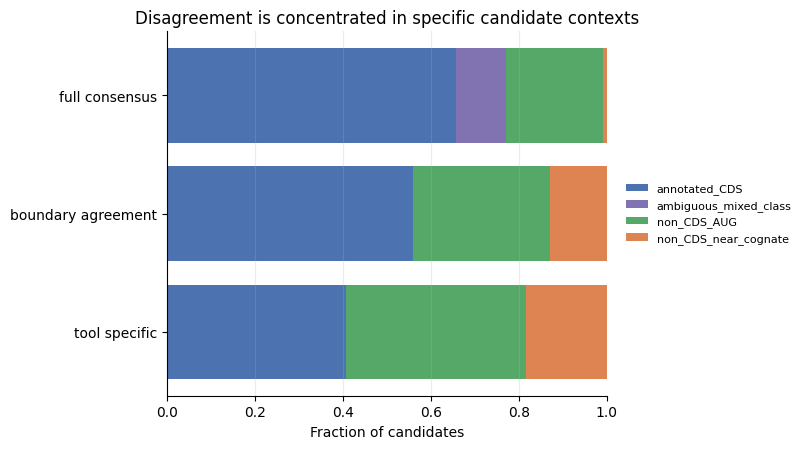

Saved figures_talk_foundation/03_context_by_agreement.png


In [54]:
if agreement_df.empty or context_df.empty:
    plot_context_by_agreement_df = pd.DataFrame()
    print('Skipping context by agreement: inputs unavailable.')
else:
    plot_context_by_agreement_df = (
        agreement_df[['feature_key', 'agreement_class']]
        .merge(context_df[['feature_key', 'context_class']], on='feature_key', how='left')
        .groupby(['agreement_class', 'context_class'])['feature_key']
        .nunique()
        .reset_index(name='n_candidates')
    )
    plot_context_by_agreement_df['fraction'] = plot_context_by_agreement_df.groupby('agreement_class')['n_candidates'].transform(lambda s: s / s.sum())
    save_table(plot_context_by_agreement_df, '03_context_by_agreement')
    show_df('plot_context_by_agreement_df', plot_context_by_agreement_df, 20)

    row_order = [x for x in AGREEMENT_ORDER if x in set(plot_context_by_agreement_df['agreement_class'])]
    col_order = [x for x in CONTEXT_ORDER if x in set(plot_context_by_agreement_df['context_class'])]
    pivot = plot_context_by_agreement_df.pivot_table(index='agreement_class', columns='context_class', values='fraction', fill_value=0).reindex(index=row_order, columns=col_order, fill_value=0)
    fig, ax = plt.subplots(figsize=(8.2, 4.6))
    left = np.zeros(len(pivot))
    y = np.arange(len(pivot))
    for cls in pivot.columns:
        vals = pivot[cls].values
        ax.barh(y, vals, left=left, color=CONTEXT_COLORS.get(cls, '0.5'), label=cls)
        left += vals
    ax.set_yticks(y)
    ax.set_yticklabels([s.replace('_', ' ') for s in pivot.index])
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_xlabel('Fraction of candidates')
    ax.set_title('Disagreement is concentrated in specific candidate contexts')
    ax.grid(axis='x', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc='lower right')
    ax.legend(
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
    )
    finish_plot(fig, '03_context_by_agreement.png')


Saved tables_talk_foundation/03_agreement_by_context.tsv
plot_agreement_by_context_df: shape=(10, 4)


,context_class,agreement_class,n_candidates,fraction
0,ambiguous_mixed_class,full_consensus,8501,1.000000
1,annotated_CDS,boundary_agreement,58673,0.447145
2,annotated_CDS,full_consensus,48475,0.369426
3,annotated_CDS,tool_specific,24069,0.183429
4,non_CDS_AUG,boundary_agreement,32629,0.445441
5,non_CDS_AUG,full_consensus,16300,0.222523
6,non_CDS_AUG,tool_specific,24322,0.332036
7,non_CDS_near_cognate,boundary_agreement,13556,0.542153
8,non_CDS_near_cognate,full_consensus,586,0.023436
9,non_CDS_near_cognate,tool_specific,10862,0.434410


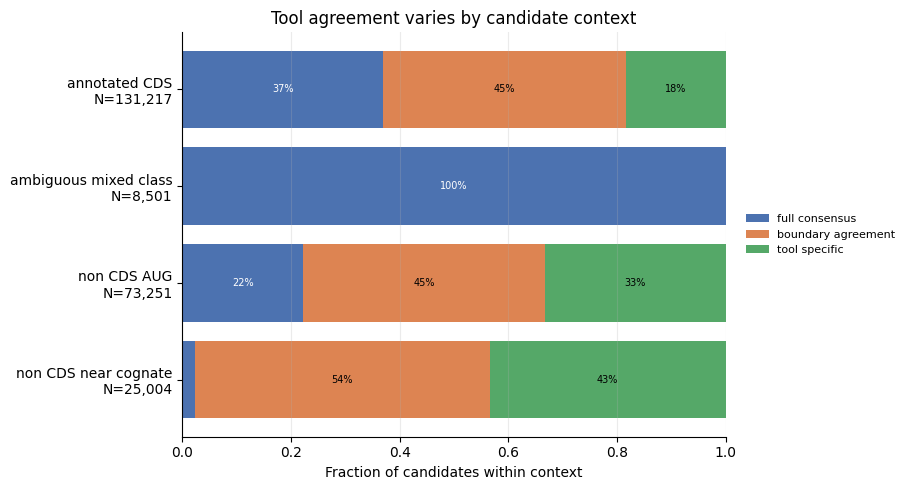

Saved figures_talk_foundation/03_agreement_by_context.png


In [56]:
if agreement_df.empty or context_df.empty:
    plot_agreement_by_context_df = pd.DataFrame()
    print("Skipping agreement by context: inputs unavailable.")
else:
    # For each candidate context, ask what fraction of features fall into each agreement class.
    # This is the inverse of the previous plot and is easier to interpret narratively:
    # "Within annotated_CDS / non_CDS_AUG / near-cognate / etc., how reproducible are calls?"
    plot_agreement_by_context_df = (
        agreement_df[["feature_key", "agreement_class"]]
        .drop_duplicates()
        .merge(
            context_df[["feature_key", "context_class"]].drop_duplicates(),
            on="feature_key",
            how="left",
        )
    )

    plot_agreement_by_context_df["context_class"] = (
        plot_agreement_by_context_df["context_class"]
        .fillna("missing_context")
    )

    plot_agreement_by_context_df = (
        plot_agreement_by_context_df
        .groupby(["context_class", "agreement_class"], dropna=False)["feature_key"]
        .nunique()
        .reset_index(name="n_candidates")
    )

    plot_agreement_by_context_df["fraction"] = (
        plot_agreement_by_context_df
        .groupby("context_class")["n_candidates"]
        .transform(lambda s: s / s.sum())
    )

    save_table(plot_agreement_by_context_df, "03_agreement_by_context")
    show_df("plot_agreement_by_context_df", plot_agreement_by_context_df, 30)

    row_order = [
        x for x in CONTEXT_ORDER
        if x in set(plot_agreement_by_context_df["context_class"])
    ]

    # Keep any unexpected/missing classes at the end rather than silently dropping them.
    extra_contexts = [
        x for x in plot_agreement_by_context_df["context_class"].dropna().unique()
        if x not in row_order
    ]
    row_order = row_order + sorted(extra_contexts)

    col_order = [
        x for x in AGREEMENT_ORDER
        if x in set(plot_agreement_by_context_df["agreement_class"])
    ]

    extra_agreement_classes = [
        x for x in plot_agreement_by_context_df["agreement_class"].dropna().unique()
        if x not in col_order
    ]
    col_order = col_order + sorted(extra_agreement_classes)

    pivot_frac = (
        plot_agreement_by_context_df
        .pivot_table(
            index="context_class",
            columns="agreement_class",
            values="fraction",
            fill_value=0,
            aggfunc="sum",
        )
        .reindex(index=row_order, columns=col_order, fill_value=0)
    )

    pivot_counts = (
        plot_agreement_by_context_df
        .pivot_table(
            index="context_class",
            columns="agreement_class",
            values="n_candidates",
            fill_value=0,
            aggfunc="sum",
        )
        .reindex(index=row_order, columns=col_order, fill_value=0)
    )

    totals = pivot_counts.sum(axis=1)

    fig, ax = plt.subplots(figsize=(9.2, 5.0))

    left = np.zeros(len(pivot_frac))
    y = np.arange(len(pivot_frac))

    for agreement_class in pivot_frac.columns:
        vals = pivot_frac[agreement_class].values

        ax.barh(
            y,
            vals,
            left=left,
            color=AGREEMENT_COLORS.get(agreement_class, "0.5"),
            label=agreement_class.replace("_", " "),
        )

        # Label only reasonably large segments, to avoid clutter.
        for yi, v, lft in zip(y, vals, left):
            if v >= 0.08:
                ax.text(
                    lft + (v / 2),
                    yi,
                    f"{v:.0%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if agreement_class == "full_consensus" else "black",
                )

        left += vals

    ylabels = [
        f"{ctx.replace('_', ' ')}\nN={int(totals.loc[ctx]):,}"
        for ctx in pivot_frac.index
    ]

    ax.set_yticks(y)
    ax.set_yticklabels(ylabels)
    ax.invert_yaxis()

    ax.set_xlim(0, 1)
    ax.set_xlabel("Fraction of candidates within context")
    ax.set_title("Tool agreement varies by candidate context")

    ax.grid(axis="x", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
    )

    fig.tight_layout()

    finish_plot(fig, "03_agreement_by_context.png")

## 10. Plot 4: Start-choice ambiguity


Saved tables_talk_foundation/04_starts_per_stop.tsv
plot_starts_per_stop_df: shape=(135751, 9)


,stop_key,n_starts,n_tools_stop,n_candidates,min_start,max_start,start_span_nt,n_starts_bucket,shared_stop
0,chr10:+:100347364,1,1,1,100347349,100347349,0,1 start,single-tool stop
1,chr10:+:100348187,1,1,1,100347382,100347382,0,1 start,single-tool stop
2,chr10:+:100360933,1,5,1,100347504,100347504,0,1 start,shared by 2+ tools
3,chr10:+:100361069,1,1,1,100361021,100361021,0,1 start,single-tool stop
4,chr10:+:100363097,1,1,1,100362923,100362923,0,1 start,single-tool stop
5,chr10:+:100363780,1,1,1,100363630,100363630,0,1 start,single-tool stop
6,chr10:+:100373779,3,5,3,100373644,100373734,90,3+ starts,shared by 2+ tools
7,chr10:+:100373844,2,3,2,100373661,100373775,114,2 starts,shared by 2+ tools
8,chr10:+:100373898,1,1,1,100373886,100373886,0,1 start,single-tool stop
9,chr10:+:100374138,1,1,1,100373946,100373946,0,1 start,single-tool stop


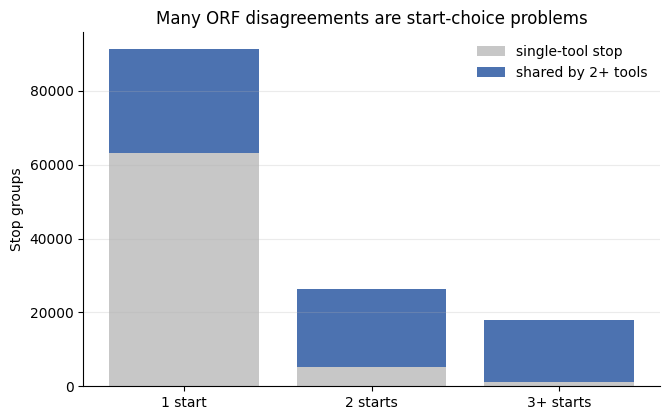

Saved figures_talk_foundation/04_starts_per_stop.png


In [35]:
if calls_pooled.empty:
    plot_starts_per_stop_df = pd.DataFrame()
    print('Skipping starts-per-stop: pooled calls unavailable.')
else:
    stop_groups = (
        calls_pooled
        .groupby('stop_key')
        .agg(
            n_starts=('start_key', 'nunique'),
            n_tools_stop=('source_tool', 'nunique'),
            n_candidates=('feature_key', 'nunique'),
            min_start=('genomic_start', 'min'),
            max_start=('genomic_start', 'max'),
        )
        .reset_index()
    )
    stop_groups['start_span_nt'] = (stop_groups['max_start'] - stop_groups['min_start']).abs()
    stop_groups['n_starts_bucket'] = pd.cut(stop_groups['n_starts'], bins=[0, 1, 2, np.inf], labels=['1 start', '2 starts', '3+ starts'])
    stop_groups['shared_stop'] = np.where(stop_groups['n_tools_stop'].ge(2), 'shared by 2+ tools', 'single-tool stop')
    plot_starts_per_stop_df = stop_groups
    save_table(plot_starts_per_stop_df, '04_starts_per_stop')
    show_df('plot_starts_per_stop_df', plot_starts_per_stop_df, 20)

    summary = plot_starts_per_stop_df.groupby(['n_starts_bucket', 'shared_stop'], observed=False).size().reset_index(name='n_stop_groups')
    pivot = summary.pivot_table(index='n_starts_bucket', columns='shared_stop', values='n_stop_groups', fill_value=0)
    pivot = pivot.reindex(index=['1 start', '2 starts', '3+ starts'])
    fig, ax = plt.subplots(figsize=(6.8, 4.3))
    bottom = np.zeros(len(pivot))
    x = np.arange(len(pivot))
    for col, color in [('single-tool stop', '#c7c7c7'), ('shared by 2+ tools', '#4C72B0')]:
        vals = pivot[col].values if col in pivot else np.zeros(len(pivot))
        ax.bar(x, vals, bottom=bottom, label=col, color=color)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_ylabel('Stop groups')
    ax.set_title('Many ORF disagreements are start-choice problems')
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False)
    finish_plot(fig, '04_starts_per_stop.png')


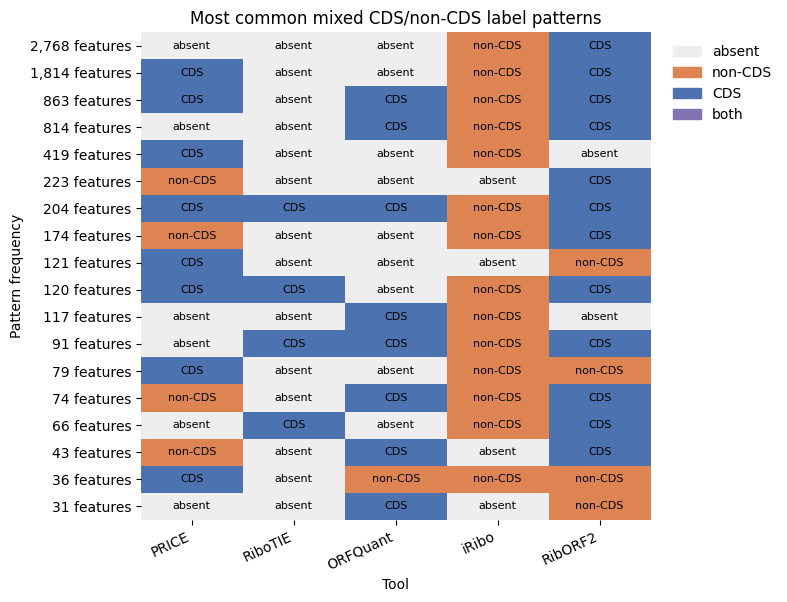

Saved figures_talk_foundation/mixed_label_pattern_heatmap.png


,pattern,n_features
0,absent | absent | absent | non_cds | cds,2768
27,cds | absent | absent | non_cds | cds,1814
31,cds | absent | cds | non_cds | cds,863
3,absent | absent | cds | non_cds | cds,814
26,cds | absent | absent | non_cds | absent,419
58,non_cds | absent | absent | absent | cds,223
43,cds | cds | cds | non_cds | cds,204
59,non_cds | absent | absent | non_cds | cds,174
25,cds | absent | absent | absent | non_cds,121
39,cds | cds | absent | non_cds | cds,120


In [66]:
# Mixed CDS/non-CDS label patterns across tools
# Each row is one recurring feature-level pattern; columns show each tool's label.

import matplotlib.colors
import matplotlib.patches

# One row per feature_key x tool
per_feature_tool_class = (
    mixed_rows
    .groupby(["feature_key", "source_tool"])["cls"]
    .agg(lambda s: "|".join(sorted(set(map(str, s)))))
    .reset_index()
)

tool_disagreement = (
    per_feature_tool_class
    .pivot_table(
        index="feature_key",
        columns="source_tool",
        values="cls",
        aggfunc="first",
        fill_value="absent",
    )
    .reindex(columns=TOOL_ORDER, fill_value="absent")
    .replace({
        "cds|non_cds": "both",
        "non_cds|cds": "both",
    })
)

# Make sure all unexpected / missing values are handled
valid_labels = {"absent", "non_cds", "cds", "both"}
tool_disagreement = tool_disagreement.fillna("absent")
for col in TOOL_ORDER:
    tool_disagreement[col] = tool_disagreement[col].where(
        tool_disagreement[col].isin(valid_labels),
        "both",
    )

pattern_counts = (
    tool_disagreement
    .assign(pattern=lambda d: d[TOOL_ORDER].agg(" | ".join, axis=1))
    .groupby("pattern")
    .size()
    .reset_index(name="n_features")
    .sort_values("n_features", ascending=False)
)

TOP_N = 18
top_patterns = pattern_counts.head(TOP_N).copy()

pattern_matrix = pd.DataFrame(
    top_patterns["pattern"].str.split(" | ", regex=False).tolist(),
    columns=TOOL_ORDER,
)
pattern_matrix["n_features"] = top_patterns["n_features"].to_numpy()

label_to_code = {
    "absent": 0,
    "non_cds": 1,
    "cds": 2,
    "both": 3,
}
code_to_label = {v: k for k, v in label_to_code.items()}

plot_codes = (
    pattern_matrix[TOOL_ORDER]
    .replace(label_to_code)
    .astype(int)
    .to_numpy()
)

cmap = matplotlib.colors.ListedColormap([
    "#eeeeee",  # absent
    "#DD8452",  # non_cds
    "#4C72B0",  # cds
    "#8172B2",  # both
])
norm = matplotlib.colors.BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap.N,
)

fig, ax = plt.subplots(figsize=(8.0, max(4.2, len(pattern_matrix) * 0.34)))

ax.imshow(plot_codes, aspect="auto", cmap=cmap, norm=norm)

ax.set_xticks(np.arange(len(TOOL_ORDER)))
ax.set_xticklabels(TOOL_ORDER, rotation=25, ha="right")

ax.set_yticks(np.arange(len(pattern_matrix)))
ax.set_yticklabels([
    f"{int(n):,} features" for n in pattern_matrix["n_features"]
])

ax.set_title("Most common mixed CDS/non-CDS label patterns")
ax.set_xlabel("Tool")
ax.set_ylabel("Pattern frequency")

for y in range(plot_codes.shape[0]):
    for x in range(plot_codes.shape[1]):
        code = int(plot_codes[y, x])
        label = code_to_label[code]
        pretty = {
            "absent": "absent",
            "non_cds": "non-CDS",
            "cds": "CDS",
            "both": "both",
        }[label]
        ax.text(
            x,
            y,
            pretty,
            ha="center",
            va="center",
            fontsize=8,
            color="black",
        )

handles = [
    matplotlib.patches.Patch(color="#eeeeee", label="absent"),
    matplotlib.patches.Patch(color="#DD8452", label="non-CDS"),
    matplotlib.patches.Patch(color="#4C72B0", label="CDS"),
    matplotlib.patches.Patch(color="#8172B2", label="both"),
]
ax.legend(
    handles=handles,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
fig.tight_layout()

out = OUT_DIR / "mixed_label_pattern_heatmap.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved {out}")
display(top_patterns)

## 11. Plot 5: P-site calibration


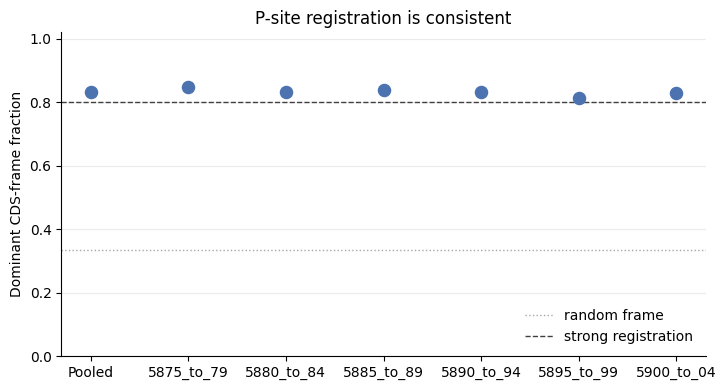

Saved figures_talk_foundation/05_psite_offset_calibration.png


In [67]:
if plot_psite_offsets_df.empty:
    print('Skipping P-site calibration plot: offsets unavailable.')
else:
    plot_df = plot_psite_offsets_df.copy().sort_values('sample_id')
    plot_df['label'] = plot_df['sample_id'].replace({'Ribo_Pancreas_pooled': 'Pooled'}).str.replace('SRR1100', '', regex=False)
    fig, ax = plt.subplots(figsize=(7.4, 4.0))
    x = np.arange(len(plot_df))
    ax.scatter(x, plot_df['dom_frac'], s=76, color='#4C72B0', zorder=3)
    ax.axhline(1/3, color='0.65', linestyle=':', linewidth=1, label='random frame')
    ax.axhline(0.8, color='0.25', linestyle='--', linewidth=1, label='strong registration')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['label'], rotation=0)
    ax.set_ylim(0, 1.02)
    ax.set_ylabel('Dominant CDS-frame fraction')
    ax.set_title('P-site registration is consistent')
    ax.legend(frameon=False, loc='lower right')
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    finish_plot(fig, '05_psite_offset_calibration.png')


## 12. Plot 6: Evidence by candidate class


Saved tables_talk_foundation/06_registered_periodicity_by_class.tsv
plot_registered_periodicity_df: shape=(187890, 59)


,feature_key,sample_id,bed_chrom,bed_start,bed_end,bed_strand,spliced_length_nt,extract_status,orf_signal_nt,mean_cov,...,n_tools_full,n_tools_start,n_tools_stop,agreement_class,context_class,classes_context,start_codon_classes,terminal_codon_classes,spliced_length_nt_context,plot_group
0,"chr10:100042426-100081625:-:147,119,100,140,11...",Ribo_Pancreas_pooled,chr10,100042426,100081625,-,1377,ok,1377,2.637618,...,5,5,5,full_consensus,annotated_CDS,cds,ATG,stop,1377,Annotated CDS
1,chr10:100081539-100081737:-:198:0,Ribo_Pancreas_pooled,chr10,100081539,100081737,-,198,ok,198,1.045455,...,1,1,1,tool_specific,annotated_CDS,cds,near_cognate,stop,198,Annotated CDS
2,chr10:100081788-100081815:-:27:0,Ribo_Pancreas_pooled,chr10,100081788,100081815,-,27,ok,27,5.592593,...,4,4,4,full_consensus,ambiguous_mixed_class,cds|non_cds,ATG,stop,27,Non-CDS candidates
3,"chr10:100152130-100185626:-:222,80,90,92,59,74...",Ribo_Pancreas_pooled,chr10,100152130,100185626,-,1047,ok,1047,11.542502,...,5,5,5,full_consensus,annotated_CDS,cds,ATG,stop,1047,Annotated CDS
4,chr10:100185660-100185771:-:111:0,Ribo_Pancreas_pooled,chr10,100185660,100185771,-,111,ok,111,1.981982,...,4,4,4,full_consensus,ambiguous_mixed_class,cds|non_cds,ATG,stop,111,Non-CDS candidates


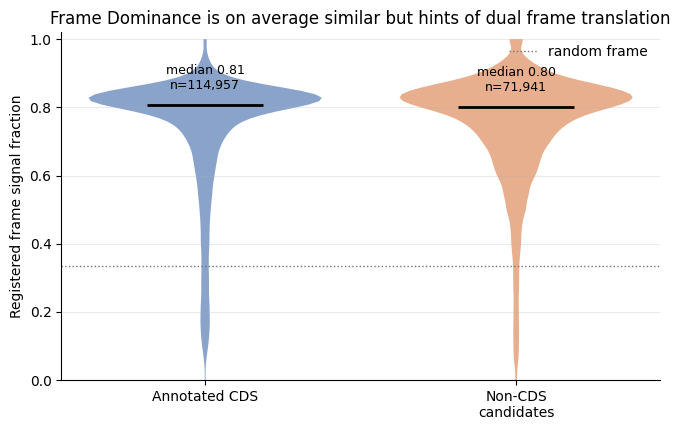

Saved figures_talk_foundation/06_registered_periodicity_by_class.png


In [110]:
if not SCORES_ARE_REGISTERED or evidence_df.empty:
    plot_registered_periodicity_df = pd.DataFrame()
    print('Skipping registered periodicity by class: scores are not registered or evidence_df is empty.')
else:
    plot_registered_periodicity_df = evidence_df[evidence_df['coverage_pass'].astype(bool)].copy()
    plot_registered_periodicity_df['plot_group'] = np.where(plot_registered_periodicity_df['context_class'].eq('annotated_CDS'), 'Annotated CDS', 'Non-CDS candidates')
    save_table(plot_registered_periodicity_df[['feature_key', 'sample_id', 'plot_group', 'periodicity', 'coverage_pass', 'context_class']], '06_registered_periodicity_by_class')
    show_df('plot_registered_periodicity_df', plot_registered_periodicity_df)

    groups = ['Annotated CDS', 'Non-CDS candidates']
    data = [plot_registered_periodicity_df.loc[plot_registered_periodicity_df['plot_group'].eq(g), 'periodicity'].dropna() for g in groups]
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    parts = ax.violinplot(data, positions=[1, 2], widths=0.75, showmedians=True, showextrema=False)
    for body, color in zip(parts['bodies'], ['#4C72B0', '#DD8452']):
        body.set_facecolor(color)
        body.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    for pos, vals in zip([1, 2], data):
        if len(vals):
            ax.text(pos, min(0.98, vals.median() + 0.04), f'median {vals.median():.2f}\nn={len(vals):,}', ha='center', va='bottom', fontsize=9)
    ax.axhline(1/3, color='0.45', linestyle=':', linewidth=1, label='random frame')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Annotated CDS', 'Non-CDS\ncandidates'])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel('Registered frame signal fraction')
    ax.set_title('Frame Dominance is on average similar but hints of dual frame translation')
    ax.legend(frameon=False, loc='upper right')
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    finish_plot(fig, '06_registered_periodicity_by_class.png')


## 13. Plot 7: Evidence by agreement class


Saved tables_talk_foundation/07_evidence_by_agreement.tsv
plot_evidence_by_agreement_df: shape=(187890, 58)


,feature_key,sample_id,bed_chrom,bed_start,bed_end,bed_strand,spliced_length_nt,extract_status,orf_signal_nt,mean_cov,...,source_tools_agreement,n_tools_full,n_tools_start,n_tools_stop,agreement_class,context_class,classes_context,start_codon_classes,terminal_codon_classes,spliced_length_nt_context
0,"chr10:100042426-100081625:-:147,119,100,140,11...",Ribo_Pancreas_pooled,chr10,100042426,100081625,-,1377,ok,1377,2.637618,...,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus,annotated_CDS,cds,ATG,stop,1377
1,chr10:100081539-100081737:-:198:0,Ribo_Pancreas_pooled,chr10,100081539,100081737,-,198,ok,198,1.045455,...,PRICE,1,1,1,tool_specific,annotated_CDS,cds,near_cognate,stop,198
2,chr10:100081788-100081815:-:27:0,Ribo_Pancreas_pooled,chr10,100081788,100081815,-,27,ok,27,5.592593,...,PRICE|ORFQuant|iRibo|RibORF2,4,4,4,full_consensus,ambiguous_mixed_class,cds|non_cds,ATG,stop,27
3,"chr10:100152130-100185626:-:222,80,90,92,59,74...",Ribo_Pancreas_pooled,chr10,100152130,100185626,-,1047,ok,1047,11.542502,...,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus,annotated_CDS,cds,ATG,stop,1047
4,chr10:100185660-100185771:-:111:0,Ribo_Pancreas_pooled,chr10,100185660,100185771,-,111,ok,111,1.981982,...,PRICE|RiboTIE|iRibo|RibORF2,4,4,4,full_consensus,ambiguous_mixed_class,cds|non_cds,ATG,stop,111


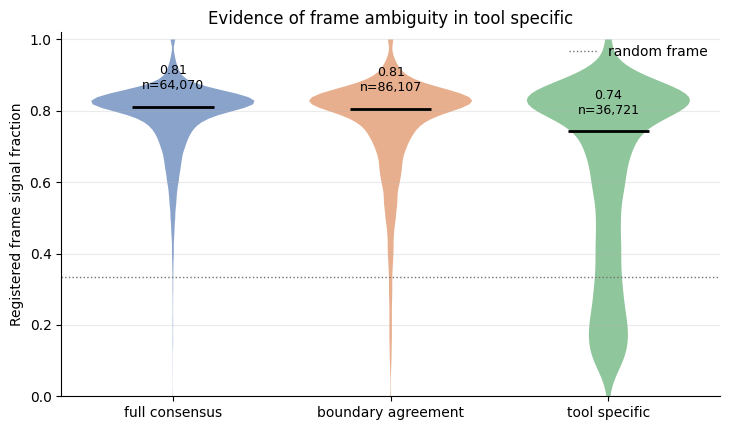

Saved figures_talk_foundation/07_evidence_by_agreement.png


In [109]:
if not SCORES_ARE_REGISTERED or evidence_df.empty:
    plot_evidence_by_agreement_df = pd.DataFrame()
    print('Skipping evidence by agreement: scores are not registered or evidence_df is empty.')
else:
    plot_evidence_by_agreement_df = evidence_df[evidence_df['coverage_pass'].astype(bool)].copy()
    plot_evidence_by_agreement_df = plot_evidence_by_agreement_df[plot_evidence_by_agreement_df['agreement_class'].notna()]
    save_table(plot_evidence_by_agreement_df[['feature_key', 'sample_id', 'agreement_class', 'periodicity', 'context_class']], '07_evidence_by_agreement')
    show_df('plot_evidence_by_agreement_df', plot_evidence_by_agreement_df)

    groups = [g for g in AGREEMENT_ORDER if g in set(plot_evidence_by_agreement_df['agreement_class'])]
    data = [plot_evidence_by_agreement_df.loc[plot_evidence_by_agreement_df['agreement_class'].eq(g), 'periodicity'].dropna() for g in groups]
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    parts = ax.violinplot(data, positions=np.arange(1, len(groups) + 1), widths=0.75, showmedians=True, showextrema=False)
    for body, group in zip(parts['bodies'], groups):
        body.set_facecolor(AGREEMENT_COLORS.get(group, '0.5'))
        body.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    for pos, vals in zip(np.arange(1, len(groups) + 1), data):
        if len(vals):
            ax.text(pos, min(0.98, vals.median() + 0.04), f'{vals.median():.2f}\nn={len(vals):,}', ha='center', va='bottom', fontsize=9)
    ax.axhline(1/3, color='0.45', linestyle=':', linewidth=1, label='random frame')
    ax.set_xticks(np.arange(1, len(groups) + 1))
    ax.set_xticklabels([g.replace('_', ' ') for g in groups])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel('Registered frame signal fraction')
    ax.set_title('Evidence of frame ambiguity in tool specific')
    ax.legend(frameon=False, loc='upper right')
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    finish_plot(fig, '07_evidence_by_agreement.png')


## 14. Plot 8: Coverage-pass by tool


Saved tables_talk_foundation/08_coverage_pass_by_tool.tsv
plot_coverage_pass_by_tool_df: shape=(5, 3)


,tool,fraction_coverage_pass,n_candidates
0,ORFQuant,0.848276,45609
1,PRICE,0.835233,52632
2,RibORF2,0.848843,174091
3,RiboTIE,0.927163,44112
4,iRibo,0.602800,48293


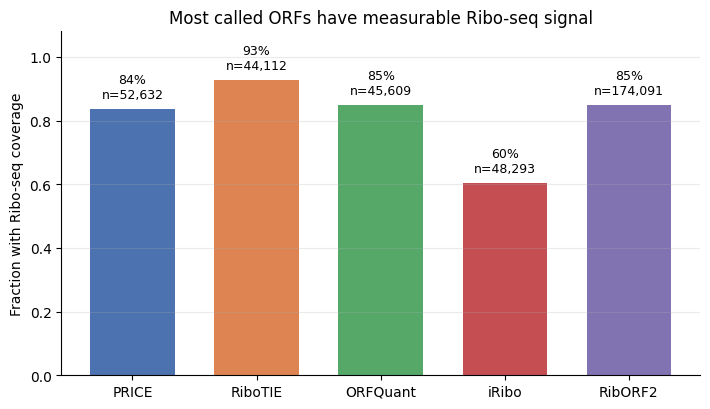

Saved figures_talk_foundation/08_coverage_pass_by_tool.png


In [39]:
if scores_unique.empty:
    plot_coverage_pass_by_tool_df = pd.DataFrame()
    print('Skipping coverage-pass by tool: scores unavailable.')
else:
    scores_for_tool = scores_unique[scores_unique['sample_id'].eq(PRIMARY_SAMPLE)].copy()
    if 'source_tools' not in scores_for_tool:
        plot_coverage_pass_by_tool_df = pd.DataFrame()
        print('Skipping coverage-pass by tool: source_tools column missing.')
    else:
        bt = scores_for_tool.assign(tool=scores_for_tool['source_tools'].fillna('').str.split('|')).explode('tool')
        bt = bt[bt['tool'].isin(TOOL_ORDER)]
        plot_coverage_pass_by_tool_df = (
            bt.groupby('tool')
            .agg(fraction_coverage_pass=('coverage_pass', 'mean'), n_candidates=('feature_key', 'nunique'))
            .reset_index()
        )
        save_table(plot_coverage_pass_by_tool_df, '08_coverage_pass_by_tool')
        show_df('plot_coverage_pass_by_tool_df', plot_coverage_pass_by_tool_df, 20)

        plot_df = plot_coverage_pass_by_tool_df.set_index('tool').reindex([t for t in TOOL_ORDER if t in set(plot_coverage_pass_by_tool_df['tool'])]).reset_index()
        fig, ax = plt.subplots(figsize=(7.2, 4.2))
        bars = ax.bar(plot_df['tool'], plot_df['fraction_coverage_pass'], color=[TOOL_COLORS[t] for t in plot_df['tool']], width=0.68)
        for bar, row in zip(bars, plot_df.itertuples(index=False)):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.025, f'{row.fraction_coverage_pass:.0%}\nn={int(row.n_candidates):,}', ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, 1.08)
        ax.set_ylabel('Fraction with Ribo-seq coverage')
        ax.set_title('Most called ORFs have measurable Ribo-seq signal')
        ax.grid(axis='y', alpha=0.25)
        ax.spines[['top', 'right']].set_visible(False)
        finish_plot(fig, '08_coverage_pass_by_tool.png')


route_calls (3160080, 14)


,sample_id,source_tool,cls,input_route,feature_key,bed_chrom,bed_start,bed_end,bed_strand,block_sizes,block_starts,start_codon_class,terminal_codon_class,spliced_length_nt
112649,SRR11005875_to_79,iRibo,cds,bam_to_orf,"chr1:924431-944153:+:517,92,182,51,125,90,141,...",chr1,924431,944153,+,"517,92,182,51,125,90,141,163,116,79,500,125,11...","0,1490,5723,6607,11340,14608,14840,16712,17704...",ATG,stop,2538
112650,SRR11005875_to_79,iRibo,cds,bam_to_orf,"chr1:944693-959240:-:107,90,136,114,144,102,11...",chr1,944693,959240,-,"107,90,136,114,144,102,114,112,140,189,114,111...","0,363,824,1479,1708,3437,3796,6433,7306,7718,8...",ATG,stop,2250
112651,SRR11005875_to_79,iRibo,cds,bam_to_orf,"chr1:960693-965191:+:107,260,122,222,117,214,1...",chr1,960693,965191,+,"107,260,122,222,117,214,145,168,89,74,182,229","0,599,935,1132,1661,2010,2415,2643,3226,3413,3...",ATG,stop,1929
112652,SRR11005875_to_79,iRibo,cds,bam_to_orf,"chr1:966531-974575:+:83,100,147,81,321,132,81,...",chr1,966531,974575,+,"83,100,147,81,321,132,81,76,137,150,141,141,21...","0,172,3745,3989,4154,4545,4792,5543,5756,6329,...",ATG,stop,1992
112653,SRR11005875_to_79,iRibo,cds,bam_to_orf,"chr1:999058-999973:-:374,88,282:0,467,633",chr1,999058,999973,-,"374,88,282","0,467,633",ATG,stop,744


route_overlap_df (60, 12)


,sample_id,source_tool,cls,bam_n,fastq_n,shared_n,bam_only_n,fastq_only_n,union_n,jaccard,shared_frac_of_bam,shared_frac_of_fastq
0,SRR11005875_to_79,ORFQuant,cds,24981,26371,23542,1439,2829,27810,0.846530,0.942396,0.892723
1,SRR11005875_to_79,ORFQuant,non_cds,5173,6590,4118,1055,2472,7645,0.538653,0.796056,0.624886
2,SRR11005875_to_79,PRICE,cds,19134,18717,16473,2661,2244,21378,0.770559,0.860928,0.880109
3,SRR11005875_to_79,PRICE,non_cds,2612,2742,2136,476,606,3218,0.663766,0.817764,0.778993
4,SRR11005875_to_79,RibORF2,cds,81689,80804,78348,3341,2456,84145,0.931107,0.959101,0.969605


Saved tables_talk_foundation/route_calls_bam_vs_fastq.tsv
Saved tables_talk_foundation/route_overlap_bam_vs_fastq.tsv
plot_route_overlap_df (10, 9)


,source_tool,cls,shared_n,bam_only_n,fastq_only_n,union_n,shared_frac,bam_only_frac,fastq_only_frac
0,ORFQuant,cds,149227,11096,20401,180724,0.825718,0.061397,0.112885
1,ORFQuant,non_cds,32374,8448,18253,59075,0.548015,0.143005,0.308980
2,PRICE,cds,115007,17243,14417,146667,0.784137,0.117566,0.098298
3,PRICE,non_cds,19325,3923,4888,28136,0.686842,0.139430,0.173728
4,RibORF2,cds,501555,21694,19755,543004,0.923667,0.039952,0.036381
5,RibORF2,non_cds,287278,41299,18364,346941,0.828031,0.119038,0.052931
6,RiboTIE,cds,167674,26933,25210,219817,0.762789,0.122525,0.114686
7,RiboTIE,non_cds,12421,4554,5284,22259,0.558021,0.204591,0.237387
8,iRibo,cds,89191,372,420,89983,0.991198,0.004134,0.004668
9,iRibo,non_cds,69251,5310,5610,80171,0.863791,0.066233,0.069975


Saved tables_talk_foundation/route_overlap_by_tool_class.tsv


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jackt/projects/all-RiboSeq/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/route_overlap_bam_vs_fastq.png'

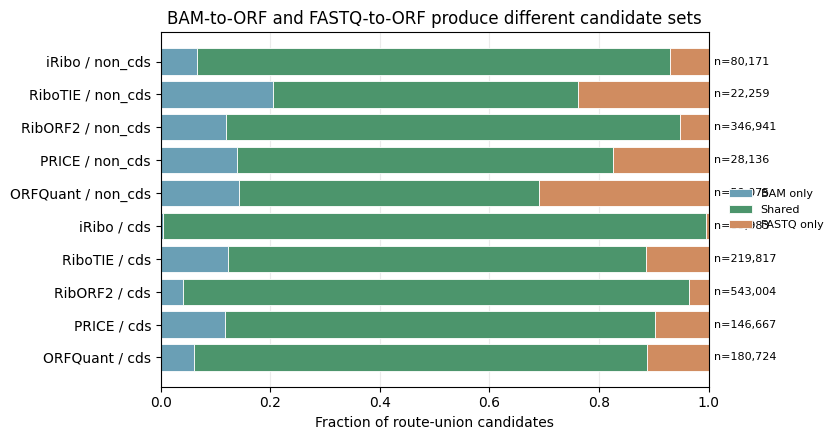

In [105]:
# BAM-to-ORF vs FASTQ-to-ORF route comparison
# Uses QC-pass translon DB calls and compares exact feature_key overlap.

PANCREAS_FASTQ_SAMPLES = [
    "SRR11005875_to_79",
    "SRR11005880_to_84",
    "SRR11005885_to_89",
    "SRR11005890_to_94",
    "SRR11005895_to_99",
    "SRR11005900_to_04",
]

route_calls = pd.read_sql_query(
    """
    SELECT
        sample_id,
        source_tool,
        source_feature_class AS cls,
        input_route,
        feature_key,
        bed_chrom,
        bed_start,
        bed_end,
        bed_strand,
        block_sizes,
        block_starts,
        start_codon_class,
        terminal_codon_class,
        spliced_length_nt
    FROM translons
    WHERE qc_status = 'pass'
      AND source_feature_class IN ('cds', 'non_cds')
      AND input_route IN ('bam_to_orf', 'fastq_to_orf')
      AND sample_id NOT GLOB '*_fastq'
    """,
    con,
)

route_calls = route_calls[
    route_calls["sample_id"].isin(PANCREAS_FASTQ_SAMPLES)
].copy()

route_calls = route_calls.drop_duplicates(
    ["sample_id", "source_tool", "cls", "input_route", "feature_key"]
)

print("route_calls", route_calls.shape)
display(route_calls.head())

# Candidate overlap per sample/tool/class
route_overlap_rows = []

for (sample_id, tool, cls), g in route_calls.groupby(["sample_id", "source_tool", "cls"]):
    bam = set(g.loc[g["input_route"] == "bam_to_orf", "feature_key"])
    fastq = set(g.loc[g["input_route"] == "fastq_to_orf", "feature_key"])

    union = bam | fastq
    shared = bam & fastq

    if not union:
        continue

    route_overlap_rows.append({
        "sample_id": sample_id,
        "source_tool": tool,
        "cls": cls,
        "bam_n": len(bam),
        "fastq_n": len(fastq),
        "shared_n": len(shared),
        "bam_only_n": len(bam - fastq),
        "fastq_only_n": len(fastq - bam),
        "union_n": len(union),
        "jaccard": len(shared) / len(union),
        "shared_frac_of_bam": len(shared) / len(bam) if bam else np.nan,
        "shared_frac_of_fastq": len(shared) / len(fastq) if fastq else np.nan,
    })

route_overlap_df = pd.DataFrame(route_overlap_rows)

print("route_overlap_df", route_overlap_df.shape)
display(route_overlap_df.head())

save_table(route_calls, "route_calls_bam_vs_fastq")
save_table(route_overlap_df, "route_overlap_bam_vs_fastq")

# Aggregate by tool/class for a talk-readable plot
plot_route_overlap_df = (
    route_overlap_df
    .groupby(["source_tool", "cls"], as_index=False)[
        ["shared_n", "bam_only_n", "fastq_only_n", "union_n"]
    ]
    .sum()
)

for col in ["shared_n", "bam_only_n", "fastq_only_n"]:
    plot_route_overlap_df[col.replace("_n", "_frac")] = (
        plot_route_overlap_df[col] / plot_route_overlap_df["union_n"]
    )

print("plot_route_overlap_df", plot_route_overlap_df.shape)
display(plot_route_overlap_df)

save_table(plot_route_overlap_df, "route_overlap_by_tool_class")

# Plot: route-specific versus shared calls
plot_df = plot_route_overlap_df.copy()
plot_df["tool_class"] = plot_df["source_tool"] + " / " + plot_df["cls"]

plot_df = plot_df.sort_values(["cls", "source_tool"])

fig, ax = plt.subplots(figsize=(8.5, max(4.5, len(plot_df) * 0.38)))

left = np.zeros(len(plot_df))

segments = [
    ("bam_only_frac", "BAM only", "#6a9fb5"),
    ("shared_frac", "Shared", "#4c956c"),
    ("fastq_only_frac", "FASTQ only", "#d08c60"),
]

for col, label, color in segments:
    ax.barh(
        plot_df["tool_class"],
        plot_df[col],
        left=left,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.6,
    )
    left += plot_df[col].to_numpy()

ax.set_xlim(0, 1)
ax.set_xlabel("Fraction of route-union candidates")
ax.set_ylabel("")
ax.set_title("BAM-to-ORF and FASTQ-to-ORF produce different candidate sets")
ax.legend(
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.52, 0.5),
    )
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

for i, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(
        1.01,
        i,
        f"n={int(row['union_n']):,}",
        va="center",
        fontsize=8,
    )

fig.tight_layout()
FIG_DIR = Path("/Users/jackt/projects/all-RiboSeq/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/")
out = FIG_DIR / "route_overlap_bam_vs_fastq.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

In [108]:
ax.legend(
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.22, 0.5),
    )
fig.tight_layout()
FIG_DIR = Path("/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/")
out = FIG_DIR / "route_overlap_bam_vs_fastq.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/route_overlap_bam_vs_fastq.png


In [83]:
# Start-rise comparison for multiple-start / shared-stop groups

START_RISE_SAMPLE = "Ribo_Pancreas_pooled"

multi_start_start_rise_df = evidence_df[
    (evidence_df["sample_id"] == START_RISE_SAMPLE)
    & (evidence_df["coverage_pass"])
    & (evidence_df["stop_key"].notna())
    & (evidence_df["start_key"].notna())
].copy()

# Keep only stop groups with multiple distinct starts
stop_group_stats = (
    multi_start_start_rise_df
    .groupby("stop_key", as_index=False)
    .agg(
        n_starts=("start_key", "nunique"),
        n_candidates=("feature_key", "nunique"),
        n_tools_stop=("n_tools_stop", "max"),
        max_periodicity=("periodicity", "max"),
        max_start_rise=("start_rise_ratio", "max"),
    )
)

multi_stop_keys = stop_group_stats.loc[
    stop_group_stats["n_starts"] >= 2,
    "stop_key"
]

multi_start_start_rise_df = multi_start_start_rise_df[
    multi_start_start_rise_df["stop_key"].isin(multi_stop_keys)
].copy()

# Rank alternative starts within each shared stop.
# Higher start_rise_ratio is treated as stronger local start support.
multi_start_start_rise_df["start_rise_rank_in_stop"] = (
    multi_start_start_rise_df
    .groupby("stop_key")["start_rise_ratio"]
    .rank(method="dense", ascending=False)
)

multi_start_start_rise_df["periodicity_rank_in_stop"] = (
    multi_start_start_rise_df
    .groupby("stop_key")["periodicity"]
    .rank(method="dense", ascending=False)
)

# Simple coordinates for reading the table
multi_start_start_rise_df["start_coord"] = np.where(
    multi_start_start_rise_df["bed_strand"] == "+",
    multi_start_start_rise_df["bed_start"],
    multi_start_start_rise_df["bed_end"],
)

multi_start_start_rise_df["stop_coord"] = np.where(
    multi_start_start_rise_df["bed_strand"] == "+",
    multi_start_start_rise_df["bed_end"],
    multi_start_start_rise_df["bed_start"],
)

cols = [
    "feature_key",
    "source_tools",
    "context_class",
    "bed_chrom",
    "bed_strand",
    "start_coord",
    "stop_coord",
    "stop_key",
    "n_tools_full",
    "n_tools_start",
    "n_tools_stop",
    "periodicity",
    "start_rise_ratio",
    "start_window_mean",
    "start_upstream_mean",
    "body_total_signal",
    "start_rise_rank_in_stop",
    "periodicity_rank_in_stop",
]

multi_start_start_rise_df = multi_start_start_rise_df[
    [c for c in cols if c in multi_start_start_rise_df.columns]
].sort_values(
    ["stop_key", "start_rise_rank_in_stop", "periodicity_rank_in_stop"]
)

print("multi_start_start_rise_df", multi_start_start_rise_df.shape)
display(multi_start_start_rise_df.head(30))

save_table(multi_start_start_rise_df, "multi_start_start_rise_by_stop")

multi_start_start_rise_df (119401, 18)


,feature_key,source_tools,context_class,bed_chrom,bed_strand,start_coord,stop_coord,stop_key,n_tools_full,n_tools_start,n_tools_stop,periodicity,start_rise_ratio,start_window_mean,start_upstream_mean,body_total_signal,start_rise_rank_in_stop,periodicity_rank_in_stop
47,chr10:100373644-100373779:+:135:0,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,non_CDS_AUG,chr10,+,100373644,100373779,chr10:+:100373779,5,5,5,0.810414,1.622222,2.433333,1.500000,749.0,1.0,2.0
48,chr10:100373653-100373779:+:126:0,RibORF2,non_CDS_AUG,chr10,+,100373653,100373779,chr10:+:100373779,1,1,5,0.812668,0.975309,2.633333,2.700000,742.0,2.0,1.0
50,chr10:100373734-100373779:+:45:0,RibORF2,non_CDS_near_cognate,chr10,+,100373734,100373779,chr10:+:100373779,1,1,5,0.687500,0.366935,3.033333,8.266666,112.0,3.0,3.0
72,chr10:100381293-100381452:+:159:0,RibORF2,non_CDS_AUG,chr10,+,100381293,100381452,chr10:+:100381452,1,2,1,0.785714,10.250000,1.366667,0.133333,56.0,1.0,1.0
63,"chr10:100373946-100381452:+:66,237:0,7269",RibORF2,non_CDS_AUG,chr10,+,100373946,100381452,chr10:+:100381452,1,3,1,0.764228,1.500000,0.900000,0.600000,123.0,2.0,2.0
71,"chr10:100381269-100382521:+:179,94:0,1158",PRICE,non_CDS_near_cognate,chr10,+,100381269,100382521,chr10:+:100382521,1,1,4,0.756522,inf,0.333333,0.000000,115.0,1.0,2.0
82,chr10:100382269-100382521:+:252:0,iRibo,non_CDS_AUG,chr10,+,100382269,100382521,chr10:+:100382521,1,1,4,0.650000,inf,0.066667,0.000000,20.0,1.0,5.0
73,"chr10:100381293-100382521:+:155,94:0,1134",ORFQuant|RibORF2,non_CDS_AUG,chr10,+,100381293,100382521,chr10:+:100382521,2,2,4,0.740260,10.250000,1.366667,0.133333,77.0,2.0,3.0
84,chr10:100382464-100382521:+:57:0,RibORF2,non_CDS_AUG,chr10,+,100382464,100382521,chr10:+:100382521,1,1,4,0.733333,1.142857,0.266667,0.233333,15.0,3.0,4.0
70,"chr10:100381106-100382521:+:3,233,94:0,109,1321",PRICE,non_CDS_near_cognate,chr10,+,100381106,100382521,chr10:+:100382521,1,1,4,0.762712,NaN,0.000000,0.000000,118.0,NaN,1.0


Saved tables_talk_foundation/multi_start_start_rise_by_stop.tsv


PosixPath('tables_talk_foundation/multi_start_start_rise_by_stop.tsv')

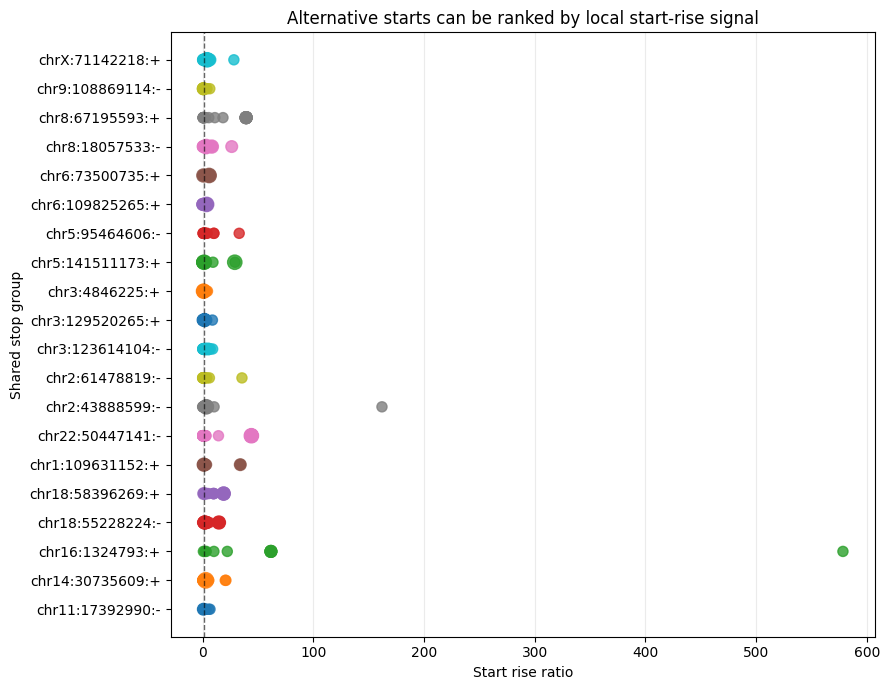

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/start_rise_multiple_starts_per_stop.png


In [84]:
# Plot: start-rise support for alternative starts sharing a stop

TOP_N_STOPS = 20

top_stop_keys = (
    multi_start_start_rise_df
    .groupby("stop_key")
    .agg(
        n_starts=("start_coord", "nunique"),
        max_start_rise=("start_rise_ratio", "max"),
        max_periodicity=("periodicity", "max"),
        n_tools_stop=("n_tools_stop", "max"),
    )
    .sort_values(["n_tools_stop", "n_starts", "max_start_rise"], ascending=False)
    .head(TOP_N_STOPS)
    .index
)

plot_start_rise_by_stop_df = multi_start_start_rise_df[
    multi_start_start_rise_df["stop_key"].isin(top_stop_keys)
].copy()

plot_start_rise_by_stop_df["stop_label"] = (
    plot_start_rise_by_stop_df["bed_chrom"].astype(str)
    + ":"
    + plot_start_rise_by_stop_df["stop_coord"].astype(str)
    + ":"
    + plot_start_rise_by_stop_df["bed_strand"].astype(str)
)

fig, ax = plt.subplots(figsize=(9, max(5, TOP_N_STOPS * 0.35)))

for stop_label, g in plot_start_rise_by_stop_df.groupby("stop_label"):
    g = g.sort_values("start_coord")
    ax.scatter(
        g["start_rise_ratio"],
        [stop_label] * len(g),
        s=35 + (g["n_tools_full"].fillna(1) * 18),
        alpha=0.8,
        label=None,
    )

ax.axvline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Start rise ratio")
ax.set_ylabel("Shared stop group")
ax.set_title("Alternative starts can be ranked by local start-rise signal")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

fig.tight_layout()

out = FIG_DIR / "start_rise_multiple_starts_per_stop.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

In [85]:
# Consensus on alternative starts paired with start-rise signal

ALT_START_SAMPLE = "Ribo_Pancreas_pooled"

alt_start_consensus_df = evidence_df[
    (evidence_df["sample_id"] == ALT_START_SAMPLE)
    & (evidence_df["coverage_pass"])
    & (evidence_df["stop_key"].notna())
    & (evidence_df["start_key"].notna())
    & (evidence_df["start_rise_ratio"].notna())
].copy()

# Keep only stop groups with multiple alternative starts
multi_start_stops = (
    alt_start_consensus_df
    .groupby("stop_key")["start_key"]
    .nunique()
    .loc[lambda s: s >= 2]
    .index
)

alt_start_consensus_df = alt_start_consensus_df[
    alt_start_consensus_df["stop_key"].isin(multi_start_stops)
].copy()

alt_start_consensus_df["start_coord"] = np.where(
    alt_start_consensus_df["bed_strand"] == "+",
    alt_start_consensus_df["bed_start"],
    alt_start_consensus_df["bed_end"],
)

alt_start_consensus_df["stop_coord"] = np.where(
    alt_start_consensus_df["bed_strand"] == "+",
    alt_start_consensus_df["bed_end"],
    alt_start_consensus_df["bed_start"],
)

# Rank starts within each shared-stop group
alt_start_consensus_df["start_rise_rank_in_stop"] = (
    alt_start_consensus_df
    .groupby("stop_key")["start_rise_ratio"]
    .rank(method="dense", ascending=False)
)

alt_start_consensus_df["consensus_rank_in_stop"] = (
    alt_start_consensus_df
    .groupby("stop_key")["n_tools_full"]
    .rank(method="dense", ascending=False)
)

alt_start_consensus_df["is_top_start_rise_in_stop"] = (
    alt_start_consensus_df["start_rise_rank_in_stop"] == 1
)

alt_start_consensus_df["is_top_consensus_in_stop"] = (
    alt_start_consensus_df["consensus_rank_in_stop"] == 1
)

alt_start_consensus_df["support_tier"] = pd.cut(
    alt_start_consensus_df["n_tools_full"],
    bins=[0, 1, 2, 99],
    labels=["1 tool", "2 tools", "3+ tools"],
)

# Per-stop summary: does the most-supported start match the strongest-rise start?
stop_match_df = (
    alt_start_consensus_df
    .assign(
        top_both=lambda d: d["is_top_start_rise_in_stop"] & d["is_top_consensus_in_stop"]
    )
    .groupby("stop_key", as_index=False)
    .agg(
        n_starts=("start_key", "nunique"),
        n_tools_stop=("n_tools_stop", "max"),
        max_start_rise=("start_rise_ratio", "max"),
        max_n_tools_full=("n_tools_full", "max"),
        top_consensus_matches_top_rise=("top_both", "any"),
    )
)

print("alt_start_consensus_df", alt_start_consensus_df.shape)
display(alt_start_consensus_df.head(30))

print("stop_match_df", stop_match_df.shape)
display(stop_match_df.head(20))

match_rate = stop_match_df["top_consensus_matches_top_rise"].mean()
print(
    f"Shared-stop groups where the most-consensus start is also the strongest start-rise start: "
    f"{match_rate:.1%} ({stop_match_df['top_consensus_matches_top_rise'].sum()} / {len(stop_match_df)})"
)

save_table(alt_start_consensus_df, "alt_start_consensus_start_rise")
save_table(stop_match_df, "alt_start_consensus_start_rise_stop_summary")

alt_start_consensus_df (104487, 65)


,feature_key,sample_id,bed_chrom,bed_start,bed_end,bed_strand,spliced_length_nt,extract_status,orf_signal_nt,mean_cov,...,start_codon_classes,terminal_codon_classes,spliced_length_nt_context,start_coord,stop_coord,start_rise_rank_in_stop,consensus_rank_in_stop,is_top_start_rise_in_stop,is_top_consensus_in_stop,support_tier
7,"chr10:100189597-100190952:-:30,84:0,1271",Ribo_Pancreas_pooled,chr10,100189597,100190952,-,114,ok,114,0.552632,...,ATG,stop,114,100190952,100189597,4.0,2.0,False,False,1 tool
9,"chr10:100189597-100229442:-:30,100,134,148,97,...",Ribo_Pancreas_pooled,chr10,100189597,100229442,-,2148,ok,2148,1.582402,...,near_cognate,stop,2148,100229442,100189597,2.0,2.0,False,False,1 tool
10,"chr10:100189597-100229484:-:30,100,134,148,97,...",Ribo_Pancreas_pooled,chr10,100189597,100229484,-,2190,ok,2190,1.569406,...,ATG,stop,2190,100229484,100189597,3.0,2.0,False,False,1 tool
11,"chr10:100189597-100229532:-:30,100,134,148,97,...",Ribo_Pancreas_pooled,chr10,100189597,100229532,-,2238,ok,2238,1.552279,...,ATG,stop,2238,100229532,100189597,1.0,1.0,True,True,3+ tools
12,"chr10:100190948-100194040:-:20,43,57:0,2440,3035",Ribo_Pancreas_pooled,chr10,100190948,100194040,-,120,ok,120,1.441667,...,ATG,stop,120,100194040,100190948,2.0,1.0,False,True,1 tool
13,"chr10:100190948-100194079:-:20,43,96:0,2440,3035",Ribo_Pancreas_pooled,chr10,100190948,100194079,-,159,ok,159,1.735849,...,near_cognate,stop,159,100194079,100190948,1.0,1.0,True,True,1 tool
17,"chr10:100233226-100238219:-:145,98,120,198:0,2...",Ribo_Pancreas_pooled,chr10,100233226,100238219,-,561,ok,561,3.397505,...,near_cognate,stop,561,100238219,100233226,1.0,2.0,True,False,1 tool
18,"chr10:100233226-100245879:-:145,98,120,210,75,...",Ribo_Pancreas_pooled,chr10,100233226,100245879,-,729,ok,729,3.071331,...,ATG,stop,729,100245879,100233226,3.0,2.0,False,False,1 tool
19,"chr10:100233226-100246908:-:145,98,120,210,80,...",Ribo_Pancreas_pooled,chr10,100233226,100246908,-,882,ok,882,3.058957,...,ATG,stop,882,100246908,100233226,2.0,2.0,False,False,1 tool
20,"chr10:100233226-100267593:-:145,98,120,210,80,...",Ribo_Pancreas_pooled,chr10,100233226,100267593,-,1617,ok,1617,3.244280,...,ATG,stop,1617,100267593,100233226,4.0,1.0,False,True,3+ tools


stop_match_df (32055, 6)


,stop_key,n_starts,n_tools_stop,max_start_rise,max_n_tools_full,top_consensus_matches_top_rise
0,chr10:+:100373779,3,5,1.622222,5,True
1,chr10:+:100381452,2,1,10.250000,1,True
2,chr10:+:100382521,4,4,inf,2,False
3,chr10:+:100388040,2,2,10.250000,2,False
4,chr10:+:100388068,2,1,10.250000,1,True
5,chr10:+:100395181,3,2,10.250000,1,True
6,chr10:+:100482816,3,4,0.500000,1,True
7,chr10:+:100913136,2,4,2.356322,4,True
8,chr10:+:100961912,4,3,inf,1,True
9,chr10:+:100972579,3,4,2.333333,3,True


Shared-stop groups where the most-consensus start is also the strongest start-rise start: 60.5% (19389 / 32055)
Saved tables_talk_foundation/alt_start_consensus_start_rise.tsv
Saved tables_talk_foundation/alt_start_consensus_start_rise_stop_summary.tsv


PosixPath('tables_talk_foundation/alt_start_consensus_start_rise_stop_summary.tsv')

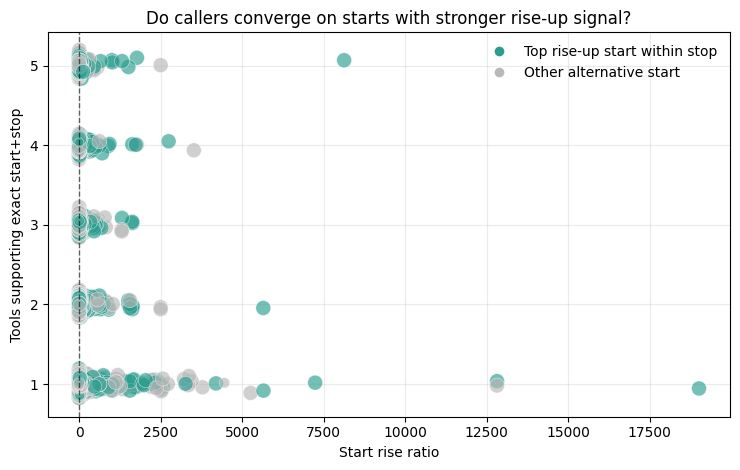

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/alt_start_consensus_vs_start_rise.png


In [86]:
# Plot: consensus support versus start-rise among alternative starts

plot_alt_start_df = alt_start_consensus_df.copy()

fig, ax = plt.subplots(figsize=(7.5, 4.8))

colors = np.where(
    plot_alt_start_df["is_top_start_rise_in_stop"],
    "#2a9d8f",
    "#b8b8b8",
)

# Small vertical jitter so overlapping support tiers are visible
rng = np.random.default_rng(42)
y = plot_alt_start_df["n_tools_full"].astype(float) + rng.normal(
    0, 0.045, size=len(plot_alt_start_df)
)

sizes = 28 + np.clip(plot_alt_start_df["body_total_signal"].fillna(0), 0, 250) * 0.35

ax.scatter(
    plot_alt_start_df["start_rise_ratio"],
    y,
    s=sizes,
    c=colors,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4,
)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_yticks(sorted(plot_alt_start_df["n_tools_full"].dropna().unique()))
ax.set_xlabel("Start rise ratio")
ax.set_ylabel("Tools supporting exact start+stop")
ax.set_title("Do callers converge on starts with stronger rise-up signal?")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#2a9d8f",
        markeredgecolor="white",
        markersize=8,
        label="Top rise-up start within stop",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#b8b8b8",
        markeredgecolor="white",
        markersize=8,
        label="Other alternative start",
    ),
]

ax.legend(handles=legend_handles, frameon=False, loc="best")

fig.tight_layout()

out = FIG_DIR / "alt_start_consensus_vs_start_rise.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

In [87]:
# Clearer view: does the top-consensus start match the strongest-rise start?

ALT_START_SAMPLE = "Ribo_Pancreas_pooled"

alt_start_df = evidence_df[
    (evidence_df["sample_id"] == ALT_START_SAMPLE)
    & (evidence_df["coverage_pass"])
    & (evidence_df["stop_key"].notna())
    & (evidence_df["start_key"].notna())
    & (evidence_df["start_rise_ratio"].notna())
].copy()

# Keep starts with finite, positive-ish values.
# Ratio outliers are common when upstream signal is tiny, so use capped/log display later.
alt_start_df = alt_start_df[np.isfinite(alt_start_df["start_rise_ratio"])].copy()

multi_start_stop_keys = (
    alt_start_df
    .groupby("stop_key")["start_key"]
    .nunique()
    .loc[lambda s: s >= 2]
    .index
)

alt_start_df = alt_start_df[
    alt_start_df["stop_key"].isin(multi_start_stop_keys)
].copy()

alt_start_df["start_coord"] = np.where(
    alt_start_df["bed_strand"] == "+",
    alt_start_df["bed_start"],
    alt_start_df["bed_end"],
)

alt_start_df["stop_coord"] = np.where(
    alt_start_df["bed_strand"] == "+",
    alt_start_df["bed_end"],
    alt_start_df["bed_start"],
)

# Pick one top-consensus and one top-rise candidate per stop.
# Tie-breakers keep the result deterministic.
ranked_by_consensus = alt_start_df.sort_values(
    ["stop_key", "n_tools_full", "periodicity", "body_total_signal", "start_rise_ratio"],
    ascending=[True, False, False, False, False],
)

ranked_by_rise = alt_start_df.sort_values(
    ["stop_key", "start_rise_ratio", "periodicity", "body_total_signal", "n_tools_full"],
    ascending=[True, False, False, False, False],
)

top_consensus = (
    ranked_by_consensus
    .groupby("stop_key", as_index=False)
    .head(1)
    [[
        "stop_key",
        "feature_key",
        "start_key",
        "start_coord",
        "stop_coord",
        "bed_chrom",
        "bed_strand",
        "n_tools_full",
        "n_tools_stop",
        "start_rise_ratio",
        "periodicity",
        "body_total_signal",
        "context_class",
        "source_tools",
    ]]
    .rename(columns={
        "feature_key": "consensus_feature_key",
        "start_key": "consensus_start_key",
        "start_coord": "consensus_start_coord",
        "n_tools_full": "consensus_n_tools_full",
        "start_rise_ratio": "consensus_start_rise_ratio",
        "periodicity": "consensus_periodicity",
        "body_total_signal": "consensus_body_total_signal",
        "context_class": "consensus_context_class",
        "source_tools": "consensus_source_tools",
    })
)

top_rise = (
    ranked_by_rise
    .groupby("stop_key", as_index=False)
    .head(1)
    [[
        "stop_key",
        "feature_key",
        "start_key",
        "start_coord",
        "n_tools_full",
        "start_rise_ratio",
        "periodicity",
        "body_total_signal",
        "context_class",
        "source_tools",
    ]]
    .rename(columns={
        "feature_key": "rise_feature_key",
        "start_key": "rise_start_key",
        "start_coord": "rise_start_coord",
        "n_tools_full": "rise_n_tools_full",
        "start_rise_ratio": "rise_start_rise_ratio",
        "periodicity": "rise_periodicity",
        "body_total_signal": "rise_body_total_signal",
        "context_class": "rise_context_class",
        "source_tools": "rise_source_tools",
    })
)

stop_start_choice_df = top_consensus.merge(top_rise, on="stop_key", how="inner")

extra_stop_stats = (
    alt_start_df
    .groupby("stop_key", as_index=False)
    .agg(
        n_alternative_starts=("start_key", "nunique"),
        n_candidates=("feature_key", "nunique"),
        max_n_tools_full=("n_tools_full", "max"),
        median_start_rise=("start_rise_ratio", "median"),
    )
)

stop_start_choice_df = stop_start_choice_df.merge(extra_stop_stats, on="stop_key", how="left")

stop_start_choice_df["top_consensus_is_top_rise"] = (
    stop_start_choice_df["consensus_start_key"] == stop_start_choice_df["rise_start_key"]
)

stop_start_choice_df["choice_label"] = np.where(
    stop_start_choice_df["top_consensus_is_top_rise"],
    "Same start",
    "Different starts",
)

match_summary = (
    stop_start_choice_df
    .groupby("choice_label", as_index=False)
    .size()
    .rename(columns={"size": "n_stop_groups"})
)

match_summary["fraction"] = match_summary["n_stop_groups"] / match_summary["n_stop_groups"].sum()

print("stop_start_choice_df", stop_start_choice_df.shape)
display(stop_start_choice_df.head(20))

display(match_summary)

save_table(stop_start_choice_df, "shared_stop_top_consensus_vs_top_rise")
save_table(match_summary, "shared_stop_consensus_rise_match_summary")

stop_start_choice_df (26281, 29)


,stop_key,consensus_feature_key,consensus_start_key,consensus_start_coord,stop_coord,bed_chrom,bed_strand,consensus_n_tools_full,n_tools_stop,consensus_start_rise_ratio,...,rise_periodicity,rise_body_total_signal,rise_context_class,rise_source_tools,n_alternative_starts,n_candidates,max_n_tools_full,median_start_rise,top_consensus_is_top_rise,choice_label
0,chr10:+:100373779,chr10:100373644-100373779:+:135:0,chr10:+:100373644,100373644,100373779,chr10,+,5,5,1.622222,...,0.810414,749.0,non_CDS_AUG,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,3,3,5,0.975309,True,Same start
1,chr10:+:100381452,chr10:100381293-100381452:+:159:0,chr10:+:100381293,100381293,100381452,chr10,+,1,1,10.250000,...,0.785714,56.0,non_CDS_AUG,RibORF2,2,2,1,5.875000,True,Same start
2,chr10:+:100382521,"chr10:100381293-100382521:+:155,94:0,1134",chr10:+:100381293,100381293,100382521,chr10,+,2,4,10.250000,...,0.740260,77.0,non_CDS_AUG,ORFQuant|RibORF2,2,2,2,5.696428,True,Same start
3,chr10:+:100388040,"chr10:100373946-100388040:+:66,233,4:0,7269,14090",chr10:+:100373946,100373946,100388040,chr10,+,2,2,1.500000,...,0.785714,56.0,non_CDS_AUG,RibORF2,2,4,2,5.875000,False,Different starts
4,chr10:+:100388068,"chr10:100381293-100388068:+:155,28:0,6747",chr10:+:100381293,100381293,100388068,chr10,+,1,1,10.250000,...,0.779661,59.0,non_CDS_AUG,RibORF2,2,2,1,5.875000,True,Same start
5,chr10:+:100395181,"chr10:100381293-100395181:+:155,73:0,13815",chr10:+:100381293,100381293,100395181,chr10,+,1,2,10.250000,...,0.793651,63.0,non_CDS_AUG,RibORF2,3,3,1,1.500000,True,Same start
6,chr10:+:100482816,chr10:100482276-100482816:+:540:0,chr10:+:100482276,100482276,100482816,chr10,+,1,4,0.500000,...,0.748387,155.0,annotated_CDS,PRICE,3,3,1,0.333333,True,Same start
7,chr10:+:100913136,chr10:100912983-100913136:+:153:0,chr10:+:100912983,100912983,100913136,chr10,+,4,4,2.356322,...,0.858790,347.0,annotated_CDS,ORFQuant|PRICE|RibORF2|RiboTIE,2,2,4,1.343378,True,Same start
8,chr10:+:100961912,"chr10:100913125-100961912:+:125,44,731,58,998,...",chr10:+:100913125,100913125,100961912,chr10,+,1,3,0.198276,...,0.818239,6404.0,annotated_CDS,RibORF2,3,3,1,0.409524,False,Different starts
9,chr10:+:100972579,"chr10:100969567-100972579:+:24,51:0,2961",chr10:+:100969567,100969567,100972579,chr10,+,3,4,2.333333,...,0.895013,381.0,annotated_CDS,ORFQuant|PRICE|RibORF2,3,3,3,1.342593,True,Same start


,choice_label,n_stop_groups,fraction
0,Different starts,14204,0.540466
1,Same start,12077,0.459534


Saved tables_talk_foundation/shared_stop_top_consensus_vs_top_rise.tsv
Saved tables_talk_foundation/shared_stop_consensus_rise_match_summary.tsv


PosixPath('tables_talk_foundation/shared_stop_consensus_rise_match_summary.tsv')

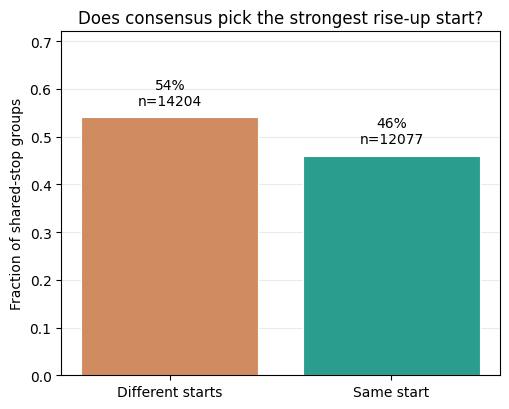

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/alt_start_consensus_matches_top_rise_summary.png


In [88]:
# Plot: simple match/mismatch summary
plot_match = match_summary.copy()

fig, ax = plt.subplots(figsize=(5.2, 4.2))

colors = {
    "Same start": "#2a9d8f",
    "Different starts": "#d08c60",
}

ax.bar(
    plot_match["choice_label"],
    plot_match["fraction"],
    color=[colors.get(x, "#999999") for x in plot_match["choice_label"]],
    edgecolor="white",
    linewidth=0.8,
)

for i, row in plot_match.iterrows():
    ax.text(
        i,
        row["fraction"] + 0.02,
        f"{row['fraction']:.0%}\nn={int(row['n_stop_groups'])}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylim(0, min(1.0, plot_match["fraction"].max() + 0.18))
ax.set_ylabel("Fraction of shared-stop groups")
ax.set_title("Does consensus pick the strongest rise-up start?")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

fig.tight_layout()

out = FIG_DIR / "alt_start_consensus_matches_top_rise_summary.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

/tmp/ipykernel_370071/359506950.py:56: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_370071/359506950.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(out, dpi=200, bbox_inches="tight")
/hps/software/opt/linux-rocky8-cascadelake/anaconda3/envs/jupyter/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


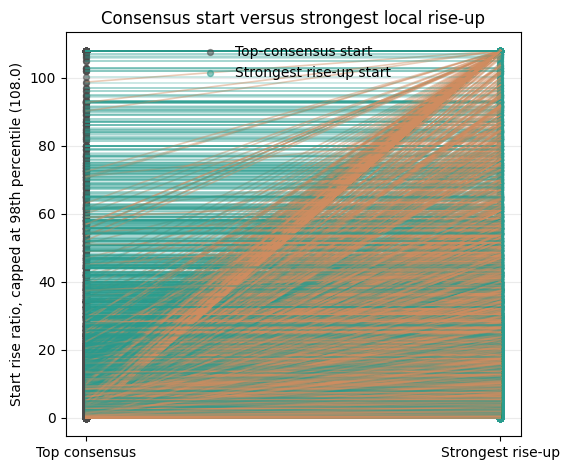

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/alt_start_consensus_vs_top_rise_paired.png


In [89]:
# Plot: paired comparison of start-rise values
# One line per shared-stop group: top-consensus start vs top-rise start.

paired_plot_df = stop_start_choice_df.copy()

# Cap only for display; table keeps raw values.
DISPLAY_CAP = paired_plot_df[
    ["consensus_start_rise_ratio", "rise_start_rise_ratio"]
].stack().quantile(0.98)

paired_plot_df["consensus_rise_display"] = paired_plot_df["consensus_start_rise_ratio"].clip(upper=DISPLAY_CAP)
paired_plot_df["top_rise_display"] = paired_plot_df["rise_start_rise_ratio"].clip(upper=DISPLAY_CAP)

fig, ax = plt.subplots(figsize=(5.8, 4.8))

x_positions = [0, 1]

for _, row in paired_plot_df.iterrows():
    color = "#2a9d8f" if row["top_consensus_is_top_rise"] else "#d08c60"
    alpha = 0.28 if row["top_consensus_is_top_rise"] else 0.45

    ax.plot(
        x_positions,
        [row["consensus_rise_display"], row["top_rise_display"]],
        color=color,
        alpha=alpha,
        linewidth=1.2,
    )

ax.scatter(
    np.zeros(len(paired_plot_df)),
    paired_plot_df["consensus_rise_display"],
    color="#4a4a4a",
    s=18,
    alpha=0.55,
    label="Top-consensus start",
)

ax.scatter(
    np.ones(len(paired_plot_df)),
    paired_plot_df["top_rise_display"],
    color="#2a9d8f",
    s=18,
    alpha=0.55,
    label="Strongest rise-up start",
)

ax.set_xticks(x_positions)
ax.set_xticklabels(["Top consensus", "Strongest rise-up"])
ax.set_ylabel(f"Start rise ratio, capped at 98th percentile ({DISPLAY_CAP:.1f})")
ax.set_title("Consensus start versus strongest local rise-up")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=False)

fig.tight_layout()

out = FIG_DIR / "alt_start_consensus_vs_top_rise_paired.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

In [95]:
evidence_df.head()

,feature_key,sample_id,bed_chrom,bed_start,bed_end,bed_strand,spliced_length_nt,extract_status,orf_signal_nt,mean_cov,...,source_tools_agreement,n_tools_full,n_tools_start,n_tools_stop,agreement_class,context_class,classes_context,start_codon_classes,terminal_codon_classes,spliced_length_nt_context
0,"chr10:100042426-100081625:-:147,119,100,140,11...",Ribo_Pancreas_pooled,chr10,100042426,100081625,-,1377,ok,1377,2.637618,...,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus,annotated_CDS,cds,ATG,stop,1377
1,chr10:100081539-100081737:-:198:0,Ribo_Pancreas_pooled,chr10,100081539,100081737,-,198,ok,198,1.045455,...,PRICE,1,1,1,tool_specific,annotated_CDS,cds,near_cognate,stop,198
2,chr10:100081788-100081815:-:27:0,Ribo_Pancreas_pooled,chr10,100081788,100081815,-,27,ok,27,5.592593,...,PRICE|ORFQuant|iRibo|RibORF2,4,4,4,full_consensus,ambiguous_mixed_class,cds|non_cds,ATG,stop,27
3,"chr10:100152130-100185626:-:222,80,90,92,59,74...",Ribo_Pancreas_pooled,chr10,100152130,100185626,-,1047,ok,1047,11.542502,...,PRICE|RiboTIE|ORFQuant|iRibo|RibORF2,5,5,5,full_consensus,annotated_CDS,cds,ATG,stop,1047
4,chr10:100185660-100185771:-:111:0,Ribo_Pancreas_pooled,chr10,100185660,100185771,-,111,ok,111,1.981982,...,PRICE|RiboTIE|iRibo|RibORF2,4,4,4,full_consensus,ambiguous_mixed_class,cds|non_cds,ATG,stop,111


Start codon classes before ATG filtering:


,start_codon_classes,n_features
0,ATG,105687
1,near_cognate,39726


Start codon classes after ATG filtering:


,start_codon_classes,n_features
0,ATG,105687


ATG-only stop_start_choice_df (14367, 34)


,stop_key,consensus_feature_key,consensus_start_key,consensus_start_coord,stop_coord,bed_chrom,bed_strand,consensus_n_tools_full,n_tools_stop,consensus_start_rise_ratio,...,rise_start_codon_classes,n_alternative_atg_starts,n_atg_candidates,max_n_tools_full,median_start_rise,max_start_rise,top_consensus_is_top_rise,choice_label,rise_over_consensus_ratio,rise_minus_consensus_coord
0,chr10:+:100373779,chr10:100373644-100373779:+:135:0,chr10:+:100373644,100373644,100373779,chr10,+,5,5,1.622222,...,ATG,2,2,5,1.298765,1.622222,True,Same ATG start,1.000000,0
1,chr10:+:100381452,chr10:100381293-100381452:+:159:0,chr10:+:100381293,100381293,100381452,chr10,+,1,1,10.250000,...,ATG,2,2,1,5.875000,10.250000,True,Same ATG start,1.000000,0
2,chr10:+:100382521,"chr10:100381293-100382521:+:155,94:0,1134",chr10:+:100381293,100381293,100382521,chr10,+,2,4,10.250000,...,ATG,2,2,2,5.696428,10.250000,True,Same ATG start,1.000000,0
3,chr10:+:100388040,"chr10:100373946-100388040:+:66,233,4:0,7269,14090",chr10:+:100373946,100373946,100388040,chr10,+,2,2,1.500000,...,ATG,2,4,2,5.875000,10.250000,False,Different ATG starts,6.833333,7347
4,chr10:+:100388068,"chr10:100381293-100388068:+:155,28:0,6747",chr10:+:100381293,100381293,100388068,chr10,+,1,1,10.250000,...,ATG,2,2,1,5.875000,10.250000,True,Same ATG start,1.000000,0
5,chr10:+:100395181,"chr10:100381293-100395181:+:155,73:0,13815",chr10:+:100381293,100381293,100395181,chr10,+,1,2,10.250000,...,ATG,2,2,1,5.875000,10.250000,True,Same ATG start,1.000000,0
6,chr10:+:100482816,chr10:100482285-100482816:+:531:0,chr10:+:100482285,100482285,100482816,chr10,+,1,4,0.333333,...,ATG,2,2,1,0.196517,0.333333,True,Same ATG start,1.000000,0
7,chr10:+:100961912,"chr10:100913125-100961912:+:125,44,731,58,998,...",chr10:+:100913125,100913125,100961912,chr10,+,1,3,0.198276,...,ATG,2,2,1,0.449138,0.700000,False,Different ATG starts,3.530435,-15
8,chr10:+:100972579,"chr10:100969567-100972579:+:24,51:0,2961",chr10:+:100969567,100969567,100972579,chr10,+,3,4,2.333333,...,ATG,2,2,3,1.729167,2.333333,True,Same ATG start,1.000000,0
9,chr10:+:100972786,chr10:100972699-100972786:+:87:0,chr10:+:100972699,100972699,100972786,chr10,+,3,4,1.029412,...,ATG,2,2,3,1.601662,2.173913,False,Different ATG starts,2.111801,24


,choice_label,n_stop_groups,fraction
0,Different ATG starts,6735,0.468783
1,Same ATG start,7632,0.531217


Saved tables_talk_foundation/shared_stop_atg_top_consensus_vs_top_rise.tsv
Saved tables_talk_foundation/shared_stop_atg_consensus_rise_match_summary.tsv


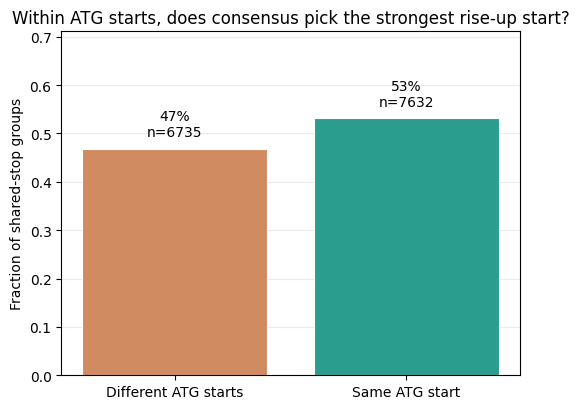

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/alt_start_atg_consensus_matches_top_rise_summary.png


In [96]:
# Clearer view: within ATG starts only, does the top-consensus start match the strongest-rise start?

ALT_START_SAMPLE = "Ribo_Pancreas_pooled"

START_CODON_CLASSES_COL = "start_codon_classes"

alt_start_df = evidence_df[
    (evidence_df["sample_id"] == ALT_START_SAMPLE)
    & (evidence_df["coverage_pass"])
    & (evidence_df["stop_key"].notna())
    & (evidence_df["start_key"].notna())
    & (evidence_df["start_rise_ratio"].notna())
].copy()

# Keep starts with finite values.
# Ratio outliers are common when upstream signal is tiny, so use capped/log display later if needed.
alt_start_df = alt_start_df[np.isfinite(alt_start_df["start_rise_ratio"])].copy()

if START_CODON_CLASSES_COL not in alt_start_df.columns:
    raise KeyError(
        f"Expected column {START_CODON_CLASSES_COL!r} in evidence_df. "
        "Available codon-ish columns are: "
        f"{[c for c in evidence_df.columns if 'codon' in c.lower()]}"
    )

print("Start codon classes before ATG filtering:")
display(
    alt_start_df[START_CODON_CLASSES_COL]
    .value_counts(dropna=False)
    .reset_index(name="n_features")
    .rename(columns={START_CODON_CLASSES_COL: "start_codon_classes"})
)

alt_start_df[START_CODON_CLASSES_COL] = (
    alt_start_df[START_CODON_CLASSES_COL]
    .astype(str)
    .str.strip()
)

# Keep only features whose merged start-codon class is unambiguously ATG.
# This deliberately excludes mixed values like 'ATG|near_cognate' if they exist.
alt_start_df = alt_start_df[
    alt_start_df[START_CODON_CLASSES_COL].eq("ATG")
].copy()

print("Start codon classes after ATG filtering:")
display(
    alt_start_df[START_CODON_CLASSES_COL]
    .value_counts(dropna=False)
    .reset_index(name="n_features")
    .rename(columns={START_CODON_CLASSES_COL: "start_codon_classes"})
)

# Crucial: define multi-start stop groups only after restricting to ATG starts.
# This makes the denominator:
# shared-stop groups with at least two distinct ATG starts.
multi_atg_start_stop_keys = (
    alt_start_df
    .groupby("stop_key")["start_key"]
    .nunique()
    .loc[lambda s: s >= 2]
    .index
)

alt_start_df = alt_start_df[
    alt_start_df["stop_key"].isin(multi_atg_start_stop_keys)
].copy()

alt_start_df["start_coord"] = np.where(
    alt_start_df["bed_strand"] == "+",
    alt_start_df["bed_start"],
    alt_start_df["bed_end"],
)

alt_start_df["stop_coord"] = np.where(
    alt_start_df["bed_strand"] == "+",
    alt_start_df["bed_end"],
    alt_start_df["bed_start"],
)

# Pick one top-consensus ATG candidate and one top-rise ATG candidate per stop.
# Tie-breakers keep the result deterministic.
ranked_by_consensus = alt_start_df.sort_values(
    ["stop_key", "n_tools_full", "periodicity", "body_total_signal", "start_rise_ratio"],
    ascending=[True, False, False, False, False],
)

ranked_by_rise = alt_start_df.sort_values(
    ["stop_key", "start_rise_ratio", "periodicity", "body_total_signal", "n_tools_full"],
    ascending=[True, False, False, False, False],
)

top_consensus = (
    ranked_by_consensus
    .groupby("stop_key", as_index=False)
    .head(1)
    [[
        "stop_key",
        "feature_key",
        "start_key",
        "start_coord",
        "stop_coord",
        "bed_chrom",
        "bed_strand",
        "n_tools_full",
        "n_tools_stop",
        "start_rise_ratio",
        "periodicity",
        "body_total_signal",
        "context_class",
        "source_tools",
        START_CODON_CLASSES_COL,
    ]]
    .rename(columns={
        "feature_key": "consensus_feature_key",
        "start_key": "consensus_start_key",
        "start_coord": "consensus_start_coord",
        "n_tools_full": "consensus_n_tools_full",
        "start_rise_ratio": "consensus_start_rise_ratio",
        "periodicity": "consensus_periodicity",
        "body_total_signal": "consensus_body_total_signal",
        "context_class": "consensus_context_class",
        "source_tools": "consensus_source_tools",
        START_CODON_CLASSES_COL: "consensus_start_codon_classes",
    })
)

top_rise = (
    ranked_by_rise
    .groupby("stop_key", as_index=False)
    .head(1)
    [[
        "stop_key",
        "feature_key",
        "start_key",
        "start_coord",
        "n_tools_full",
        "start_rise_ratio",
        "periodicity",
        "body_total_signal",
        "context_class",
        "source_tools",
        START_CODON_CLASSES_COL,
    ]]
    .rename(columns={
        "feature_key": "rise_feature_key",
        "start_key": "rise_start_key",
        "start_coord": "rise_start_coord",
        "n_tools_full": "rise_n_tools_full",
        "start_rise_ratio": "rise_start_rise_ratio",
        "periodicity": "rise_periodicity",
        "body_total_signal": "rise_body_total_signal",
        "context_class": "rise_context_class",
        "source_tools": "rise_source_tools",
        START_CODON_CLASSES_COL: "rise_start_codon_classes",
    })
)

stop_start_choice_df = top_consensus.merge(top_rise, on="stop_key", how="inner")

extra_stop_stats = (
    alt_start_df
    .groupby("stop_key", as_index=False)
    .agg(
        n_alternative_atg_starts=("start_key", "nunique"),
        n_atg_candidates=("feature_key", "nunique"),
        max_n_tools_full=("n_tools_full", "max"),
        median_start_rise=("start_rise_ratio", "median"),
        max_start_rise=("start_rise_ratio", "max"),
    )
)

stop_start_choice_df = stop_start_choice_df.merge(extra_stop_stats, on="stop_key", how="left")

stop_start_choice_df["top_consensus_is_top_rise"] = (
    stop_start_choice_df["consensus_start_key"] == stop_start_choice_df["rise_start_key"]
)

stop_start_choice_df["choice_label"] = np.where(
    stop_start_choice_df["top_consensus_is_top_rise"],
    "Same ATG start",
    "Different ATG starts",
)

# Helpful diagnostics for mismatch cases.
stop_start_choice_df["rise_over_consensus_ratio"] = (
    stop_start_choice_df["rise_start_rise_ratio"]
    / stop_start_choice_df["consensus_start_rise_ratio"]
)

stop_start_choice_df["rise_minus_consensus_coord"] = (
    stop_start_choice_df["rise_start_coord"]
    - stop_start_choice_df["consensus_start_coord"]
)

match_summary = (
    stop_start_choice_df
    .groupby("choice_label", as_index=False)
    .size()
    .rename(columns={"size": "n_stop_groups"})
)

if len(match_summary):
    match_summary["fraction"] = (
        match_summary["n_stop_groups"] / match_summary["n_stop_groups"].sum()
    )
else:
    match_summary["fraction"] = pd.Series(dtype=float)

print("ATG-only stop_start_choice_df", stop_start_choice_df.shape)
display(stop_start_choice_df.head(20))

display(match_summary)

save_table(stop_start_choice_df, "shared_stop_atg_top_consensus_vs_top_rise")
save_table(match_summary, "shared_stop_atg_consensus_rise_match_summary")


# Plot: simple ATG-only match/mismatch summary
plot_match = match_summary.copy()

if plot_match.empty:
    print(
        "No shared-stop groups with at least two ATG starts after filtering; "
        "skipping plot."
    )
else:
    fig, ax = plt.subplots(figsize=(5.4, 4.2))

    colors = {
        "Same ATG start": "#2a9d8f",
        "Different ATG starts": "#d08c60",
    }

    ax.bar(
        plot_match["choice_label"],
        plot_match["fraction"],
        color=[colors.get(x, "#999999") for x in plot_match["choice_label"]],
        edgecolor="white",
        linewidth=0.8,
    )

    for i, row in plot_match.iterrows():
        ax.text(
            i,
            row["fraction"] + 0.02,
            f"{row['fraction']:.0%}\nn={int(row['n_stop_groups'])}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    ax.set_ylim(0, min(1.0, plot_match["fraction"].max() + 0.18))
    ax.set_ylabel("Fraction of shared-stop groups")
    ax.set_title("Within ATG starts, does consensus pick the strongest rise-up start?")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    fig.tight_layout()

    out = FIG_DIR / "alt_start_atg_consensus_matches_top_rise_summary.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()

    print(out)

,rise_vs_consensus_position,n_stop_groups,fraction
0,Same ATG start,7632,0.531217
1,Rise start is upstream / longer ORF,1695,0.117979
2,Rise start is downstream / shorter ORF,5040,0.350804


Saved tables_talk_foundation/shared_stop_atg_consensus_rise_position_summary.tsv


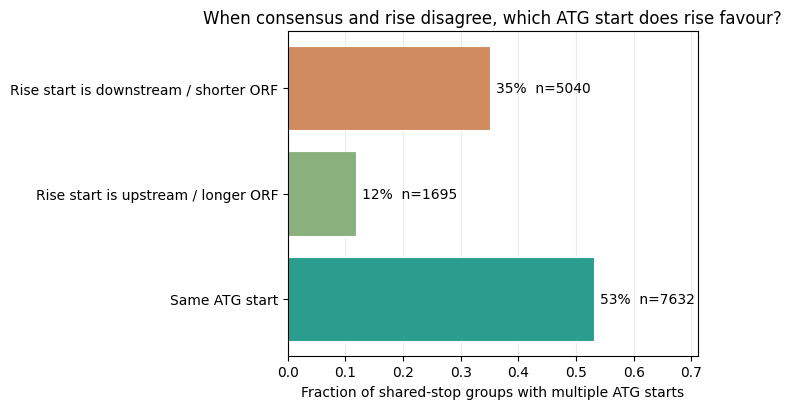

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/alt_start_atg_consensus_vs_rise_direction_summary.png


In [97]:
# Clearer plot: when consensus and strongest-rise disagree, where does the rise-preferred start sit?

plot_df = stop_start_choice_df.copy()

if plot_df.empty:
    print("No ATG shared-stop groups to plot.")
else:
    # Use distance to stop rather than raw coordinate difference.
    # This avoids strand confusion.
    plot_df["consensus_start_to_stop_nt"] = (
        plot_df["stop_coord"] - plot_df["consensus_start_coord"]
    ).abs()

    plot_df["rise_start_to_stop_nt"] = (
        plot_df["stop_coord"] - plot_df["rise_start_coord"]
    ).abs()

    plot_df["rise_vs_consensus_position"] = np.select(
        [
            plot_df["top_consensus_is_top_rise"],
            plot_df["rise_start_to_stop_nt"] > plot_df["consensus_start_to_stop_nt"],
            plot_df["rise_start_to_stop_nt"] < plot_df["consensus_start_to_stop_nt"],
        ],
        [
            "Same ATG start",
            "Rise start is upstream / longer ORF",
            "Rise start is downstream / shorter ORF",
        ],
        default="Different ATG start, same distance"
    )

    position_summary = (
        plot_df
        .groupby("rise_vs_consensus_position", as_index=False)
        .size()
        .rename(columns={"size": "n_stop_groups"})
    )

    position_summary["fraction"] = (
        position_summary["n_stop_groups"] / position_summary["n_stop_groups"].sum()
    )

    order = [
        "Same ATG start",
        "Rise start is upstream / longer ORF",
        "Rise start is downstream / shorter ORF",
        "Different ATG start, same distance",
    ]

    position_summary["rise_vs_consensus_position"] = pd.Categorical(
        position_summary["rise_vs_consensus_position"],
        categories=order,
        ordered=True,
    )

    position_summary = (
        position_summary
        .sort_values("rise_vs_consensus_position")
        .reset_index(drop=True)
    )

    display(position_summary)

    save_table(position_summary, "shared_stop_atg_consensus_rise_position_summary")

    fig, ax = plt.subplots(figsize=(7.2, 4.2))

    colors = {
        "Same ATG start": "#2a9d8f",
        "Rise start is upstream / longer ORF": "#8ab17d",
        "Rise start is downstream / shorter ORF": "#d08c60",
        "Different ATG start, same distance": "#999999",
    }

    ax.barh(
        position_summary["rise_vs_consensus_position"].astype(str),
        position_summary["fraction"],
        color=[
            colors.get(x, "#999999")
            for x in position_summary["rise_vs_consensus_position"].astype(str)
        ],
        edgecolor="white",
        linewidth=0.8,
    )

    for i, row in position_summary.iterrows():
        ax.text(
            row["fraction"] + 0.01,
            i,
            f"{row['fraction']:.0%}  n={int(row['n_stop_groups'])}",
            va="center",
            ha="left",
            fontsize=10,
        )

    ax.set_xlim(0, min(1.0, position_summary["fraction"].max() + 0.18))
    ax.set_xlabel("Fraction of shared-stop groups with multiple ATG starts")
    ax.set_ylabel("")
    ax.set_title("When consensus and rise disagree, which ATG start does rise favour?")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

    fig.tight_layout()

    out = FIG_DIR / "alt_start_atg_consensus_vs_rise_direction_summary.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()

    print(out)

,rise_support_class,n_stop_groups,fraction
0,Ribo-seq supports consensus start,7563,0.542462
1,Ribo-seq supports alternative start,5227,0.374910
2,No clear rise-based preference,1152,0.082628


Saved tables_talk_foundation/shared_stop_atg_rise_support_summary_margin_1p5.tsv


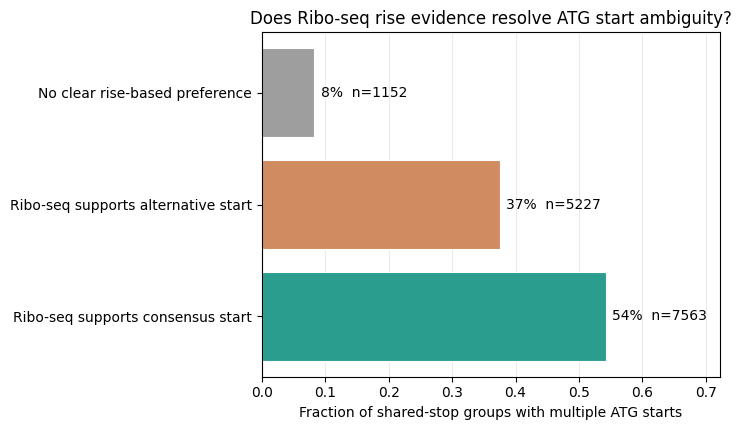

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/alt_start_atg_rise_supports_consensus_or_alternative.png


In [98]:
# Clearer interpretation:
# In shared-stop groups with multiple ATG starts, does local Ribo-seq rise evidence
# support the consensus start, an alternative start, or neither clearly?

RISE_MARGIN = 1.5

plot_df = stop_start_choice_df.copy()

if plot_df.empty:
    print("No ATG shared-stop groups to classify.")
else:
    # Avoid divide-by-zero / infinite weirdness.
    plot_df = plot_df[
        np.isfinite(plot_df["consensus_start_rise_ratio"])
        & np.isfinite(plot_df["rise_start_rise_ratio"])
        & plot_df["consensus_start_rise_ratio"].gt(0)
        & plot_df["rise_start_rise_ratio"].gt(0)
    ].copy()

    plot_df["rise_over_consensus_ratio"] = (
        plot_df["rise_start_rise_ratio"] / plot_df["consensus_start_rise_ratio"]
    )

    plot_df["rise_support_class"] = np.select(
        [
            plot_df["top_consensus_is_top_rise"],
            plot_df["rise_over_consensus_ratio"].ge(RISE_MARGIN),
        ],
        [
            "Ribo-seq supports consensus start",
            "Ribo-seq supports alternative start",
        ],
        default="No clear rise-based preference",
    )

    support_summary = (
        plot_df
        .groupby("rise_support_class", as_index=False)
        .size()
        .rename(columns={"size": "n_stop_groups"})
    )

    support_summary["fraction"] = (
        support_summary["n_stop_groups"] / support_summary["n_stop_groups"].sum()
    )

    order = [
        "Ribo-seq supports consensus start",
        "Ribo-seq supports alternative start",
        "No clear rise-based preference",
    ]

    support_summary["rise_support_class"] = pd.Categorical(
        support_summary["rise_support_class"],
        categories=order,
        ordered=True,
    )

    support_summary = (
        support_summary
        .sort_values("rise_support_class")
        .reset_index(drop=True)
    )

    display(support_summary)

    save_table(
        support_summary,
        f"shared_stop_atg_rise_support_summary_margin_{str(RISE_MARGIN).replace('.', 'p')}"
    )

    fig, ax = plt.subplots(figsize=(7.4, 4.4))

    colors = {
        "Ribo-seq supports consensus start": "#2a9d8f",
        "Ribo-seq supports alternative start": "#d08c60",
        "No clear rise-based preference": "#9e9e9e",
    }

    ax.barh(
        support_summary["rise_support_class"].astype(str),
        support_summary["fraction"],
        color=[
            colors.get(x, "#999999")
            for x in support_summary["rise_support_class"].astype(str)
        ],
        edgecolor="white",
        linewidth=0.8,
    )

    for i, row in support_summary.iterrows():
        ax.text(
            row["fraction"] + 0.01,
            i,
            f"{row['fraction']:.0%}  n={int(row['n_stop_groups'])}",
            va="center",
            ha="left",
            fontsize=10,
        )

    ax.set_xlim(0, min(1.0, support_summary["fraction"].max() + 0.18))
    ax.set_xlabel("Fraction of shared-stop groups with multiple ATG starts")
    ax.set_ylabel("")
    ax.set_title("Does Ribo-seq rise evidence resolve ATG start ambiguity?")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

    fig.tight_layout()

    out = FIG_DIR / "alt_start_atg_rise_supports_consensus_or_alternative.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()

    print(out)

Start codon classes in base candidate set:


,start_codon_classes,n_features
0,ATG,102037
1,near_cognate,38780


rise_choice_df (38990, 37)


,stop_key,consensus_feature_key,consensus_start_key,consensus_start_coord,stop_coord,bed_chrom,bed_strand,consensus_n_tools_full,n_tools_stop,consensus_start_rise_ratio,...,max_n_tools_full,median_start_rise,max_start_rise,start_set,top_consensus_is_top_rise,rise_over_consensus_ratio,consensus_start_to_stop_nt,rise_start_to_stop_nt,rise_start_position_vs_consensus,rise_support_class
0,chr10:+:100373779,chr10:100373644-100373779:+:135:0,chr10:+:100373644,100373644,100373779,chr10,+,5,5,1.622222,...,5,0.975309,1.622222,all starts,True,1.000000,135,135,same,Rise supports consensus start
1,chr10:+:100381452,chr10:100381293-100381452:+:159:0,chr10:+:100381293,100381293,100381452,chr10,+,1,1,10.250000,...,1,5.875000,10.250000,all starts,True,1.000000,159,159,same,Rise supports consensus start
2,chr10:+:100382521,"chr10:100381293-100382521:+:155,94:0,1134",chr10:+:100381293,100381293,100382521,chr10,+,2,4,10.250000,...,2,5.696428,10.250000,all starts,True,1.000000,1228,1228,same,Rise supports consensus start
3,chr10:+:100388040,"chr10:100373946-100388040:+:66,233,4:0,7269,14090",chr10:+:100373946,100373946,100388040,chr10,+,2,2,1.500000,...,2,5.875000,10.250000,all starts,False,6.833333,14094,6747,downstream_shorter,Rise supports alternative start
4,chr10:+:100388068,"chr10:100381293-100388068:+:155,28:0,6747",chr10:+:100381293,100381293,100388068,chr10,+,1,1,10.250000,...,1,5.875000,10.250000,all starts,True,1.000000,6775,6775,same,Rise supports consensus start
5,chr10:+:100395181,"chr10:100381293-100395181:+:155,73:0,13815",chr10:+:100381293,100381293,100395181,chr10,+,1,2,10.250000,...,1,1.500000,10.250000,all starts,True,1.000000,13888,13888,same,Rise supports consensus start
6,chr10:+:100482816,chr10:100482276-100482816:+:540:0,chr10:+:100482276,100482276,100482816,chr10,+,1,4,0.500000,...,1,0.333333,0.500000,all starts,True,1.000000,540,540,same,Rise supports consensus start
7,chr10:+:100913136,chr10:100912983-100913136:+:153:0,chr10:+:100912983,100912983,100913136,chr10,+,4,4,2.356322,...,4,1.343378,2.356322,all starts,True,1.000000,153,153,same,Rise supports consensus start
8,chr10:+:100961912,"chr10:100913125-100961912:+:125,44,731,58,998,...",chr10:+:100913125,100913125,100961912,chr10,+,1,3,0.198276,...,1,0.409524,0.700000,all starts,False,3.530435,48787,48802,upstream_longer,Rise supports alternative start
9,chr10:+:100972579,"chr10:100969567-100972579:+:24,51:0,2961",chr10:+:100969567,100969567,100972579,chr10,+,3,4,2.333333,...,3,1.342593,2.333333,all starts,True,1.000000,3012,3012,same,Rise supports consensus start


,start_set,rise_support_class,n_stop_groups,fraction
0,all starts,Rise supports consensus start,11605,0.458370
1,all starts,Rise supports alternative start,11540,0.455802
2,all starts,No clear rise preference,2173,0.085828
3,ATG starts only,Rise supports consensus start,7233,0.529037
4,ATG starts only,Rise supports alternative start,5276,0.385898
5,ATG starts only,No clear rise preference,1163,0.085064


Saved tables_talk_foundation/shared_stop_rise_support_choice_all_vs_atg_margin_1p5.tsv
Saved tables_talk_foundation/shared_stop_rise_support_summary_all_vs_atg_margin_1p5.tsv


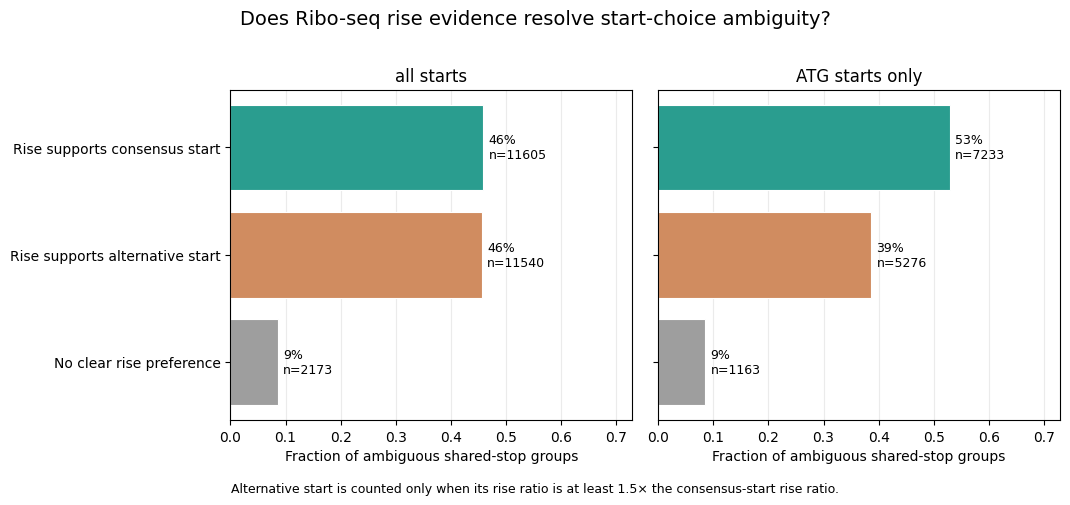

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/alt_start_rise_support_all_vs_atg.png


In [99]:
# Matched view after the start-ambiguity slide:
# For shared-stop groups with multiple candidate starts, does Ribo-seq rise evidence
# support the consensus start, an alternative start, or neither clearly?
#
# Two panels:
#   1. all starts
#   2. ATG starts only

ALT_START_SAMPLE = "Ribo_Pancreas_pooled"
START_CODON_CLASSES_COL = "start_codon_classes"
RISE_MARGIN = 1.5

base_alt_start_df = evidence_df[
    (evidence_df["sample_id"] == ALT_START_SAMPLE)
    & (evidence_df["coverage_pass"])
    & (evidence_df["stop_key"].notna())
    & (evidence_df["start_key"].notna())
    & (evidence_df["start_rise_ratio"].notna())
].copy()

base_alt_start_df = base_alt_start_df[
    np.isfinite(base_alt_start_df["start_rise_ratio"])
    & base_alt_start_df["start_rise_ratio"].gt(0)
].copy()

if START_CODON_CLASSES_COL not in base_alt_start_df.columns:
    raise KeyError(
        f"Expected column {START_CODON_CLASSES_COL!r} in evidence_df. "
        "Available codon-ish columns are: "
        f"{[c for c in evidence_df.columns if 'codon' in c.lower()]}"
    )

base_alt_start_df[START_CODON_CLASSES_COL] = (
    base_alt_start_df[START_CODON_CLASSES_COL]
    .astype(str)
    .str.strip()
)

print("Start codon classes in base candidate set:")
display(
    base_alt_start_df[START_CODON_CLASSES_COL]
    .value_counts(dropna=False)
    .reset_index(name="n_features")
    .rename(columns={START_CODON_CLASSES_COL: "start_codon_classes"})
)


def classify_rise_support(input_df, label, atg_only=False, rise_margin=1.5):
    """
    For each stop group with >=2 starts, compare:
      - top consensus start: highest n_tools_full, then periodicity/body signal/start rise
      - top rise start: highest start_rise_ratio, then periodicity/body signal/tool support

    Classify whether rise evidence supports the consensus start, an alternative start,
    or gives no clear preference.
    """
    df = input_df.copy()

    if atg_only:
        # Strict ATG-only filter. This deliberately excludes mixed values such as ATG|near_cognate.
        df = df[df[START_CODON_CLASSES_COL].eq("ATG")].copy()

    # Define ambiguous start groups after any codon-class filtering.
    multi_start_stop_keys = (
        df
        .groupby("stop_key")["start_key"]
        .nunique()
        .loc[lambda s: s >= 2]
        .index
    )

    df = df[df["stop_key"].isin(multi_start_stop_keys)].copy()

    if df.empty:
        return (
            pd.DataFrame(),
            pd.DataFrame(columns=[
                "start_set",
                "rise_support_class",
                "n_stop_groups",
                "fraction",
            ])
        )

    df["start_coord"] = np.where(
        df["bed_strand"] == "+",
        df["bed_start"],
        df["bed_end"],
    )

    df["stop_coord"] = np.where(
        df["bed_strand"] == "+",
        df["bed_end"],
        df["bed_start"],
    )

    ranked_by_consensus = df.sort_values(
        ["stop_key", "n_tools_full", "periodicity", "body_total_signal", "start_rise_ratio"],
        ascending=[True, False, False, False, False],
    )

    ranked_by_rise = df.sort_values(
        ["stop_key", "start_rise_ratio", "periodicity", "body_total_signal", "n_tools_full"],
        ascending=[True, False, False, False, False],
    )

    top_consensus = (
        ranked_by_consensus
        .groupby("stop_key", as_index=False)
        .head(1)
        [[
            "stop_key",
            "feature_key",
            "start_key",
            "start_coord",
            "stop_coord",
            "bed_chrom",
            "bed_strand",
            "n_tools_full",
            "n_tools_stop",
            "start_rise_ratio",
            "periodicity",
            "body_total_signal",
            "context_class",
            "source_tools",
            START_CODON_CLASSES_COL,
        ]]
        .rename(columns={
            "feature_key": "consensus_feature_key",
            "start_key": "consensus_start_key",
            "start_coord": "consensus_start_coord",
            "n_tools_full": "consensus_n_tools_full",
            "start_rise_ratio": "consensus_start_rise_ratio",
            "periodicity": "consensus_periodicity",
            "body_total_signal": "consensus_body_total_signal",
            "context_class": "consensus_context_class",
            "source_tools": "consensus_source_tools",
            START_CODON_CLASSES_COL: "consensus_start_codon_classes",
        })
    )

    top_rise = (
        ranked_by_rise
        .groupby("stop_key", as_index=False)
        .head(1)
        [[
            "stop_key",
            "feature_key",
            "start_key",
            "start_coord",
            "n_tools_full",
            "start_rise_ratio",
            "periodicity",
            "body_total_signal",
            "context_class",
            "source_tools",
            START_CODON_CLASSES_COL,
        ]]
        .rename(columns={
            "feature_key": "rise_feature_key",
            "start_key": "rise_start_key",
            "start_coord": "rise_start_coord",
            "n_tools_full": "rise_n_tools_full",
            "start_rise_ratio": "rise_start_rise_ratio",
            "periodicity": "rise_periodicity",
            "body_total_signal": "rise_body_total_signal",
            "context_class": "rise_context_class",
            "source_tools": "rise_source_tools",
            START_CODON_CLASSES_COL: "rise_start_codon_classes",
        })
    )

    choice_df = top_consensus.merge(top_rise, on="stop_key", how="inner")

    extra_stop_stats = (
        df
        .groupby("stop_key", as_index=False)
        .agg(
            n_alternative_starts=("start_key", "nunique"),
            n_candidates=("feature_key", "nunique"),
            max_n_tools_full=("n_tools_full", "max"),
            median_start_rise=("start_rise_ratio", "median"),
            max_start_rise=("start_rise_ratio", "max"),
        )
    )

    choice_df = choice_df.merge(extra_stop_stats, on="stop_key", how="left")

    choice_df["start_set"] = label

    choice_df["top_consensus_is_top_rise"] = (
        choice_df["consensus_start_key"] == choice_df["rise_start_key"]
    )

    choice_df["rise_over_consensus_ratio"] = (
        choice_df["rise_start_rise_ratio"] / choice_df["consensus_start_rise_ratio"]
    )

    choice_df["consensus_start_to_stop_nt"] = (
        choice_df["stop_coord"] - choice_df["consensus_start_coord"]
    ).abs()

    choice_df["rise_start_to_stop_nt"] = (
        choice_df["stop_coord"] - choice_df["rise_start_coord"]
    ).abs()

    choice_df["rise_start_position_vs_consensus"] = np.select(
        [
            choice_df["top_consensus_is_top_rise"],
            choice_df["rise_start_to_stop_nt"] > choice_df["consensus_start_to_stop_nt"],
            choice_df["rise_start_to_stop_nt"] < choice_df["consensus_start_to_stop_nt"],
        ],
        [
            "same",
            "upstream_longer",
            "downstream_shorter",
        ],
        default="different_same_distance",
    )

    choice_df["rise_support_class"] = np.select(
        [
            choice_df["top_consensus_is_top_rise"],
            choice_df["rise_over_consensus_ratio"].ge(rise_margin),
        ],
        [
            "Rise supports consensus start",
            "Rise supports alternative start",
        ],
        default="No clear rise preference",
    )

    summary = (
        choice_df
        .groupby(["start_set", "rise_support_class"], as_index=False)
        .size()
        .rename(columns={"size": "n_stop_groups"})
    )

    summary["fraction"] = (
        summary["n_stop_groups"] / summary.groupby("start_set")["n_stop_groups"].transform("sum")
    )

    return choice_df, summary


all_choice_df, all_support_summary = classify_rise_support(
    base_alt_start_df,
    label="all starts",
    atg_only=False,
    rise_margin=RISE_MARGIN,
)

atg_choice_df, atg_support_summary = classify_rise_support(
    base_alt_start_df,
    label="ATG starts only",
    atg_only=True,
    rise_margin=RISE_MARGIN,
)

rise_choice_df = pd.concat([all_choice_df, atg_choice_df], ignore_index=True)
rise_support_summary = pd.concat([all_support_summary, atg_support_summary], ignore_index=True)

support_order = [
    "Rise supports consensus start",
    "Rise supports alternative start",
    "No clear rise preference",
]

start_set_order = [
    "all starts",
    "ATG starts only",
]

rise_support_summary["rise_support_class"] = pd.Categorical(
    rise_support_summary["rise_support_class"],
    categories=support_order,
    ordered=True,
)

rise_support_summary["start_set"] = pd.Categorical(
    rise_support_summary["start_set"],
    categories=start_set_order,
    ordered=True,
)

rise_support_summary = (
    rise_support_summary
    .sort_values(["start_set", "rise_support_class"])
    .reset_index(drop=True)
)

print("rise_choice_df", rise_choice_df.shape)
display(rise_choice_df.head(20))

display(rise_support_summary)

save_table(
    rise_choice_df,
    f"shared_stop_rise_support_choice_all_vs_atg_margin_{str(RISE_MARGIN).replace('.', 'p')}"
)

save_table(
    rise_support_summary,
    f"shared_stop_rise_support_summary_all_vs_atg_margin_{str(RISE_MARGIN).replace('.', 'p')}"
)


# Plot matched two-panel summary.
if rise_support_summary.empty:
    print("No shared-stop groups with multiple starts after filtering; skipping plot.")
else:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.8, 4.6),
        sharey=True,
        sharex=True,
    )

    colors = {
        "Rise supports consensus start": "#2a9d8f",
        "Rise supports alternative start": "#d08c60",
        "No clear rise preference": "#9e9e9e",
    }

    for ax, start_set in zip(axes, start_set_order):
        panel = rise_support_summary[
            rise_support_summary["start_set"].astype(str).eq(start_set)
        ].copy()

        # Ensure all classes are present and ordered, even if count is zero.
        panel = (
            pd.DataFrame({"rise_support_class": support_order})
            .merge(panel, on="rise_support_class", how="left")
        )

        panel["start_set"] = start_set
        panel["n_stop_groups"] = panel["n_stop_groups"].fillna(0).astype(int)

        total = panel["n_stop_groups"].sum()
        if total > 0:
            panel["fraction"] = panel["n_stop_groups"] / total
        else:
            panel["fraction"] = 0.0

        ax.barh(
            panel["rise_support_class"],
            panel["fraction"],
            color=[colors.get(x, "#999999") for x in panel["rise_support_class"]],
            edgecolor="white",
            linewidth=0.8,
        )

        for i, row in panel.iterrows():
            if row["n_stop_groups"] == 0:
                continue

            ax.text(
                row["fraction"] + 0.01,
                i,
                f"{row['fraction']:.0%}\nn={int(row['n_stop_groups'])}",
                va="center",
                ha="left",
                fontsize=9,
            )

        ax.set_title(start_set)
        ax.set_xlabel("Fraction of ambiguous shared-stop groups")
        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("")
    axes[0].invert_yaxis()

    max_fraction = rise_support_summary["fraction"].max()
    for ax in axes:
        ax.set_xlim(0, min(1.0, max_fraction + 0.20))

    fig.suptitle(
        "Does Ribo-seq rise evidence resolve start-choice ambiguity?",
        y=1.02,
        fontsize=14,
    )

    fig.text(
        0.5,
        -0.03,
        f"Alternative start is counted only when its rise ratio is at least {RISE_MARGIN}× the consensus-start rise ratio.",
        ha="center",
        fontsize=9,
    )

    fig.tight_layout()

    out = FIG_DIR / "alt_start_rise_support_all_vs_atg.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()

    print(out)

Saved tables_talk_foundation/09_consensus_x_evidence.tsv


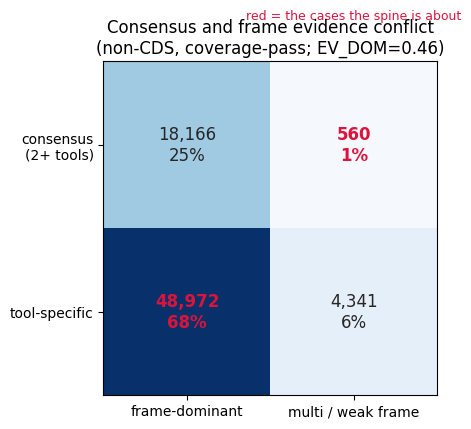

Saved figures_talk_foundation/09_consensus_x_evidence.png


In [104]:
# === Cell 09: Consensus x evidence conflict (non-CDS) ===
# Takeaway: consensus only earns trust where frame evidence agrees.
if not SCORES_ARE_REGISTERED or evidence_df.empty:
    print('Skipping consensus-x-evidence: scores not registered or evidence_df empty.')
else:
    ev = evidence_df[evidence_df['coverage_pass'].astype(bool)].copy()
    cds = ev[ev['context_class'].eq('annotated_CDS')]
    EV_DOM = cds['periodicity'].quantile(0.10) if len(cds) else 0.5   # "as in-frame as the bottom decile of real CDS"

    nc = ev[~ev['context_class'].eq('annotated_CDS')].copy()
    nc['consensus'] = np.where(nc['n_tools_full'].ge(2), 'consensus\n(2+ tools)', 'tool-specific')
    nc['evidence']  = np.where(nc['periodicity'].ge(EV_DOM), 'frame-dominant', 'multi / weak frame')
    ct = pd.crosstab(nc['consensus'], nc['evidence']).reindex(
        index=['consensus\n(2+ tools)', 'tool-specific'],
        columns=['frame-dominant', 'multi / weak frame'], fill_value=0)
    save_table(ct.reset_index(), '09_consensus_x_evidence')

    frac = ct.div(ct.values.sum())
    fig, ax = plt.subplots(figsize=(6.4, 4.4))
    ax.imshow(frac.values, cmap='Blues', vmin=0, vmax=frac.values.max())
    for i in range(2):
        for j in range(2):
            n = ct.values[i, j]
            conflict = (i == 0 and j == 1) or (i == 1 and j == 0)
            ax.text(j, i, f'{n:,}\n{frac.values[i,j]:.0%}', ha='center', va='center',
                    fontsize=12, color='crimson' if conflict else '0.15',
                    fontweight='bold' if conflict else 'normal')
    ax.set_xticks([0, 1]); ax.set_xticklabels(frac.columns)
    ax.set_yticks([0, 1]); ax.set_yticklabels(frac.index)
    ax.set_title(f'Consensus and frame evidence conflict\n(non-CDS, coverage-pass; EV_DOM={EV_DOM:.2f})')
    ax.text(1, -0.75, 'red = the cases the spine is about', color='crimson', fontsize=9, ha='center')
    finish_plot(fig, '09_consensus_x_evidence.png')

Saved tables_talk_foundation/10_multiframe_by_agreement.tsv


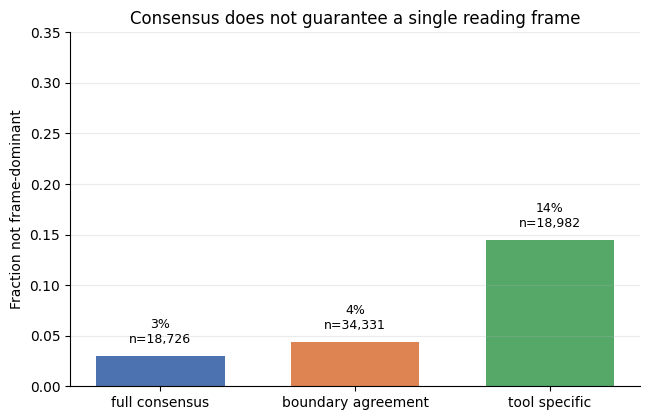

Saved figures_talk_foundation/10_multiframe_by_agreement.png


In [101]:
# === Cell 10: Multi-frame is not filtered out by consensus ===
if not SCORES_ARE_REGISTERED or evidence_df.empty:
    print('Skipping multi-frame: scores not registered or evidence_df empty.')
else:
    ev = evidence_df[evidence_df['coverage_pass'].astype(bool)].copy()
    cds = ev[ev['context_class'].eq('annotated_CDS')]
    EV_DOM = cds['periodicity'].quantile(0.10) if len(cds) else 0.5

    has_frames = {'frame1_frac', 'frame2_frac'}.issubset(ev.columns)
    if has_frames:
        ev['flag'] = ev[['frame1_frac', 'frame2_frac']].max(axis=1).ge(0.25)
        ylab, title = 'Fraction with strong 2nd-frame signal (≥25%)', 'Consensus does not prevent overlapping-frame signal'
    else:
        ev['flag'] = ev['periodicity'].lt(EV_DOM)
        ylab, title = 'Fraction not frame-dominant', 'Consensus does not guarantee a single reading frame'

    nc = ev[~ev['context_class'].eq('annotated_CDS')]
    groups = [g for g in AGREEMENT_ORDER if g in set(nc['agreement_class'])]
    summ = nc.groupby('agreement_class').agg(frac=('flag', 'mean'), n=('feature_key', 'nunique')).reindex(groups)
    save_table(summ.reset_index(), '10_multiframe_by_agreement')

    fig, ax = plt.subplots(figsize=(6.6, 4.3))
    bars = ax.bar(range(len(groups)), summ['frac'].values,
                  color=[AGREEMENT_COLORS.get(g, '0.5') for g in groups], width=0.66)
    for b, (_, r) in zip(bars, summ.iterrows()):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{r.frac:.0%}\nn={int(r.n):,}',
                ha='center', va='bottom', fontsize=9)
    ax.set_xticks(range(len(groups))); ax.set_xticklabels([g.replace('_', ' ') for g in groups])
    ax.set_ylim(0, max(0.35, summ['frac'].max() * 1.3)); ax.set_ylabel(ylab); ax.set_title(title)
    ax.grid(axis='y', alpha=0.25); ax.spines[['top', 'right']].set_visible(False)
    finish_plot(fig, '10_multiframe_by_agreement.png')

Saved tables_talk_foundation/11_start_arbitration.tsv


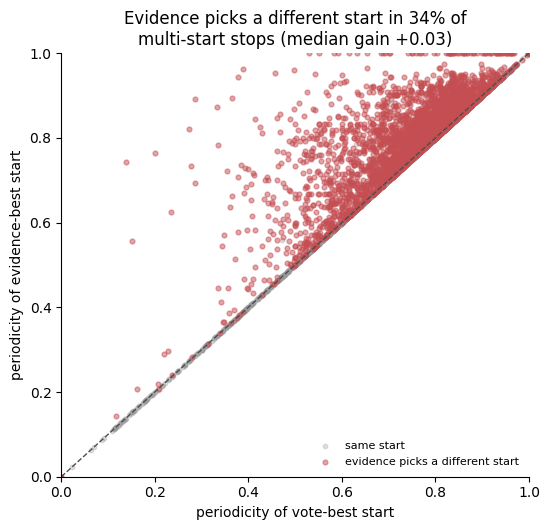

Saved figures_talk_foundation/11_start_arbitration.png


In [102]:
# === Cell 11: Vote-best start vs evidence-best start ===
if not SCORES_ARE_REGISTERED or evidence_df.empty:
    print('Skipping start-arbitration: scores not registered or evidence_df empty.')
else:
    ev = evidence_df[evidence_df['coverage_pass'].astype(bool)].copy()
    ev = ev[~ev['context_class'].eq('annotated_CDS')]                       # arbitration matters for non-CDS
    n_starts = ev.groupby('stop_key')['start_key'].transform('nunique')
    multi = ev[n_starts.ge(2)].copy()

    def pick(grp):
        ms = grp.sort_values(['n_tools_start', 'n_tools_full', 'periodicity'], ascending=False).iloc[0]
        be = grp.sort_values('periodicity', ascending=False).iloc[0]
        return pd.Series({'p_votes': ms['periodicity'], 'p_evidence': be['periodicity'],
                          'same': ms['start_key'] == be['start_key']})
    res = multi.groupby('stop_key', sort=False).apply(pick).reset_index()   # may take a few seconds
    save_table(res, '11_start_arbitration')
    frac_diff = 1 - res['same'].mean()
    gain = (res.loc[~res['same'], 'p_evidence'] - res.loc[~res['same'], 'p_votes']).median()

    fig, ax = plt.subplots(figsize=(5.6, 5.4))
    ax.scatter(res.loc[res['same'], 'p_votes'], res.loc[res['same'], 'p_evidence'],
               s=10, alpha=0.3, color='0.6', label='same start')
    ax.scatter(res.loc[~res['same'], 'p_votes'], res.loc[~res['same'], 'p_evidence'],
               s=12, alpha=0.5, color='#C44E52', label='evidence picks a different start')
    ax.plot([0, 1], [0, 1], color='0.3', lw=1, ls='--')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('periodicity of vote-best start'); ax.set_ylabel('periodicity of evidence-best start')
    ax.set_title(f'Evidence picks a different start in {frac_diff:.0%} of\nmulti-start stops (median gain +{gain:.2f})')
    ax.legend(frameon=False, fontsize=8, loc='lower right'); ax.spines[['top', 'right']].set_visible(False)
    finish_plot(fig, '11_start_arbitration.png')

Saved tables_talk_foundation/12_granularity_grid.tsv


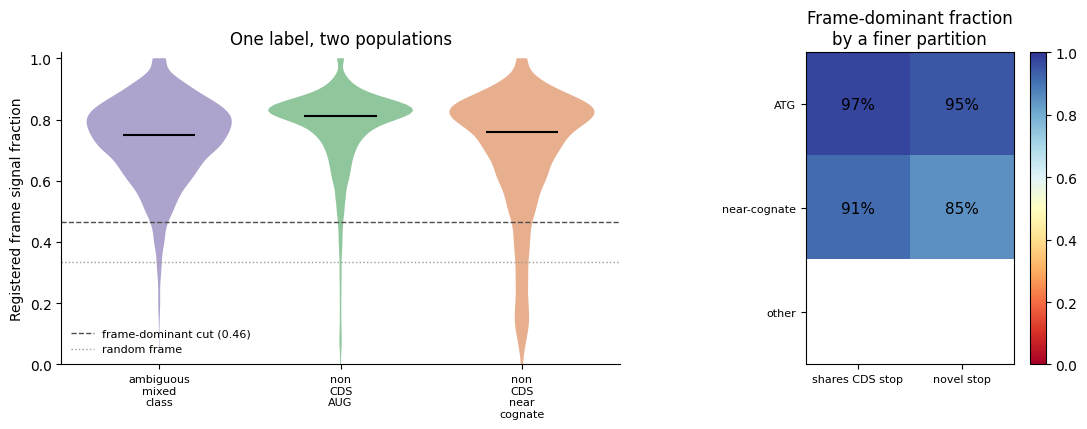

Saved figures_talk_foundation/12_granularity_grid.png


In [103]:
# === Cell 12: Coarse non-CDS classes hide the evidence that finer classes expose ===
if not SCORES_ARE_REGISTERED or evidence_df.empty:
    print('Skipping granularity: scores not registered or evidence_df empty.')
else:
    ev = evidence_df[evidence_df['coverage_pass'].astype(bool)].copy()
    cds = ev[ev['context_class'].eq('annotated_CDS')]
    EV_DOM = cds['periodicity'].quantile(0.10) if len(cds) else 0.5
    nc = ev[~ev['context_class'].eq('annotated_CDS')].copy()

    def start_sub(s):
        s = str(s)
        return 'ATG' if 'ATG' in s else ('near-cognate' if 'near_cognate' in s else 'other')
    nc['start_sub'] = nc['start_codon_classes'].map(start_sub)
    cds_stops = set(ev.loc[ev['context_class'].eq('annotated_CDS'), 'stop_key'])
    nc['stop_origin'] = np.where(nc['stop_key'].isin(cds_stops), 'shares CDS stop', 'novel stop')
    nc['frame_dominant'] = nc['periodicity'].ge(EV_DOM)

    classes = [c for c in CONTEXT_ORDER if c in set(nc['context_class'])]
    grid = (nc.groupby(['start_sub', 'stop_origin'])['frame_dominant'].mean()
              .unstack().reindex(index=['ATG', 'near-cognate', 'other'],
                                 columns=['shares CDS stop', 'novel stop']))
    save_table(grid.reset_index(), '12_granularity_grid')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={'width_ratios': [1.4, 1]})
    data = [nc.loc[nc['context_class'].eq(c), 'periodicity'].dropna() for c in classes]
    parts = axes[0].violinplot(data, positions=range(1, len(classes)+1), widths=0.8, showmedians=True, showextrema=False)
    for b, c in zip(parts['bodies'], classes):
        b.set_facecolor(CONTEXT_COLORS.get(c, '0.5')); b.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    axes[0].axhline(EV_DOM, color='0.3', ls='--', lw=1, label=f'frame-dominant cut ({EV_DOM:.2f})')
    axes[0].axhline(1/3, color='0.6', ls=':', lw=1, label='random frame')
    axes[0].set_xticks(range(1, len(classes)+1)); axes[0].set_xticklabels([c.replace('_', '\n') for c in classes], fontsize=8)
    axes[0].set_ylim(0, 1.02); axes[0].set_ylabel('Registered frame signal fraction')
    axes[0].set_title('One label, two populations'); axes[0].legend(frameon=False, fontsize=8, loc='lower left')
    axes[0].spines[['top', 'right']].set_visible(False)

    im = axes[1].imshow(grid.values, cmap='RdYlBu', vmin=0, vmax=1)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid.values[i, j]
            axes[1].text(j, i, '' if np.isnan(v) else f'{v:.0%}', ha='center', va='center', fontsize=11)
    axes[1].set_xticks(range(grid.shape[1])); axes[1].set_xticklabels(grid.columns, fontsize=8)
    axes[1].set_yticks(range(grid.shape[0])); axes[1].set_yticklabels(grid.index, fontsize=8)
    axes[1].set_title('Frame-dominant fraction\nby a finer partition')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    finish_plot(fig, '12_granularity_grid.png')

## 15. Ranked example locus tables

These tables are designed for hand-picking example loci. The top rows should be interpretable, not just extreme.


In [92]:
example_loci_tables = {}

if evidence_df.empty:
    print('Skipping ranked loci: evidence_df is empty.')
else:
    rank_base = evidence_df.copy()
    rank_base['periodicity_rank_value'] = rank_base['periodicity'].fillna(-1)
    rank_base['body_total_signal_rank_value'] = rank_base['body_total_signal'].fillna(0)

    if not plot_starts_per_stop_df.empty:
        shared_stop = (
            rank_base
            .merge(plot_starts_per_stop_df[['stop_key', 'n_starts', 'n_candidates', 'start_span_nt']], on='stop_key', how='left')
            .query('n_starts >= 2 and n_tools_stop >= 2')
            .sort_values(['n_tools_stop', 'periodicity_rank_value', 'n_candidates'], ascending=[False, False, True])
        )
        example_loci_tables['loci_shared_stop_multiple_starts'] = shared_stop.head(50)

    tool_specific = (
        rank_base
        .query("agreement_class == 'tool_specific'")
        .query('coverage_pass == True')
        .query("context_class != 'annotated_CDS'")
        .sort_values(['periodicity_rank_value', 'body_total_signal_rank_value'], ascending=False)
    )
    example_loci_tables['loci_tool_specific_high_evidence'] = tool_specific.head(50)

    consensus_low = (
        rank_base
        .query('n_tools_full >= 2')
        .query('coverage_pass == True')
        .sort_values(['n_tools_full', 'periodicity_rank_value'], ascending=[False, True])
    )
    example_loci_tables['loci_full_consensus_low_evidence'] = consensus_low.head(50)

    # Simple overlap clusters: interval overlap within chrom/strand among pooled candidates.
    cluster_rows = []
    cluster_id = 0
    if not agreement_df.empty:
        for (chrom, strand), grp in agreement_df.sort_values(['bed_chrom', 'bed_strand', 'bed_start', 'bed_end']).groupby(['bed_chrom', 'bed_strand']):
            active = []
            current = []
            current_end = None
            for row in grp.itertuples(index=False):
                start, end = int(row.bed_start), int(row.bed_end)
                if current and start > current_end:
                    cluster_id += 1
                    for r in current:
                        cluster_rows.append({'feature_key': r.feature_key, 'overlap_cluster_id': cluster_id, 'cluster_size': len(current)})
                    current = []
                    current_end = None
                current.append(row)
                current_end = end if current_end is None else max(current_end, end)
            if current:
                cluster_id += 1
                for r in current:
                    cluster_rows.append({'feature_key': r.feature_key, 'overlap_cluster_id': cluster_id, 'cluster_size': len(current)})
    overlap_clusters = pd.DataFrame(cluster_rows)
    if not overlap_clusters.empty:
        complex_overlap = (
            rank_base
            .merge(overlap_clusters, on='feature_key', how='left')
            .query('cluster_size >= 3')
            .sort_values(['cluster_size', 'n_tools_full', 'periodicity_rank_value'], ascending=[False, False, False])
        )
    else:
        complex_overlap = pd.DataFrame()
    example_loci_tables['loci_complex_overlap_candidates'] = complex_overlap.head(50)

for name, df in example_loci_tables.items():
    save_table(df, name)
    print(f'{name}: {df.shape}')
    display(df.head(5))


KeyError: "Expected column 'start_codon_class' in evidence_df. Make sure start_codon_class is carried through into evidence_df."

## 16. Simple locus plots

The locus plot is intentionally minimal: candidate intervals plus optional coverage if a `BigWigPair` is supplied later.


In [ ]:
def plot_locus(locus_row, candidates_df, scores_df=None, bws=None, window_nt=150, out=None):
    if isinstance(locus_row, pd.Series):
        row = locus_row
    else:
        row = pd.Series(locus_row)

    chrom = row['bed_chrom']
    strand = row['bed_strand']
    center_start = int(row['bed_start'])
    center_end = int(row['bed_end'])
    start = max(0, center_start - window_nt)
    end = center_end + window_nt

    locus_candidates = candidates_df[
        candidates_df['bed_chrom'].eq(chrom)
        & candidates_df['bed_strand'].eq(strand)
        & candidates_df['bed_end'].ge(start)
        & candidates_df['bed_start'].le(end)
    ].copy()
    if locus_candidates.empty:
        print('No candidates in locus window.')
        return None

    fig, axes = plt.subplots(2, 1, figsize=(9.5, 3.8), sharex=True, gridspec_kw={'height_ratios': [1.8, 1]})
    ax = axes[0]
    locus_candidates = locus_candidates.sort_values(['bed_start', 'bed_end']).reset_index(drop=True)
    for y, cand in enumerate(locus_candidates.itertuples(index=False)):
        color = AGREEMENT_COLORS.get(getattr(cand, 'agreement_class', 'tool_specific'), '0.5')
        ax.plot([cand.bed_start, cand.bed_end], [y, y], color=color, lw=7, solid_capstyle='butt')
        label = f"{getattr(cand, 'n_tools_full', '?')} tools | {getattr(cand, 'context_class', '')}"
        ax.text(cand.bed_end + max(1, (end - start) * 0.01), y, label, va='center', fontsize=8)
    ax.axvspan(center_start, center_end, color='0.9', zorder=-1)
    ax.set_yticks([])
    ax.set_ylabel('candidate ORFs')
    ax.set_title(f'{chrom}:{start:,}-{end:,} ({strand})')
    ax.spines[['top', 'right', 'left']].set_visible(False)

    cov_ax = axes[1]
    if bws is not None:
        try:
            vals = bws.values(chrom, start, end, strand, reverse=False)
            if vals is not None:
                xs = np.arange(start, start + len(vals))
                cov_ax.plot(xs, vals, color='black', lw=0.8)
                cov_ax.set_ylabel('P-site signal')
            else:
                cov_ax.text(0.5, 0.5, 'no bigWig signal', transform=cov_ax.transAxes, ha='center', va='center')
        except Exception as exc:
            cov_ax.text(0.5, 0.5, f'coverage unavailable: {exc}', transform=cov_ax.transAxes, ha='center', va='center')
    else:
        cov_ax.text(0.5, 0.5, 'coverage track not loaded', transform=cov_ax.transAxes, ha='center', va='center')
    cov_ax.set_xlabel('genomic coordinate')
    cov_ax.spines[['top', 'right']].set_visible(False)

    fig.tight_layout()
    if out is not None:
        fig.savefig(out, dpi=180, bbox_inches='tight')
        print(f'Saved {out}')
    plt.show()
    return fig

# Enrich candidates for locus plotting.
locus_candidates_df = agreement_df.merge(context_df[['feature_key', 'context_class']], on='feature_key', how='left') if not agreement_df.empty and not context_df.empty else agreement_df

example_specs = [
    ('loci_shared_stop_multiple_starts', '09_locus_shared_stop_multiple_starts.png'),
    ('loci_tool_specific_high_evidence', '10_locus_tool_specific_high_evidence.png'),
    ('loci_full_consensus_low_evidence', '11_locus_consensus_low_evidence.png'),
]
for table_name, png_name in example_specs:
    table = example_loci_tables.get(table_name, pd.DataFrame())
    if table.empty:
        print(f'Skipping {png_name}: {table_name} is empty')
        continue
    plot_locus(table.iloc[0], locus_candidates_df, scores_unique, bws=None, out=OUT_DIR / png_name)


## 17. Final readiness checklist

Before using periodicity plots in slides, verify:
- `SCORES_ARE_REGISTERED` is `True`.
- `signal_score_summary.json` records `psite_offset` for each sample.
- `Ribo_Pancreas_pooled` coverage-pass annotated CDS median periodicity is above 0.5.
- The plot dataframe TSV for each slide exists in `tables_talk_foundation/`.


In [111]:
# Per-metric start-site arbitration plots.
# No composite score: each panel asks whether one Ribo-Seq metric picks the same
# start as the tool-consensus start within shared-stop, multi-start groups.

START_SAMPLE = PRIMARY_SAMPLE

METRICS = [
    ("periodicity", "Registered frame periodicity", "higher"),
    ("start_rise_ratio", "Start rise ratio", "higher"),
    ("body_total_signal", "Body P-site signal", "higher"),
]

ev = evidence_df[evidence_df["sample_id"].eq(START_SAMPLE)].copy()

for metric, _, _ in METRICS:
    ev[metric] = pd.to_numeric(ev[metric], errors="coerce")

ev["coverage_pass"] = ev["coverage_pass"].fillna(False).astype(bool)

start_base = ev[
    ev["coverage_pass"]
    & ev["stop_key"].notna()
    & ev["start_key"].notna()
    & ev["context_class"].ne("annotated_CDS")
].copy()

multi_stop_keys = (
    start_base
    .groupby("stop_key")["start_key"]
    .nunique()
    .loc[lambda s: s >= 2]
    .index
)

multi = start_base[start_base["stop_key"].isin(multi_stop_keys)].copy()

def metric_start_choice(df, metric):
    usable = df[df[metric].notna() & np.isfinite(df[metric])].copy()

    consensus = (
        usable
        .sort_values(
            ["stop_key", "n_tools_full", "n_tools_start", metric, "body_total_signal"],
            ascending=[True, False, False, False, False],
        )
        .groupby("stop_key", as_index=False)
        .head(1)
        [["stop_key", "feature_key", "start_key", "n_tools_full", metric]]
        .rename(columns={
            "feature_key": "consensus_feature_key",
            "start_key": "consensus_start_key",
            "n_tools_full": "consensus_n_tools_full",
            metric: f"consensus_{metric}",
        })
    )

    metric_best = (
        usable
        .sort_values(
            ["stop_key", metric, "n_tools_full", "body_total_signal"],
            ascending=[True, False, False, False],
        )
        .groupby("stop_key", as_index=False)
        .head(1)
        [["stop_key", "feature_key", "start_key", "n_tools_full", metric]]
        .rename(columns={
            "feature_key": "metric_feature_key",
            "start_key": "metric_start_key",
            "n_tools_full": "metric_n_tools_full",
            metric: f"metric_{metric}",
        })
    )

    out = consensus.merge(metric_best, on="stop_key", how="inner")
    out["same_start"] = out["consensus_start_key"].eq(out["metric_start_key"])
    out["metric"] = metric
    return out

metric_choice = pd.concat(
    [metric_start_choice(multi, metric) for metric, _, _ in METRICS],
    ignore_index=True,
)

save_table(metric_choice, "per_metric_shared_stop_start_choice")
display(metric_choice.head())

Saved tables_talk_foundation/per_metric_shared_stop_start_choice.tsv


,stop_key,consensus_feature_key,consensus_start_key,consensus_n_tools_full,consensus_periodicity,metric_feature_key,metric_start_key,metric_n_tools_full,metric_periodicity,same_start,metric,consensus_start_rise_ratio,metric_start_rise_ratio,consensus_body_total_signal,metric_body_total_signal
0,chr10:+:100373779,chr10:100373644-100373779:+:135:0,chr10:+:100373644,5,0.810414,chr10:100373653-100373779:+:126:0,chr10:+:100373653,1,0.812668,False,periodicity,NaN,NaN,NaN,NaN
1,chr10:+:100381452,"chr10:100373946-100381452:+:66,237:0,7269",chr10:+:100373946,1,0.764228,chr10:100381293-100381452:+:159:0,chr10:+:100381293,1,0.785714,False,periodicity,NaN,NaN,NaN,NaN
2,chr10:+:100382521,"chr10:100381293-100382521:+:155,94:0,1134",chr10:+:100381293,2,0.740260,"chr10:100381106-100382521:+:3,233,94:0,109,1321",chr10:+:100381106,1,0.762712,False,periodicity,NaN,NaN,NaN,NaN
3,chr10:+:100388040,"chr10:100373946-100388040:+:66,233,4:0,7269,14090",chr10:+:100373946,2,0.764228,"chr10:100381293-100388040:+:155,4:0,6743",chr10:+:100381293,1,0.785714,False,periodicity,NaN,NaN,NaN,NaN
4,chr10:+:100388068,"chr10:100373946-100388068:+:66,233,28:0,7269,1...",chr10:+:100373946,1,0.761905,"chr10:100381293-100388068:+:155,28:0,6747",chr10:+:100381293,1,0.779661,False,periodicity,NaN,NaN,NaN,NaN


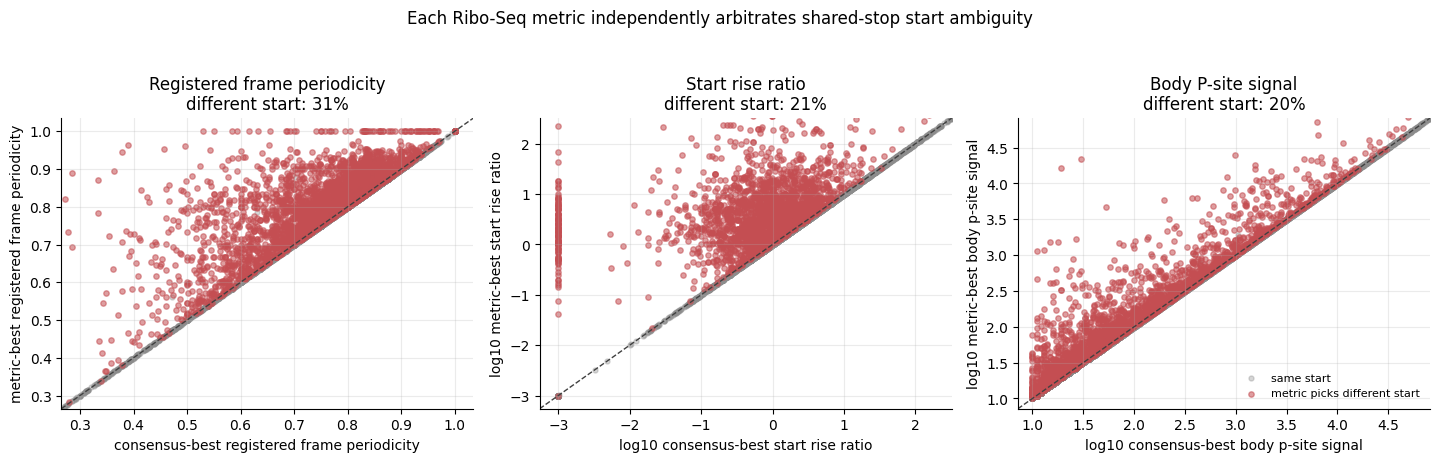

Saved figures_talk_foundation/per_metric_start_arbitration_scatter.png


PosixPath('figures_talk_foundation/per_metric_start_arbitration_scatter.png')

In [112]:
# Multi-panel scatter: consensus-best start vs metric-best start.

fig, axes = plt.subplots(1, len(METRICS), figsize=(14.5, 4.4), sharey=False)

if len(METRICS) == 1:
    axes = [axes]

for ax, (metric, label, _) in zip(axes, METRICS):
    sub = metric_choice[metric_choice["metric"].eq(metric)].copy()

    xcol = f"consensus_{metric}"
    ycol = f"metric_{metric}"

    same = sub["same_start"]
    frac_diff = 1 - same.mean() if len(sub) else np.nan

    # Log display only for skewed count/ratio metrics.
    if metric in {"start_rise_ratio", "body_total_signal"}:
        sub[xcol] = np.log10(sub[xcol].clip(lower=1e-3))
        sub[ycol] = np.log10(sub[ycol].clip(lower=1e-3))
        xlabel = f"log10 consensus-best {label.lower()}"
        ylabel = f"log10 metric-best {label.lower()}"
    else:
        xlabel = f"consensus-best {label.lower()}"
        ylabel = f"metric-best {label.lower()}"

    ax.scatter(
        sub.loc[same, xcol],
        sub.loc[same, ycol],
        s=13,
        alpha=0.35,
        color="0.55",
        label="same start",
    )

    ax.scatter(
        sub.loc[~same, xcol],
        sub.loc[~same, ycol],
        s=15,
        alpha=0.55,
        color="#C44E52",
        label="metric picks different start",
    )

    finite_vals = sub[[xcol, ycol]].replace([np.inf, -np.inf], np.nan).stack()
    if len(finite_vals):
        lo, hi = finite_vals.quantile([0.01, 0.99])
        pad = (hi - lo) * 0.05 if hi > lo else 0.05
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="0.25", lw=1, ls="--")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)

    ax.set_title(f"{label}\ndifferent start: {frac_diff:.0%}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Each Ribo-Seq metric independently arbitrates shared-stop start ambiguity", y=1.04)
finish_plot(fig, "per_metric_start_arbitration_scatter.png")

Saved tables_talk_foundation/per_metric_caller_weak_evidence_summary.tsv


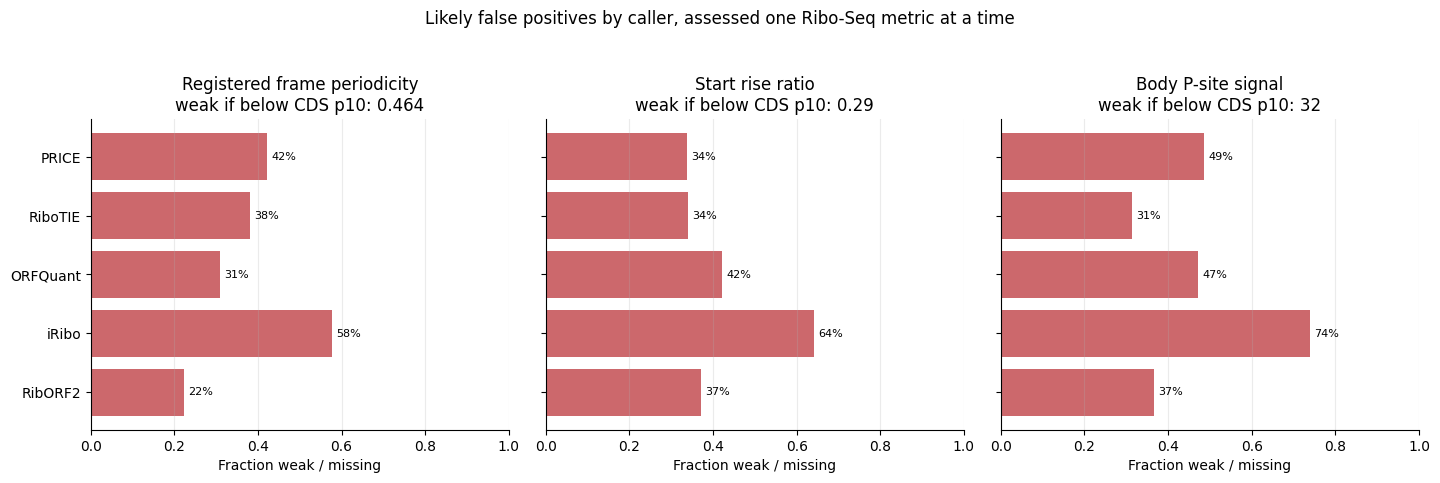

Saved figures_talk_foundation/per_metric_caller_false_positive_risk.png


PosixPath('figures_talk_foundation/per_metric_caller_false_positive_risk.png')

In [113]:
# Per-metric caller false-positive-risk panels.
# Each metric gets its own threshold from annotated CDS, then projects weak evidence
# back onto caller outputs.

tool_ev = (
    calls_pooled[["source_tool", "feature_key"]]
    .drop_duplicates()
    .merge(
        ev[[
            "feature_key", "context_class", "coverage_pass",
            "periodicity", "start_rise_ratio", "body_total_signal",
        ]],
        on="feature_key",
        how="left",
    )
)

tool_ev = tool_ev[tool_ev["context_class"].ne("annotated_CDS")].copy()

cds_ref = ev[
    ev["coverage_pass"]
    & ev["context_class"].eq("annotated_CDS")
].copy()

metric_thresholds = {
    "periodicity": cds_ref["periodicity"].quantile(0.10),
    "start_rise_ratio": cds_ref["start_rise_ratio"].quantile(0.10),
    "body_total_signal": cds_ref["body_total_signal"].quantile(0.10),
}

fp_rows = []

for metric, label, _ in METRICS:
    cut = metric_thresholds[metric]

    tmp = tool_ev.copy()
    tmp["metric"] = metric
    tmp["metric_label"] = label
    tmp["threshold"] = cut
    tmp["weak_metric_evidence"] = (
        ~tmp["coverage_pass"]
        | tmp[metric].isna()
        | tmp[metric].lt(cut)
    )

    summ = (
        tmp
        .groupby(["source_tool", "metric", "metric_label", "weak_metric_evidence"])["feature_key"]
        .nunique()
        .reset_index(name="n_candidates")
    )

    summ["tool_metric_total"] = (
        summ.groupby(["source_tool", "metric"])["n_candidates"].transform("sum")
    )
    summ["fraction"] = summ["n_candidates"] / summ["tool_metric_total"]
    fp_rows.append(summ)

fp_metric_summary = pd.concat(fp_rows, ignore_index=True)
save_table(fp_metric_summary, "per_metric_caller_weak_evidence_summary")

fig, axes = plt.subplots(1, len(METRICS), figsize=(14.5, 4.6), sharey=True)

if len(METRICS) == 1:
    axes = [axes]

tool_order = [t for t in TOOL_ORDER if t in fp_metric_summary["source_tool"].unique()]

for ax, (metric, label, _) in zip(axes, METRICS):
    sub = fp_metric_summary[
        fp_metric_summary["metric"].eq(metric)
        & fp_metric_summary["weak_metric_evidence"].eq(True)
    ].copy()

    sub = (
        sub
        .set_index("source_tool")
        .reindex(tool_order)
        .reset_index()
    )

    ax.barh(
        np.arange(len(sub)),
        sub["fraction"],
        color="#C44E52",
        alpha=0.85,
    )

    for i, row in sub.iterrows():
        if pd.notna(row["fraction"]):
            ax.text(
                row["fraction"] + 0.01,
                i,
                f"{row['fraction']:.0%}",
                va="center",
                fontsize=8,
            )

    cut = metric_thresholds[metric]
    ax.set_xlim(0, 1)
    ax.set_title(f"{label}\nweak if below CDS p10: {cut:.3g}")
    ax.set_xlabel("Fraction weak / missing")
    ax.grid(axis="x", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_yticks(np.arange(len(tool_order)))
axes[0].set_yticklabels(tool_order)
axes[0].invert_yaxis()

fig.suptitle("Likely false positives by caller, assessed one Ribo-Seq metric at a time", y=1.04)
finish_plot(fig, "per_metric_caller_false_positive_risk.png")

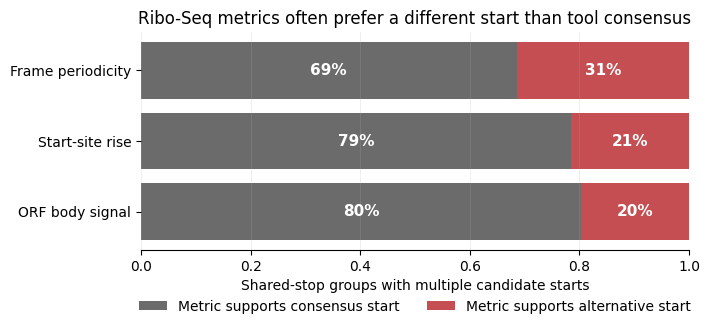

Saved figures_talk_foundation/per_metric_start_arbitration_summary_bar.png


PosixPath('figures_talk_foundation/per_metric_start_arbitration_summary_bar.png')

In [114]:
# Presentation-first summary:
# For each metric, how often does it choose the tool-consensus start vs another start?

summary = (
    metric_choice
    .assign(choice=np.where(
        metric_choice["same_start"],
        "Metric supports consensus start",
        "Metric supports alternative start",
    ))
    .groupby(["metric", "choice"], as_index=False)
    .size()
    .rename(columns={"size": "n_stop_groups"})
)

summary["fraction"] = (
    summary["n_stop_groups"]
    / summary.groupby("metric")["n_stop_groups"].transform("sum")
)

metric_labels = {
    "periodicity": "Frame periodicity",
    "start_rise_ratio": "Start-site rise",
    "body_total_signal": "ORF body signal",
}

summary["metric_label"] = summary["metric"].map(metric_labels)

choice_order = [
    "Metric supports consensus start",
    "Metric supports alternative start",
]

summary["choice"] = pd.Categorical(summary["choice"], choice_order, ordered=True)

pivot = (
    summary
    .pivot_table(
        index="metric_label",
        columns="choice",
        values="fraction",
        fill_value=0,
    )
    .reindex(["Frame periodicity", "Start-site rise", "ORF body signal"])
)

fig, ax = plt.subplots(figsize=(7.2, 3.6))

left = np.zeros(len(pivot))
colors = {
    "Metric supports consensus start": "#6b6b6b",
    "Metric supports alternative start": "#C44E52",
}

for choice in choice_order:
    vals = pivot[choice].values
    ax.barh(
        np.arange(len(pivot)),
        vals,
        left=left,
        color=colors[choice],
        label=choice,
    )
    for y, v, l in zip(np.arange(len(pivot)), vals, left):
        if v > 0.06:
            ax.text(
                l + v / 2,
                y,
                f"{v:.0%}",
                ha="center",
                va="center",
                color="white",
                fontsize=11,
                fontweight="bold",
            )
    left += vals

ax.set_yticks(np.arange(len(pivot)))
ax.set_yticklabels(pivot.index)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Shared-stop groups with multiple candidate starts")
ax.set_title("Ribo-Seq metrics often prefer a different start than tool consensus")
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=2)
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right", "left"]].set_visible(False)

finish_plot(fig, "per_metric_start_arbitration_summary_bar.png")

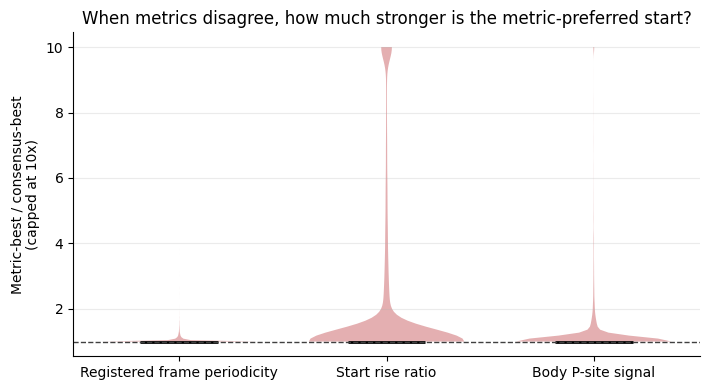

Saved figures_talk_foundation/per_metric_start_arbitration_fold_gain.png


PosixPath('figures_talk_foundation/per_metric_start_arbitration_fold_gain.png')

In [115]:
# More interpretable than log10 scatter:
# fold-change of metric-best start over consensus-best start.

fold_rows = []

for metric, label, _ in METRICS:
    sub = metric_choice[metric_choice["metric"].eq(metric)].copy()
    xcol = f"consensus_{metric}"
    ycol = f"metric_{metric}"

    sub = sub[
        sub[xcol].notna()
        & sub[ycol].notna()
        & np.isfinite(sub[xcol])
        & np.isfinite(sub[ycol])
        & sub[xcol].gt(0)
        & sub[ycol].gt(0)
    ].copy()

    sub["metric_label"] = label
    sub["fold_gain"] = sub[ycol] / sub[xcol]
    fold_rows.append(sub)

fold_df = pd.concat(fold_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(7.2, 4.0))

metric_order = [label for _, label, _ in METRICS]
plot_data = [
    fold_df.loc[fold_df["metric_label"].eq(label), "fold_gain"].clip(upper=10)
    for label in metric_order
]

parts = ax.violinplot(
    plot_data,
    positions=np.arange(len(metric_order)),
    widths=0.75,
    showmedians=True,
    showextrema=False,
)

for body in parts["bodies"]:
    body.set_facecolor("#C44E52")
    body.set_alpha(0.45)

parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

ax.axhline(1, color="0.25", lw=1, ls="--")
ax.set_xticks(np.arange(len(metric_order)))
ax.set_xticklabels(metric_order)
ax.set_ylabel("Metric-best / consensus-best\n(capped at 10x)")
ax.set_title("When metrics disagree, how much stronger is the metric-preferred start?")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

finish_plot(fig, "per_metric_start_arbitration_fold_gain.png")

In [116]:
# Build simple, explainable call sets for distribution plots.

plot_ev = evidence_df[evidence_df["sample_id"].eq(PRIMARY_SAMPLE)].copy()

for col in ["periodicity", "start_rise_ratio", "body_total_signal"]:
    plot_ev[col] = pd.to_numeric(plot_ev[col], errors="coerce")

plot_ev["coverage_pass"] = plot_ev["coverage_pass"].fillna(False).astype(bool)

# Shared-stop, multiple-start groups.
stop_start_counts = (
    plot_ev
    .dropna(subset=["stop_key", "start_key"])
    .groupby("stop_key")["start_key"]
    .nunique()
    .rename("n_starts_for_stop")
)

plot_ev = plot_ev.merge(stop_start_counts, on="stop_key", how="left")
plot_ev["n_starts_for_stop"] = plot_ev["n_starts_for_stop"].fillna(0).astype(int)

# Union overlap clusters in genomic space.
def add_overlap_clusters(df):
    rows = []
    cluster_id = 0

    base = (
        df[[
            "feature_key", "bed_chrom", "bed_strand",
            "bed_start", "bed_end"
        ]]
        .dropna()
        .drop_duplicates()
        .sort_values(["bed_chrom", "bed_strand", "bed_start", "bed_end"])
    )

    for (chrom, strand), grp in base.groupby(["bed_chrom", "bed_strand"], sort=False):
        current = []
        current_end = None

        for row in grp.itertuples(index=False):
            start = int(row.bed_start)
            end = int(row.bed_end)

            if current and start >= current_end:
                cluster_id += 1
                for r in current:
                    rows.append({
                        "feature_key": r.feature_key,
                        "overlap_cluster": cluster_id,
                        "overlap_cluster_size": len(current),
                    })
                current = []
                current_end = None

            current.append(row)
            current_end = end if current_end is None else max(current_end, end)

        if current:
            cluster_id += 1
            for r in current:
                rows.append({
                    "feature_key": r.feature_key,
                    "overlap_cluster": cluster_id,
                    "overlap_cluster_size": len(current),
                })

    return pd.DataFrame(rows)

overlap_df = add_overlap_clusters(plot_ev)

plot_ev = plot_ev.merge(overlap_df, on="feature_key", how="left")
plot_ev["overlap_cluster_size"] = plot_ev["overlap_cluster_size"].fillna(1).astype(int)

plot_ev["plot_call_set"] = np.select(
    [
        plot_ev["context_class"].eq("annotated_CDS"),
        plot_ev["context_class"].ne("annotated_CDS") & plot_ev["n_starts_for_stop"].ge(2),
        plot_ev["context_class"].ne("annotated_CDS") & plot_ev["overlap_cluster_size"].ge(2),
        plot_ev["context_class"].ne("annotated_CDS") & plot_ev["agreement_class"].eq("tool_specific"),
    ],
    [
        "Annotated CDS",
        "Same stop,\nmultiple starts",
        "Overlaps another\nunion feature",
        "Tool-specific\nnon-CDS",
    ],
    default="Standalone\nnon-CDS",
)

CALL_SET_ORDER = [
    "Annotated CDS",
    "Same stop,\nmultiple starts",
    "Standalone\nnon-CDS",
    "Overlaps another\nunion feature",
    "Tool-specific\nnon-CDS",
]

save_table(plot_ev, "riboseq_metric_distribution_call_sets")
display(plot_ev["plot_call_set"].value_counts().reindex(CALL_SET_ORDER))

Saved tables_talk_foundation/riboseq_metric_distribution_call_sets.tsv


plot_call_set
Annotated CDS                      131217
Same stop,\nmultiple starts         54250
Standalone\nnon-CDS                  5588
Overlaps another\nunion feature     38299
Tool-specific\nnon-CDS               8619
Name: count, dtype: int64

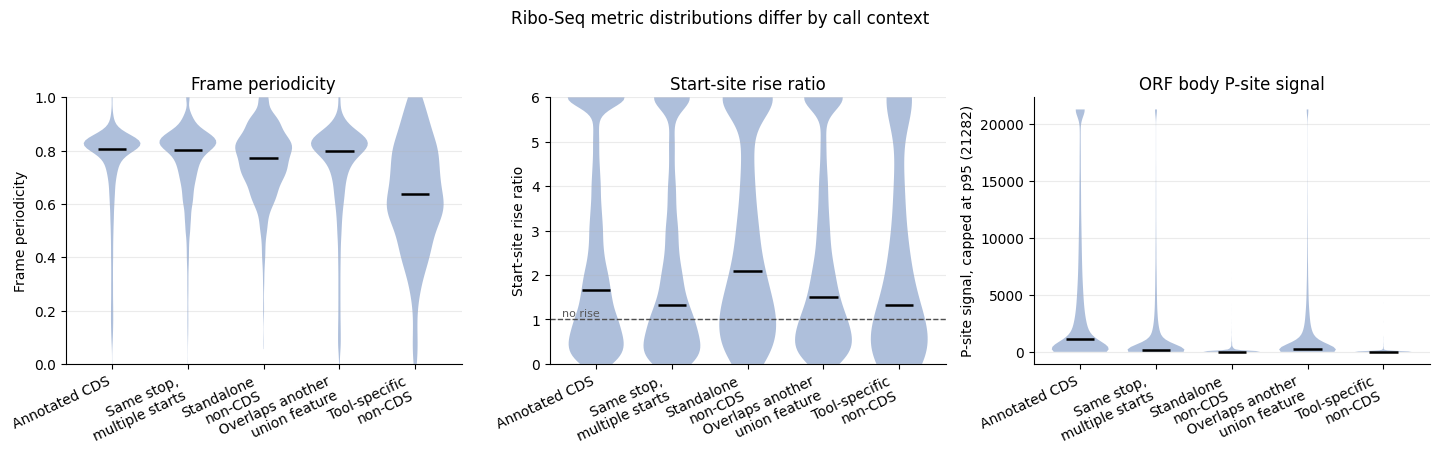

Saved figures_talk_foundation/riboseq_metric_distributions_by_call_set.png


PosixPath('figures_talk_foundation/riboseq_metric_distributions_by_call_set.png')

In [117]:
# One simple multi-panel distribution figure.
# Avoid log axes except where the raw metric is too skewed.
# Start rise is capped for display; body signal is shown as coverage pass/fail separately below.

dist_df = plot_ev[
    plot_ev["plot_call_set"].isin(CALL_SET_ORDER)
    & plot_ev["coverage_pass"]
].copy()

metrics = [
    ("periodicity", "Frame periodicity", (0, 1), None),
    ("start_rise_ratio", "Start-site rise ratio", (0, 6), 6),
    ("body_total_signal", "ORF body P-site signal", None, None),
]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), sharex=False)

for ax, (metric, title, ylim, cap) in zip(axes, metrics):
    data = []
    labels = []

    for call_set in CALL_SET_ORDER:
        vals = dist_df.loc[
            dist_df["plot_call_set"].eq(call_set),
            metric
        ].dropna()

        vals = vals[np.isfinite(vals)]

        if cap is not None:
            vals = vals.clip(upper=cap)

        # For body signal, cap at p95 rather than log-transforming.
        if metric == "body_total_signal" and len(vals):
            cap_val = dist_df[metric].dropna().quantile(0.95)
            vals = vals.clip(upper=cap_val)

        data.append(vals)
        labels.append(call_set)

    parts = ax.violinplot(
        data,
        positions=np.arange(len(labels)),
        widths=0.75,
        showmedians=True,
        showextrema=False,
    )

    for body in parts["bodies"]:
        body.set_facecolor("#4C72B0")
        body.set_alpha(0.45)

    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.8)

    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right")

    if ylim is not None:
        ax.set_ylim(*ylim)

    if metric == "start_rise_ratio":
        ax.axhline(1, color="0.3", lw=1, ls="--")
        ax.text(-0.45, 1.08, "no rise", fontsize=8, color="0.35")

    if metric == "body_total_signal":
        cap_val = dist_df[metric].dropna().quantile(0.95)
        ax.set_ylabel(f"P-site signal, capped at p95 ({cap_val:.0f})")
    else:
        ax.set_ylabel(title)

    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Ribo-Seq metric distributions differ by call context", y=1.04)
fig.tight_layout()
finish_plot(fig, "riboseq_metric_distributions_by_call_set.png")

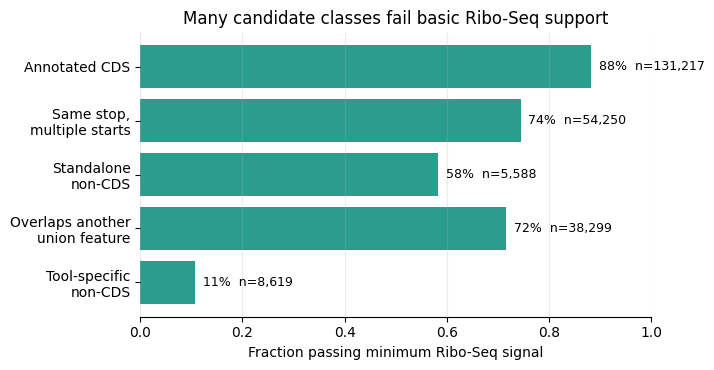

Saved figures_talk_foundation/riboseq_coverage_pass_by_call_set.png


PosixPath('figures_talk_foundation/riboseq_coverage_pass_by_call_set.png')

In [118]:
# Body signal is often easier to present as: does this call have enough signal at all?

coverage_summary = (
    plot_ev
    .groupby("plot_call_set", as_index=False)
    .agg(
        fraction_coverage_pass=("coverage_pass", "mean"),
        n_features=("feature_key", "nunique"),
    )
)

coverage_summary["plot_call_set"] = pd.Categorical(
    coverage_summary["plot_call_set"],
    categories=CALL_SET_ORDER,
    ordered=True,
)

coverage_summary = coverage_summary.sort_values("plot_call_set")

fig, ax = plt.subplots(figsize=(7.2, 3.8))

ax.barh(
    coverage_summary["plot_call_set"].astype(str),
    coverage_summary["fraction_coverage_pass"],
    color="#2a9d8f",
)

for i, row in coverage_summary.reset_index(drop=True).iterrows():
    ax.text(
        row["fraction_coverage_pass"] + 0.015,
        i,
        f"{row['fraction_coverage_pass']:.0%}  n={int(row['n_features']):,}",
        va="center",
        fontsize=9,
    )

ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_xlabel("Fraction passing minimum Ribo-Seq signal")
ax.set_ylabel("")
ax.set_title("Many candidate classes fail basic Ribo-Seq support")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right", "left"]].set_visible(False)

finish_plot(fig, "riboseq_coverage_pass_by_call_set.png")

Saved tables_talk_foundation/075_consensus_x_signal.tsv


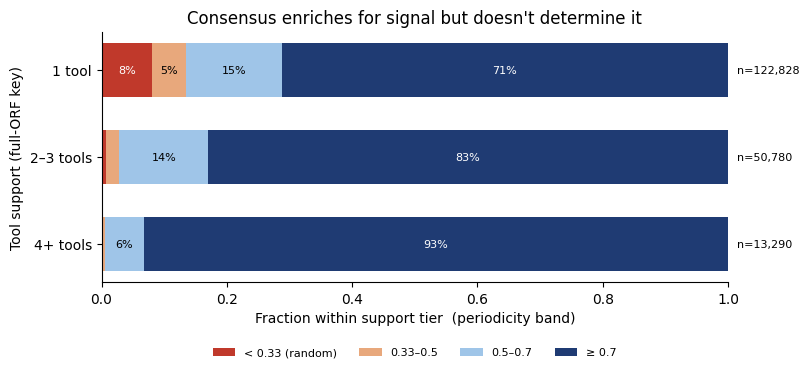

Saved figures_talk_foundation/075_consensus_x_signal.png


In [121]:
## 13.5 Plot 7.5: Does agreement track quality? (consensus × graded signal)
SIGNAL_COL = "periodicity"   # swap for a per-feature in-frame count column if available
BANDS  = [0, 1/3, 0.5, 0.7, 1.01]
LABELS = ["< 0.33 (random)", "0.33–0.5", "0.5–0.7", "≥ 0.7"]
COLORS = ["#c0392b", "#e8a87c", "#9fc5e8", "#1f3b73"]   # red→blue: low→high signal

if not SCORES_ARE_REGISTERED or evidence_df.empty or SIGNAL_COL not in evidence_df:
    print("Skipping consensus × signal: scores not registered / column missing.")
else:
    cs = evidence_df[evidence_df["coverage_pass"].astype(bool)].copy()
    cs = cs.dropna(subset=["n_tools_full", SIGNAL_COL])

    def tier(n):
        return "1 tool" if n <= 1 else ("2–3 tools" if n <= 3 else "4+ tools")
    cs["support_tier"] = cs["n_tools_full"].astype(int).map(tier)
    cs["band"] = pd.cut(cs[SIGNAL_COL], bins=BANDS, labels=LABELS,
                        right=False, include_lowest=True)

    tier_order = ["4+ tools", "2–3 tools", "1 tool"]   # top→bottom = less consensus
    counts = (cs.pivot_table(index="support_tier", columns="band",
                             values="feature_key", aggfunc="count", fill_value=0,
                             observed=False)
                .reindex(index=tier_order, columns=LABELS, fill_value=0))
    totals = counts.sum(axis=1)
    frac = counts.div(totals.replace(0, np.nan), axis=0)

    fig, ax = plt.subplots(figsize=(8.2, 3.8))
    y = np.arange(len(tier_order)); left = np.zeros(len(tier_order))
    for lab, col in zip(LABELS, COLORS):
        w = frac[lab].values
        ax.barh(y, w, left=left, color=col, label=lab, height=0.62)
        for yi, wi, li in zip(y, w, left):
            if wi >= 0.04:
                ax.text(li + wi/2, yi, f"{wi:.0%}", ha="center", va="center",
                        fontsize=8, color="white" if col in (COLORS[0], COLORS[3]) else "black")
        left += w
    for yi, t in zip(y, tier_order):
        ax.text(1.015, yi, f"n={int(totals[t]):,}", va="center", fontsize=8)

    ax.set_yticks(y); ax.set_yticklabels(tier_order)
    ax.set_xlim(0, 1); ax.set_xlabel(f"Fraction within support tier  ({SIGNAL_COL} band)")
    ax.set_ylabel("Tool support (full-ORF key)")
    ax.set_title("Consensus enriches for signal but doesn't determine it")
    ax.legend(frameon=False, fontsize=8, ncol=4, loc="upper center",
              bbox_to_anchor=(0.5, -0.22))
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    save_table(counts.reset_index(), "075_consensus_x_signal")
    finish_plot(fig, "075_consensus_x_signal.png")

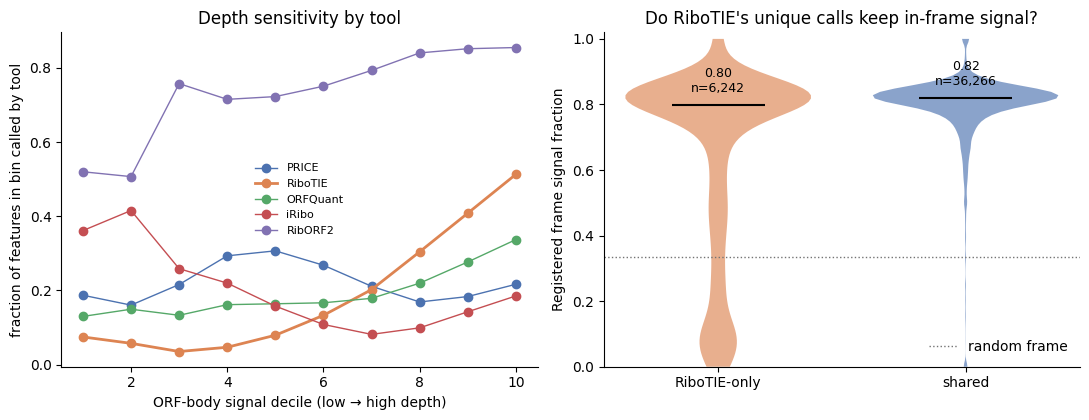

Saved figures_talk_foundation/085_ribotie_depth_robustness.png


In [120]:
## 14.5 Plot 8.5: Is RiboTIE's depth-insensitivity a strength or a liability?
TARGET_TOOL = "RiboTIE"
if calls_pooled.empty or evidence_df.empty or "body_total_signal" not in evidence_df:
    print("Skipping depth-robustness: inputs missing.")
else:
    sig = (evidence_df[["feature_key", "body_total_signal", "periodicity"]]
           .dropna(subset=["body_total_signal"]).drop_duplicates("feature_key"))
    # depth proxy = ORF-body P-site signal, binned into deciles over all called features
    sig["depth_bin"] = pd.qcut(sig["body_total_signal"].rank(method="first"),
                               10, labels=range(1, 11)).astype(int)
    calls = calls_pooled[["source_tool", "feature_key"]].drop_duplicates()
    called = calls.merge(sig, on="feature_key", how="inner")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
    # (a) per-tool call rate across depth deciles
    feats_per_bin = sig.groupby("depth_bin")["feature_key"].nunique()
    for tool in TOOL_ORDER:
        sub = called[called["source_tool"].eq(tool)]
        rate = sub.groupby("depth_bin")["feature_key"].nunique() / feats_per_bin
        axes[0].plot(rate.index, rate.values, marker="o", label=tool,
                     color=TOOL_COLORS.get(tool), lw=2 if tool == TARGET_TOOL else 1)
    axes[0].set_xlabel("ORF-body signal decile (low → high depth)")
    axes[0].set_ylabel("fraction of features in bin called by tool")
    axes[0].set_title("Depth sensitivity by tool")
    axes[0].legend(frameon=False, fontsize=8)
    axes[0].spines[["top", "right"]].set_visible(False)

    # (b) are RiboTIE's lonely calls still in-frame?  shared vs RiboTIE-only
    n_tools = calls.groupby("feature_key")["source_tool"].nunique()
    rt = called[called["source_tool"].eq(TARGET_TOOL)].copy()
    rt["rt_class"] = np.where(rt["feature_key"].map(n_tools) <= 1,
                              f"{TARGET_TOOL}-only", "shared")
    data = [rt.loc[rt["rt_class"].eq(g), "periodicity"].dropna()
            for g in [f"{TARGET_TOOL}-only", "shared"]]
    parts = axes[1].violinplot(data, positions=[1, 2], widths=0.75,
                               showmedians=True, showextrema=False)
    for b, c in zip(parts["bodies"], ["#DD8452", "#4C72B0"]):
        b.set_facecolor(c); b.set_alpha(0.65)
    parts["cmedians"].set_color("black")
    axes[1].axhline(1/3, color="0.45", ls=":", lw=1, label="random frame")
    for pos, vals in zip([1, 2], data):
        if len(vals):
            axes[1].text(pos, min(0.98, vals.median()+0.04),
                         f"{vals.median():.2f}\nn={len(vals):,}", ha="center", fontsize=9)
    axes[1].set_xticks([1, 2]); axes[1].set_xticklabels([f"{TARGET_TOOL}-only", "shared"])
    axes[1].set_ylim(0, 1.02); axes[1].set_ylabel("Registered frame signal fraction")
    axes[1].set_title(f"Do {TARGET_TOOL}'s unique calls keep in-frame signal?")
    axes[1].legend(frameon=False, loc="lower right")
    axes[1].spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    finish_plot(fig, "085_ribotie_depth_robustness.png")

start_rise_candidate_df (193590, 95)


,start_set,stop_key,feature_key,start_key,bed_chrom,bed_strand,start_coord,stop_coord,start_to_stop_nt,position_vs_consensus,...,consensus_periodicity,consensus_body_total_signal,consensus_start_rise_ratio,consensus_start_codon_classes,group_min_start_rise,group_max_body_signal,group_median_body_signal,group_max_periodicity,group_median_periodicity,group_max_n_tools_full
0,all starts,chr10:+:100373779,chr10:100373644-100373779:+:135:0,chr10:+:100373644,chr10,+,100373644,100373779,135,consensus_start,...,0.810414,749.0,1.622222,ATG,0.366935,749.0,742.0,0.812668,0.810414,5
1,all starts,chr10:+:100373779,chr10:100373653-100373779:+:126:0,chr10:+:100373653,chr10,+,100373653,100373779,126,downstream_shorter,...,0.810414,749.0,1.622222,ATG,0.366935,749.0,742.0,0.812668,0.810414,5
2,all starts,chr10:+:100373779,chr10:100373734-100373779:+:45:0,chr10:+:100373734,chr10,+,100373734,100373779,45,downstream_shorter,...,0.810414,749.0,1.622222,ATG,0.366935,749.0,742.0,0.812668,0.810414,5
3,all starts,chr10:+:100381452,chr10:100381293-100381452:+:159:0,chr10:+:100381293,chr10,+,100381293,100381452,159,consensus_start,...,0.785714,56.0,10.250000,ATG,1.500000,123.0,89.5,0.785714,0.774971,1
4,all starts,chr10:+:100381452,"chr10:100373946-100381452:+:66,237:0,7269",chr10:+:100373946,chr10,+,100373946,100381452,7506,upstream_longer,...,0.785714,56.0,10.250000,ATG,1.500000,123.0,89.5,0.785714,0.774971,1
5,all starts,chr10:+:100382521,"chr10:100381293-100382521:+:155,94:0,1134",chr10:+:100381293,chr10,+,100381293,100382521,1228,consensus_start,...,0.740260,77.0,10.250000,ATG,1.142857,118.0,77.0,0.762712,0.740260,2
6,all starts,chr10:+:100382521,chr10:100382464-100382521:+:57:0,chr10:+:100382464,chr10,+,100382464,100382521,57,downstream_shorter,...,0.740260,77.0,10.250000,ATG,1.142857,118.0,77.0,0.762712,0.740260,2
7,all starts,chr10:+:100382521,"chr10:100381106-100382521:+:3,233,94:0,109,1321",chr10:+:100381106,chr10,+,100381106,100382521,1415,upstream_longer,...,0.740260,77.0,10.250000,ATG,1.142857,118.0,77.0,0.762712,0.740260,2
8,all starts,chr10:+:100382521,"chr10:100381269-100382521:+:179,94:0,1158",chr10:+:100381269,chr10,+,100381269,100382521,1252,upstream_longer,...,0.740260,77.0,10.250000,ATG,1.142857,118.0,77.0,0.762712,0.740260,2
9,all starts,chr10:+:100382521,chr10:100382269-100382521:+:252:0,chr10:+:100382269,chr10,+,100382269,100382521,252,downstream_shorter,...,0.740260,77.0,10.250000,ATG,1.142857,118.0,77.0,0.762712,0.740260,2


start_rise_stop_summary_df (56096, 13)


,start_set,stop_key,n_candidate_starts,n_assessable_starts,max_start_rise,median_start_rise,has_any_believable_rise,has_believable_consensus_start,has_believable_alternative_start,n_believable_candidate_starts,n_believable_consensus_starts,n_believable_alternative_starts,group_rise_story
0,all starts,chr10:+:100373779,3,3,1.622222,0.975309,True,True,False,1,1,0,only_consensus_has_believable_rise
1,all starts,chr10:+:100381452,2,2,10.250000,5.875000,True,True,False,1,1,0,only_consensus_has_believable_rise
2,all starts,chr10:+:100382521,5,2,10.250000,5.696428,True,True,False,1,1,0,only_consensus_has_believable_rise
3,all starts,chr10:+:100388040,2,4,10.250000,5.875000,True,False,True,2,0,2,only_alternative_has_believable_rise
4,all starts,chr10:+:100388068,2,2,10.250000,5.875000,True,True,False,1,1,0,only_consensus_has_believable_rise
5,all starts,chr10:+:100395181,3,3,10.250000,1.500000,True,True,False,1,1,0,only_consensus_has_believable_rise
6,all starts,chr10:+:100482816,4,3,0.500000,0.333333,False,False,False,0,0,0,no_candidate_has_believable_rise
7,all starts,chr10:+:100913136,2,2,2.356322,1.343378,True,True,False,1,1,0,only_consensus_has_believable_rise
8,all starts,chr10:+:100961912,4,3,0.700000,0.409524,False,False,False,0,0,0,no_candidate_has_believable_rise
9,all starts,chr10:+:100972579,3,3,2.333333,1.342593,True,True,False,1,1,0,only_consensus_has_believable_rise


start_rise_tier_summary_df (36, 6)


,start_set,start_rise_interpretation,is_consensus_start,position_vs_consensus,n_candidate_starts,fraction_within_start_set
0,all starts,Believable strong rise,False,downstream_shorter,9434,0.079011
1,all starts,Believable strong rise,False,upstream_longer,6196,0.051892
2,all starts,Believable strong rise,True,consensus_start,13623,0.114095
3,all starts,Believable moderate rise,False,downstream_shorter,917,0.007680
4,all starts,Believable moderate rise,False,upstream_longer,524,0.004389
5,all starts,Believable moderate rise,True,consensus_start,1559,0.013057
6,all starts,Rise present but not discriminating,False,downstream_shorter,5569,0.046641
7,all starts,Rise present but not discriminating,False,upstream_longer,1770,0.014824
8,all starts,Rise present but not discriminating,True,consensus_start,5537,0.046373
9,all starts,Weak rise,False,downstream_shorter,2531,0.021197


Saved tables_talk_foundation/candidate_start_rise_characterisation_Ribo_Pancreas_pooled_weak_1p2_moderate_1p5_strong_2p0.tsv
Saved tables_talk_foundation/shared_stop_start_rise_group_summary_Ribo_Pancreas_pooled_weak_1p2_moderate_1p5_strong_2p0.tsv
Saved tables_talk_foundation/candidate_start_rise_tier_summary_Ribo_Pancreas_pooled_weak_1p2_moderate_1p5_strong_2p0.tsv


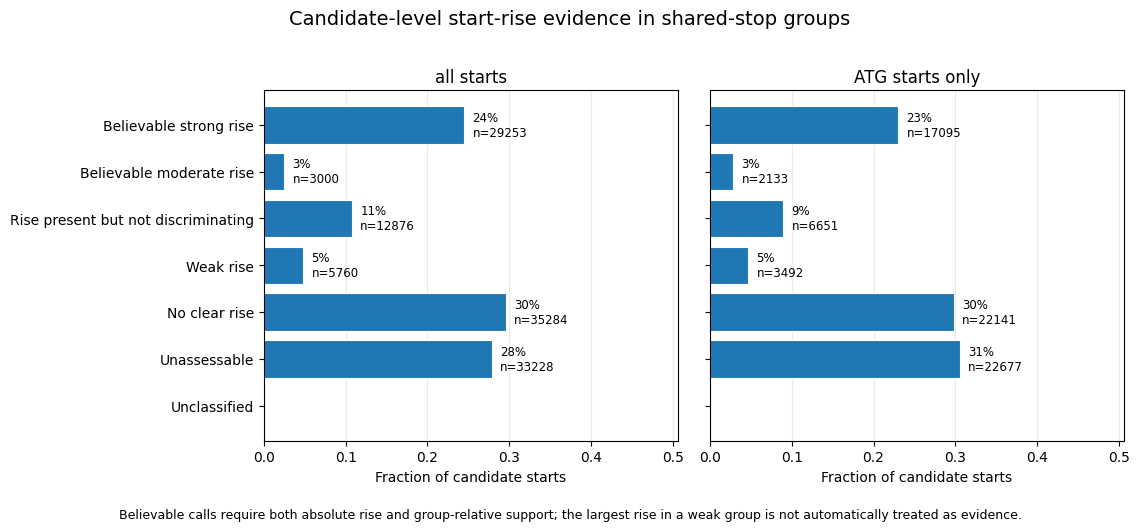

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/candidate_start_rise_interpretation_all_vs_atg.png


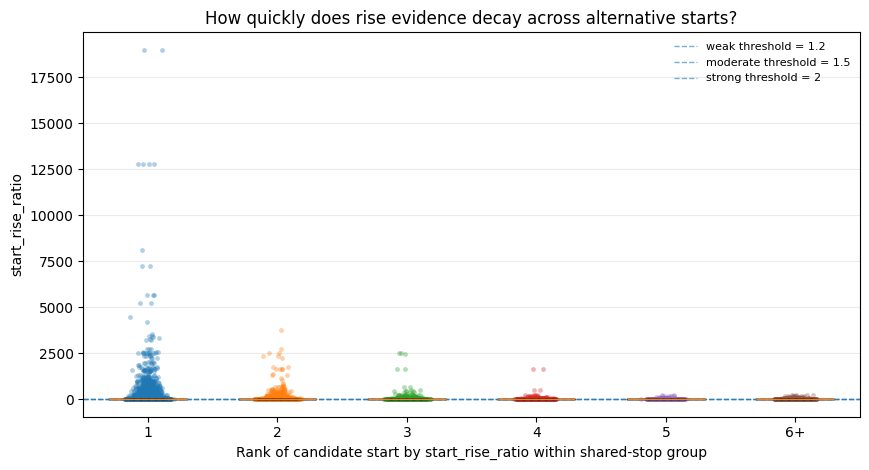

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/candidate_start_rise_ratio_by_within_stop_rank.png


In [123]:
# Candidate-level start-rise characterisation for shared-stop / alternative-start groups.
#
# This replaces the binary question:
#   "Does rise support consensus start vs alternative start?"
#
# with a candidate-level question:
#   "For every candidate start sharing the same stop, is there a believable rise-up?"
#
# Outputs:
#   start_rise_candidate_df
#       one row per candidate start in an ambiguous shared-stop group
#
#   start_rise_stop_summary_df
#       one row per shared-stop group
#
#   start_rise_tier_summary_df
#       summary of candidate-level rise interpretation
#
# Plots:
#   1. candidate-level rise interpretation, all starts vs ATG starts only
#   2. start_rise_ratio by within-stop rank

ALT_START_SAMPLE = "Ribo_Pancreas_pooled"
START_CODON_CLASSES_COL = "start_codon_classes"

# Absolute rise-ratio thresholds.
# These are working thresholds for triage, not biological truth.
WEAK_RISE_RATIO = 1.20
MODERATE_RISE_RATIO = 1.50
STRONG_RISE_RATIO = 2.00

# Relative-to-group thresholds.
# These stop a weak/noisy maximum being treated as convincing evidence.
DOMINANT_VS_MEDIAN = 1.50
CLOSE_TO_TOP_FRACTION = 0.80

# Avoid calling tiny/noisy features believable just because a ratio is high.
# Keep permissive unless body_total_signal is on a known calibrated scale.
MIN_BODY_TOTAL_SIGNAL_FOR_BELIEVABLE = 1

REQUIRED_COLS = [
    "sample_id",
    "coverage_pass",
    "stop_key",
    "start_key",
    "feature_key",
    "start_rise_ratio",
    "n_tools_full",
    "n_tools_stop",
    "periodicity",
    "body_total_signal",
    "bed_chrom",
    "bed_start",
    "bed_end",
    "bed_strand",
    "context_class",
    "source_tools",
]

missing = [c for c in REQUIRED_COLS if c not in evidence_df.columns]
if missing:
    raise KeyError(
        "Missing required columns in evidence_df: "
        f"{missing}\nAvailable columns:\n{list(evidence_df.columns)}"
    )

if START_CODON_CLASSES_COL not in evidence_df.columns:
    raise KeyError(
        f"Expected column {START_CODON_CLASSES_COL!r} in evidence_df. "
        "Available codon-ish columns are: "
        f"{[c for c in evidence_df.columns if 'codon' in c.lower()]}"
    )


def _safe_ratio(numer, denom):
    numer = pd.to_numeric(numer, errors="coerce")
    denom = pd.to_numeric(denom, errors="coerce")
    out = numer / denom.replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan)


def build_candidate_start_rise_df(input_df, label, atg_only=False):
    """
    Build one row per candidate start in shared-stop groups with >=2 distinct starts.

    The output asks whether each candidate start has believable start-rise evidence,
    rather than only asking which start wins.
    """

    df = input_df.copy()

    df = df[
        (df["sample_id"].eq(ALT_START_SAMPLE))
        & (df["coverage_pass"].astype(bool))
        & (df["stop_key"].notna())
        & (df["start_key"].notna())
    ].copy()

    df[START_CODON_CLASSES_COL] = (
        df[START_CODON_CLASSES_COL]
        .astype(str)
        .str.strip()
    )

    if atg_only:
        # Strict ATG-only filter.
        # This deliberately excludes mixed labels such as ATG|near_cognate.
        df = df[df[START_CODON_CLASSES_COL].eq("ATG")].copy()

    numeric_cols = [
        "start_rise_ratio",
        "n_tools_full",
        "n_tools_stop",
        "periodicity",
        "body_total_signal",
        "bed_start",
        "bed_end",
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Keep rows with missing/non-finite start_rise_ratio.
    # These are useful because they tell us the candidate start is unassessable.
    df["start_rise_ratio_clean"] = df["start_rise_ratio"].where(
        np.isfinite(df["start_rise_ratio"])
        & df["start_rise_ratio"].gt(0)
    )

    # Define ambiguous start groups after any ATG filtering.
    multi_start_stop_keys = (
        df
        .groupby("stop_key")["start_key"]
        .nunique()
        .loc[lambda s: s >= 2]
        .index
    )

    df = df[df["stop_key"].isin(multi_start_stop_keys)].copy()

    if df.empty:
        return pd.DataFrame()

    # Strand-aware start/stop coordinates.
    df["start_coord"] = np.where(
        df["bed_strand"].eq("+"),
        df["bed_start"],
        df["bed_end"],
    )

    df["stop_coord"] = np.where(
        df["bed_strand"].eq("+"),
        df["bed_end"],
        df["bed_start"],
    )

    df["start_to_stop_nt"] = (
        df["stop_coord"] - df["start_coord"]
    ).abs()

    # Consensus start proxy:
    # highest full-tool support, then periodicity/body signal/start rise.
    consensus_ranked = df.sort_values(
        [
            "stop_key",
            "n_tools_full",
            "periodicity",
            "body_total_signal",
            "start_rise_ratio_clean",
        ],
        ascending=[True, False, False, False, False],
    )

    consensus = (
        consensus_ranked
        .groupby("stop_key", as_index=False)
        .head(1)
        [[
            "stop_key",
            "feature_key",
            "start_key",
            "start_coord",
            "start_to_stop_nt",
            "n_tools_full",
            "periodicity",
            "body_total_signal",
            "start_rise_ratio_clean",
            START_CODON_CLASSES_COL,
        ]]
        .rename(columns={
            "feature_key": "consensus_feature_key",
            "start_key": "consensus_start_key",
            "start_coord": "consensus_start_coord",
            "start_to_stop_nt": "consensus_start_to_stop_nt",
            "n_tools_full": "consensus_n_tools_full",
            "periodicity": "consensus_periodicity",
            "body_total_signal": "consensus_body_total_signal",
            "start_rise_ratio_clean": "consensus_start_rise_ratio",
            START_CODON_CLASSES_COL: "consensus_start_codon_classes",
        })
    )

    df = df.merge(consensus, on="stop_key", how="left")

    df["is_consensus_start"] = df["start_key"].eq(df["consensus_start_key"])

    df["position_vs_consensus"] = np.select(
        [
            df["is_consensus_start"],
            df["start_to_stop_nt"].gt(df["consensus_start_to_stop_nt"]),
            df["start_to_stop_nt"].lt(df["consensus_start_to_stop_nt"]),
        ],
        [
            "consensus_start",
            "upstream_longer",
            "downstream_shorter",
        ],
        default="different_same_distance",
    )

    # Group-level statistics for the shared stop.
    group_stats = (
        df
        .groupby("stop_key", as_index=False)
        .agg(
            n_candidate_starts=("start_key", "nunique"),
            n_candidate_features=("feature_key", "nunique"),
            n_assessable_starts=("start_rise_ratio_clean", lambda s: s.notna().sum()),
            group_max_start_rise=("start_rise_ratio_clean", "max"),
            group_median_start_rise=("start_rise_ratio_clean", "median"),
            group_min_start_rise=("start_rise_ratio_clean", "min"),
            group_max_body_signal=("body_total_signal", "max"),
            group_median_body_signal=("body_total_signal", "median"),
            group_max_periodicity=("periodicity", "max"),
            group_median_periodicity=("periodicity", "median"),
            group_max_n_tools_full=("n_tools_full", "max"),
        )
    )

    df = df.merge(group_stats, on="stop_key", how="left")

    df["rise_vs_group_max"] = _safe_ratio(
        df["start_rise_ratio_clean"],
        df["group_max_start_rise"],
    )

    df["rise_vs_group_median"] = _safe_ratio(
        df["start_rise_ratio_clean"],
        df["group_median_start_rise"],
    )

    df["body_signal_vs_group_median"] = _safe_ratio(
        df["body_total_signal"],
        df["group_median_body_signal"],
    )

    df["periodicity_vs_group_median"] = _safe_ratio(
        df["periodicity"],
        df["group_median_periodicity"],
    )

    # Rank candidate starts by start-rise within each stop group.
    # Missing/non-assessable values go to the bottom.
    df = df.sort_values(
        [
            "stop_key",
            "start_rise_ratio_clean",
            "periodicity",
            "body_total_signal",
            "n_tools_full",
        ],
        ascending=[True, False, False, False, False],
    ).copy()

    df["rise_rank_within_stop"] = (
        df
        .groupby("stop_key")
        .cumcount()
        .add(1)
    )

    df["rise_percentile_within_stop"] = (
        1
        - (
            df["rise_rank_within_stop"] - 1
        )
        / (
            df["n_candidate_starts"] - 1
        ).replace(0, np.nan)
    )

    # Rank by tool support separately.
    df = df.sort_values(
        [
            "stop_key",
            "n_tools_full",
            "periodicity",
            "body_total_signal",
            "start_rise_ratio_clean",
        ],
        ascending=[True, False, False, False, False],
    ).copy()

    df["tool_support_rank_within_stop"] = (
        df
        .groupby("stop_key")
        .cumcount()
        .add(1)
    )

    # Characterise each candidate start.
    assessable = df["start_rise_ratio_clean"].notna()

    enough_body_signal = (
        df["body_total_signal"]
        .fillna(0)
        .ge(MIN_BODY_TOTAL_SIGNAL_FOR_BELIEVABLE)
    )

    strong_abs = df["start_rise_ratio_clean"].ge(STRONG_RISE_RATIO)
    moderate_abs = df["start_rise_ratio_clean"].ge(MODERATE_RISE_RATIO)
    weak_abs = df["start_rise_ratio_clean"].ge(WEAK_RISE_RATIO)

    dominant = (
        df["rise_vs_group_median"].ge(DOMINANT_VS_MEDIAN)
        | df["rise_vs_group_max"].ge(CLOSE_TO_TOP_FRACTION)
    )

    close_to_top = df["rise_vs_group_max"].ge(CLOSE_TO_TOP_FRACTION)

    df["start_rise_tier"] = np.select(
        [
            ~assessable,
            assessable & ~weak_abs,
            assessable & weak_abs & ~moderate_abs,
            assessable & moderate_abs & ~strong_abs & close_to_top & enough_body_signal,
            assessable & moderate_abs & ~strong_abs,
            assessable & strong_abs & dominant & enough_body_signal,
            assessable & strong_abs,
        ],
        [
            "unassessable",
            "no_clear_rise",
            "weak_rise",
            "moderate_believable_rise_close_to_top",
            "moderate_rise_not_group_dominant",
            "strong_believable_rise",
            "strong_rise_but_not_group_dominant",
        ],
        default="unclassified",
    )

    df["start_rise_interpretation"] = np.select(
        [
            df["start_rise_tier"].eq("strong_believable_rise"),
            df["start_rise_tier"].eq("moderate_believable_rise_close_to_top"),
            df["start_rise_tier"].isin([
                "strong_rise_but_not_group_dominant",
                "moderate_rise_not_group_dominant",
            ]),
            df["start_rise_tier"].eq("weak_rise"),
            df["start_rise_tier"].eq("no_clear_rise"),
            df["start_rise_tier"].eq("unassessable"),
        ],
        [
            "Believable strong rise",
            "Believable moderate rise",
            "Rise present but not discriminating",
            "Weak rise",
            "No clear rise",
            "Unassessable",
        ],
        default="Unclassified",
    )

    df["candidate_story"] = np.select(
        [
            df["is_consensus_start"]
            & df["start_rise_interpretation"].astype(str).str.startswith("Believable"),

            ~df["is_consensus_start"]
            & df["start_rise_interpretation"].astype(str).str.startswith("Believable"),

            df["is_consensus_start"]
            & df["start_rise_interpretation"].isin([
                "Weak rise",
                "No clear rise",
                "Unassessable",
            ]),

            ~df["is_consensus_start"]
            & df["start_rise_interpretation"].isin([
                "Weak rise",
                "No clear rise",
                "Unassessable",
            ]),
        ],
        [
            "consensus_start_has_believable_rise",
            "alternative_start_has_believable_rise",
            "consensus_start_lacks_believable_rise",
            "alternative_start_lacks_believable_rise",
        ],
        default="ambiguous_or_non_discriminating",
    )

    df["start_set"] = label

    preferred_cols = [
        "start_set",
        "stop_key",
        "feature_key",
        "start_key",
        "bed_chrom",
        "bed_strand",
        "start_coord",
        "stop_coord",
        "start_to_stop_nt",
        "position_vs_consensus",
        "is_consensus_start",
        "consensus_feature_key",
        "consensus_start_key",
        "consensus_start_to_stop_nt",
        "n_candidate_starts",
        "n_candidate_features",
        "n_assessable_starts",
        "n_tools_full",
        "n_tools_stop",
        "tool_support_rank_within_stop",
        "start_rise_ratio",
        "start_rise_ratio_clean",
        "rise_rank_within_stop",
        "rise_percentile_within_stop",
        "group_max_start_rise",
        "group_median_start_rise",
        "rise_vs_group_max",
        "rise_vs_group_median",
        "periodicity",
        "periodicity_vs_group_median",
        "body_total_signal",
        "body_signal_vs_group_median",
        "start_rise_tier",
        "start_rise_interpretation",
        "candidate_story",
        "context_class",
        START_CODON_CLASSES_COL,
        "source_tools",
    ]

    existing_preferred_cols = [c for c in preferred_cols if c in df.columns]
    remaining_cols = [c for c in df.columns if c not in existing_preferred_cols]

    return df[existing_preferred_cols + remaining_cols].copy()


all_start_rise_candidate_df = build_candidate_start_rise_df(
    evidence_df,
    label="all starts",
    atg_only=False,
)

atg_start_rise_candidate_df = build_candidate_start_rise_df(
    evidence_df,
    label="ATG starts only",
    atg_only=True,
)

start_rise_candidate_df = pd.concat(
    [
        all_start_rise_candidate_df,
        atg_start_rise_candidate_df,
    ],
    ignore_index=True,
)

interpretation_order = [
    "Believable strong rise",
    "Believable moderate rise",
    "Rise present but not discriminating",
    "Weak rise",
    "No clear rise",
    "Unassessable",
    "Unclassified",
]

tier_order = [
    "strong_believable_rise",
    "moderate_believable_rise_close_to_top",
    "strong_rise_but_not_group_dominant",
    "moderate_rise_not_group_dominant",
    "weak_rise",
    "no_clear_rise",
    "unassessable",
    "unclassified",
]

start_set_order = [
    "all starts",
    "ATG starts only",
]

if start_rise_candidate_df.empty:
    start_rise_stop_summary_df = pd.DataFrame()
    start_rise_tier_summary_df = pd.DataFrame()
    print("No shared-stop groups with multiple candidate starts after filtering.")
else:
    start_rise_candidate_df["start_set"] = pd.Categorical(
        start_rise_candidate_df["start_set"],
        categories=start_set_order,
        ordered=True,
    )

    start_rise_candidate_df["start_rise_interpretation"] = pd.Categorical(
        start_rise_candidate_df["start_rise_interpretation"],
        categories=interpretation_order,
        ordered=True,
    )

    start_rise_candidate_df["start_rise_tier"] = pd.Categorical(
        start_rise_candidate_df["start_rise_tier"],
        categories=tier_order,
        ordered=True,
    )

    start_rise_candidate_df = (
        start_rise_candidate_df
        .sort_values([
            "start_set",
            "stop_key",
            "rise_rank_within_stop",
            "tool_support_rank_within_stop",
        ])
        .reset_index(drop=True)
    )

    believable_mask = (
        start_rise_candidate_df["start_rise_interpretation"]
        .astype(str)
        .isin([
            "Believable strong rise",
            "Believable moderate rise",
        ])
    )

    tmp = start_rise_candidate_df.copy()

    tmp["has_believable_rise"] = believable_mask.astype(bool)
    tmp["is_consensus_start"] = tmp["is_consensus_start"].fillna(False).astype(bool)

    tmp["believable_consensus_start"] = (
        tmp["has_believable_rise"]
        & tmp["is_consensus_start"]
    )

    tmp["believable_alternative_start"] = (
        tmp["has_believable_rise"]
        & ~tmp["is_consensus_start"]
    )

    start_rise_stop_summary_df = (
        tmp
        # observed=True avoids materialising unobserved categorical combinations,
        # which can create NaN rows and turn boolean summaries into floats.
        .groupby(["start_set", "stop_key"], observed=True, as_index=False)
        .agg(
            n_candidate_starts=("start_key", "nunique"),
            n_assessable_starts=("start_rise_ratio_clean", lambda s: s.notna().sum()),
            max_start_rise=("start_rise_ratio_clean", "max"),
            median_start_rise=("start_rise_ratio_clean", "median"),
            has_any_believable_rise=("has_believable_rise", "max"),
            has_believable_consensus_start=("believable_consensus_start", "max"),
            has_believable_alternative_start=("believable_alternative_start", "max"),
            n_believable_candidate_starts=("has_believable_rise", "sum"),
            n_believable_consensus_starts=("believable_consensus_start", "sum"),
            n_believable_alternative_starts=("believable_alternative_start", "sum"),
        )
    )

    # Force logical columns to real bool before &, ~, and np.select.
    bool_cols = [
        "has_any_believable_rise",
        "has_believable_consensus_start",
        "has_believable_alternative_start",
    ]

    for col in bool_cols:
        start_rise_stop_summary_df[col] = (
            start_rise_stop_summary_df[col]
            .fillna(False)
            .astype(bool)
        )

    consensus_believable = start_rise_stop_summary_df["has_believable_consensus_start"]
    alternative_believable = start_rise_stop_summary_df["has_believable_alternative_start"]
    any_believable = start_rise_stop_summary_df["has_any_believable_rise"]

    start_rise_stop_summary_df["group_rise_story"] = np.select(
        [
            consensus_believable & alternative_believable,
            consensus_believable & ~alternative_believable,
            ~consensus_believable & alternative_believable,
            ~any_believable,
        ],
        [
            "both_consensus_and_alternative_have_believable_rise",
            "only_consensus_has_believable_rise",
            "only_alternative_has_believable_rise",
            "no_candidate_has_believable_rise",
        ],
        default="unclassified",
    )

    start_rise_tier_summary_df = (
        start_rise_candidate_df
        .groupby(
            [
                "start_set",
                "start_rise_interpretation",
                "is_consensus_start",
                "position_vs_consensus",
            ],
            observed=True,
            as_index=False,
        )
        .size()
        .rename(columns={"size": "n_candidate_starts"})
    )

    start_rise_tier_summary_df["fraction_within_start_set"] = (
        start_rise_tier_summary_df["n_candidate_starts"]
        / start_rise_tier_summary_df
            .groupby("start_set", observed=True)["n_candidate_starts"]
            .transform("sum")
            .replace(0, np.nan)
    ).fillna(0)

    start_rise_tier_summary_df = (
        start_rise_tier_summary_df
        .sort_values([
            "start_set",
            "start_rise_interpretation",
            "is_consensus_start",
            "position_vs_consensus",
        ])
        .reset_index(drop=True)
    )

    print("start_rise_candidate_df", start_rise_candidate_df.shape)
    display(start_rise_candidate_df.head(30))

    print("start_rise_stop_summary_df", start_rise_stop_summary_df.shape)
    display(start_rise_stop_summary_df.head(30))

    print("start_rise_tier_summary_df", start_rise_tier_summary_df.shape)
    display(start_rise_tier_summary_df)

    save_table(
        start_rise_candidate_df,
        (
            "candidate_start_rise_characterisation_"
            f"{ALT_START_SAMPLE}_"
            f"weak_{str(WEAK_RISE_RATIO).replace('.', 'p')}_"
            f"moderate_{str(MODERATE_RISE_RATIO).replace('.', 'p')}_"
            f"strong_{str(STRONG_RISE_RATIO).replace('.', 'p')}"
        )
    )

    save_table(
        start_rise_stop_summary_df,
        (
            "shared_stop_start_rise_group_summary_"
            f"{ALT_START_SAMPLE}_"
            f"weak_{str(WEAK_RISE_RATIO).replace('.', 'p')}_"
            f"moderate_{str(MODERATE_RISE_RATIO).replace('.', 'p')}_"
            f"strong_{str(STRONG_RISE_RATIO).replace('.', 'p')}"
        )
    )

    save_table(
        start_rise_tier_summary_df,
        (
            "candidate_start_rise_tier_summary_"
            f"{ALT_START_SAMPLE}_"
            f"weak_{str(WEAK_RISE_RATIO).replace('.', 'p')}_"
            f"moderate_{str(MODERATE_RISE_RATIO).replace('.', 'p')}_"
            f"strong_{str(STRONG_RISE_RATIO).replace('.', 'p')}"
        )
    )


# Plot 1: candidate-level interpretation composition.
if start_rise_candidate_df.empty:
    print("Skipping plots: no candidate start-rise rows.")
else:
    plot_counts = (
        start_rise_candidate_df
        .groupby(["start_set", "start_rise_interpretation"], observed=True, as_index=False)
        .size()
        .rename(columns={"size": "n_candidate_starts"})
    )

    complete_index = pd.MultiIndex.from_product(
        [
            start_set_order,
            interpretation_order,
        ],
        names=["start_set", "start_rise_interpretation"],
    )

    plot_counts = (
        plot_counts
        .set_index(["start_set", "start_rise_interpretation"])
        .reindex(complete_index, fill_value=0)
        .reset_index()
    )

    plot_counts["fraction"] = (
        plot_counts["n_candidate_starts"]
        / plot_counts
            .groupby("start_set")["n_candidate_starts"]
            .transform("sum")
            .replace(0, np.nan)
    ).fillna(0)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.5, 4.8),
        sharey=True,
        sharex=True,
    )

    for ax, start_set in zip(axes, start_set_order):
        panel = plot_counts[plot_counts["start_set"].eq(start_set)].copy()

        ax.barh(
            panel["start_rise_interpretation"],
            panel["fraction"],
            edgecolor="white",
            linewidth=0.8,
        )

        for i, row in panel.reset_index(drop=True).iterrows():
            if row["n_candidate_starts"] == 0:
                continue

            ax.text(
                row["fraction"] + 0.01,
                i,
                f"{row['fraction']:.0%}\nn={int(row['n_candidate_starts'])}",
                va="center",
                ha="left",
                fontsize=8.5,
            )

        ax.set_title(start_set)
        ax.set_xlabel("Fraction of candidate starts")
        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)

    axes[0].invert_yaxis()
    axes[0].set_ylabel("")

    max_fraction = plot_counts["fraction"].max()
    for ax in axes:
        ax.set_xlim(0, min(1.0, max_fraction + 0.20))

    fig.suptitle(
        "Candidate-level start-rise evidence in shared-stop groups",
        y=1.02,
        fontsize=14,
    )

    fig.text(
        0.5,
        -0.04,
        (
            "Believable calls require both absolute rise and group-relative support; "
            "the largest rise in a weak group is not automatically treated as evidence."
        ),
        ha="center",
        fontsize=9,
    )

    fig.tight_layout()

    out = FIG_DIR / "candidate_start_rise_interpretation_all_vs_atg.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()

    print(out)


# Plot 2: start_rise_ratio by rank within shared-stop group.
if not start_rise_candidate_df.empty:
    rank_plot_df = start_rise_candidate_df[
        start_rise_candidate_df["start_rise_ratio_clean"].notna()
    ].copy()

    rank_plot_df["rise_rank_plot"] = np.where(
        rank_plot_df["rise_rank_within_stop"].le(5),
        rank_plot_df["rise_rank_within_stop"].astype(int).astype(str),
        "6+",
    )

    rank_order = ["1", "2", "3", "4", "5", "6+"]

    rank_plot_df["rise_rank_plot"] = pd.Categorical(
        rank_plot_df["rise_rank_plot"],
        categories=rank_order,
        ordered=True,
    )

    if rank_plot_df.empty:
        print("No assessable start_rise_ratio values; skipping rank plot.")
    else:
        fig, ax = plt.subplots(figsize=(8.8, 4.8))

        data = [
            rank_plot_df.loc[
                rank_plot_df["rise_rank_plot"].eq(rank),
                "start_rise_ratio_clean",
            ].dropna()
            for rank in rank_order
        ]

        nonempty_positions = [
            i + 1
            for i, values in enumerate(data)
            if len(values) > 0
        ]

        nonempty_data = [
            values
            for values in data
            if len(values) > 0
        ]

        if nonempty_data:
            ax.boxplot(
                nonempty_data,
                positions=nonempty_positions,
                widths=0.6,
                showfliers=False,
            )

            rng = np.random.default_rng(1)

            for pos, values in zip(nonempty_positions, nonempty_data):
                jitter = rng.normal(0, 0.045, size=len(values))
                ax.scatter(
                    np.full(len(values), pos) + jitter,
                    values,
                    s=12,
                    alpha=0.35,
                    linewidths=0,
                )

            ax.axhline(
                WEAK_RISE_RATIO,
                linestyle="--",
                linewidth=1,
                alpha=0.6,
                label=f"weak threshold = {WEAK_RISE_RATIO:g}",
            )

            ax.axhline(
                MODERATE_RISE_RATIO,
                linestyle="--",
                linewidth=1,
                alpha=0.6,
                label=f"moderate threshold = {MODERATE_RISE_RATIO:g}",
            )

            ax.axhline(
                STRONG_RISE_RATIO,
                linestyle="--",
                linewidth=1,
                alpha=0.6,
                label=f"strong threshold = {STRONG_RISE_RATIO:g}",
            )

            ax.set_xticks(range(1, len(rank_order) + 1))
            ax.set_xticklabels(rank_order)
            ax.set_xlabel("Rank of candidate start by start_rise_ratio within shared-stop group")
            ax.set_ylabel("start_rise_ratio")
            ax.set_title("How quickly does rise evidence decay across alternative starts?")
            ax.grid(axis="y", alpha=0.25)
            ax.set_axisbelow(True)
            ax.legend(frameon=False, fontsize=8)

            fig.tight_layout()

            out = FIG_DIR / "candidate_start_rise_ratio_by_within_stop_rank.png"
            fig.savefig(out, dpi=200, bbox_inches="tight")
            plt.show()

            print(out)
        else:
            print("No non-empty rank groups; skipping rank plot.")

rise_rank_within_stop,stop_key,best_start_rise_ratio,second_best_start_rise_ratio,best_vs_second_ratio,rise_separation_class
0,chr10:+:100373779,1.622222,0.975309,1.663291,clear separation
1,chr10:+:100381452,10.250000,1.500000,6.833333,strong separation
2,chr10:+:100382521,10.250000,1.142857,8.968749,strong separation
3,chr10:+:100388040,10.250000,10.250000,1.000000,top two similar
4,chr10:+:100388068,10.250000,1.500000,6.833333,strong separation
5,chr10:+:100395181,10.250000,1.500000,6.833333,strong separation
6,chr10:+:100482816,0.500000,0.333333,1.500000,modest separation
7,chr10:+:100913136,2.356322,0.330435,7.130974,strong separation
8,chr10:+:100961912,0.700000,0.409524,1.709302,clear separation
9,chr10:+:100972579,2.333333,1.342593,1.737931,clear separation


,rise_separation_class,n_stop_groups,fraction
0,top two similar,5442,0.211102
1,modest separation,2044,0.079289
2,clear separation,2977,0.115482
3,strong separation,15316,0.594127


Saved tables_talk_foundation/shared_stop_best_vs_second_start_rise_ratio.tsv
Saved tables_talk_foundation/shared_stop_best_vs_second_start_rise_ratio_summary.tsv


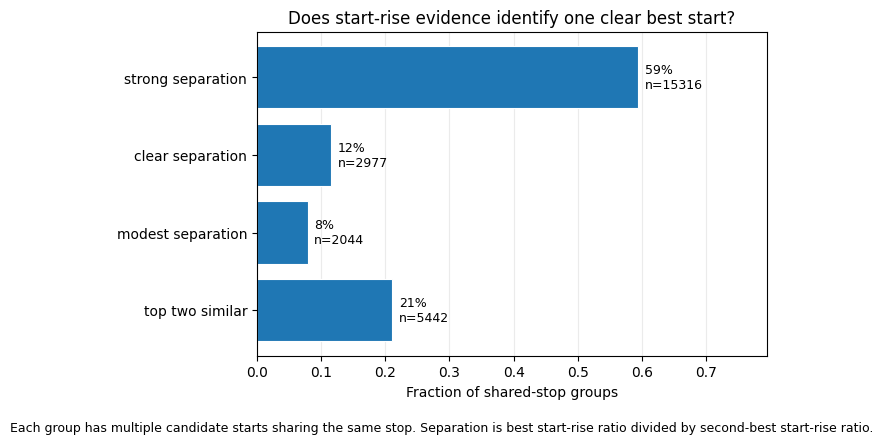

/hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_talk_foundation/shared_stop_best_vs_second_start_rise_separation.png


In [124]:
# Simpler plot:
# For each shared-stop group, compare the best start-rise candidate to the second-best.
#
# This asks:
#   "Is there one clear rise-supported start, or are the top two candidates similar?"
#
# Much easier to explain than plotting all ranks.

if start_rise_candidate_df.empty:
    print("No candidate start-rise rows available.")
else:
    simple_rank_df = (
        start_rise_candidate_df[
            (start_rise_candidate_df["start_set"].astype(str).eq("all starts"))
            & (start_rise_candidate_df["start_rise_ratio_clean"].notna())
        ]
        .copy()
        .sort_values(["stop_key", "rise_rank_within_stop"])
    )

    top2 = simple_rank_df[
        simple_rank_df["rise_rank_within_stop"].isin([1, 2])
    ].copy()

    top2_wide = (
        top2
        .pivot_table(
            index="stop_key",
            columns="rise_rank_within_stop",
            values="start_rise_ratio_clean",
            aggfunc="first",
        )
        .rename(columns={
            1: "best_start_rise_ratio",
            2: "second_best_start_rise_ratio",
        })
        .reset_index()
    )

    top2_wide = top2_wide[
        top2_wide["best_start_rise_ratio"].notna()
        & top2_wide["second_best_start_rise_ratio"].notna()
        & top2_wide["second_best_start_rise_ratio"].gt(0)
    ].copy()

    top2_wide["best_vs_second_ratio"] = (
        top2_wide["best_start_rise_ratio"]
        / top2_wide["second_best_start_rise_ratio"]
    )

    top2_wide["rise_separation_class"] = pd.cut(
        top2_wide["best_vs_second_ratio"],
        bins=[0, 1.25, 1.5, 2, np.inf],
        labels=[
            "top two similar",
            "modest separation",
            "clear separation",
            "strong separation",
        ],
        include_lowest=True,
    )

    display(top2_wide.head(20))

    separation_summary = (
        top2_wide
        .groupby("rise_separation_class", observed=True, as_index=False)
        .size()
        .rename(columns={"size": "n_stop_groups"})
    )

    separation_summary["fraction"] = (
        separation_summary["n_stop_groups"]
        / separation_summary["n_stop_groups"].sum()
    )

    display(separation_summary)

    save_table(
        top2_wide,
        "shared_stop_best_vs_second_start_rise_ratio"
    )

    save_table(
        separation_summary,
        "shared_stop_best_vs_second_start_rise_ratio_summary"
    )

    fig, ax = plt.subplots(figsize=(6.8, 4.2))

    ax.barh(
        separation_summary["rise_separation_class"].astype(str),
        separation_summary["fraction"],
        edgecolor="white",
        linewidth=0.8,
    )

    for i, row in separation_summary.reset_index(drop=True).iterrows():
        ax.text(
            row["fraction"] + 0.01,
            i,
            f"{row['fraction']:.0%}\nn={int(row['n_stop_groups'])}",
            va="center",
            ha="left",
            fontsize=9,
        )

    ax.set_xlabel("Fraction of shared-stop groups")
    ax.set_ylabel("")
    ax.set_title("Does start-rise evidence identify one clear best start?")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

    max_fraction = separation_summary["fraction"].max()
    ax.set_xlim(0, min(1.0, max_fraction + 0.20))

    fig.text(
        0.5,
        -0.04,
        (
            "Each group has multiple candidate starts sharing the same stop. "
            "Separation is best start-rise ratio divided by second-best start-rise ratio."
        ),
        ha="center",
        fontsize=9,
    )

    fig.tight_layout()

    out = FIG_DIR / "shared_stop_best_vs_second_start_rise_separation.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()

    print(out)